In [1]:
import os
import sys

import numpy as np
import math
import uproot as uproot
import pickle
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.colors
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import ticker
from matplotlib.ticker import (AutoMinorLocator, MultipleLocator)
from matplotlib import gridspec

# Add the head direcoty to sys.path
workspace_root = "/exp/sbnd/app/users/amoor/cafpyana/cafpyana/analysis_village/sample_validations/202503"  
sys.path.insert(0, workspace_root + "/../../../")

# import this repo's classes
import pyanalib.pandas_helpers as ph
from makedf.util import *
import pyanalib.pandas_helpers as ph
import pyanalib.split_df_helpers as splh
import pyanalib.stat_helpers as sh

In [2]:
#get sample file paths
#need four for the analysis standard: data (BNB + fixed light dev, intime cosmic), mc (BNB + light, low + threshold BNB + light) 

#input_path = "/exp/sbnd/data/users/amoor/cafpyana_samples/2025Cb/"
input_path = "/exp/sbnd/data/users/apapadop/dfs/v10_14_00/"
#mc_file = input_path + "mc_2025B_Oct25_afm.df"        #mc BNB + light?
#data_file = input_path + "data_2025B_Oct25_afm.df"    #data BNB + fixed light

#mc_bnb_cosmic_file = input_path + "list_mc_MCP2025C_FallValidationII_prodgenie_corsika_proton_rockbox0p1_sbnd_CV_caf_flat_caf_sbnd_sungbin_afm_Dec25b.df"
##mc_rockbox_dirt_file = input_path + "mc_MCP2025B_prodgenie_corsika_proton_rockbox_lowenergydirt_sbnd_CV_caf_flat_caf_sbnd_sungbin_afm_Nov25.df"
#data_offbeam_light_file = input_path + "list_data_MCP2025C_FallValidationII_RollingDev_offbeamlight_v10_14_00_flatcaf_sbnd_afm_Dec25b.df"
#data_bnb_light_dev_file = input_path + "list_data_MCP2025C_FallValidationII_RollingDev_bnblight_v10_14_00_flatcaf_sbnd_afm_Dec25b.df"

mc_bnb_cosmic_file = "/exp/sbnd/data/users/sungbino/dfs/v10_14_00/mc_MCP2025C_FallValidationII_prodgenie_corsika_proton_rockbox0p1_sbnd_CV_caf_flat_caf_sbnd_general_dfs.df"
data_offbeam_light_file = input_path + "data_MCP2025C_FallValidationII_RollingDev_offbeamlight_v10_14_00_flatcaf_sbnd.df"
data_bnb_light_dev_file = input_path + "data_MCP2025C_FallValidationII_RollingDev_bnblight_v10_14_00_flatcaf_sbnd.df"

In [3]:
sample_str = "v10_14_00"

In [4]:
## Check keys in each file
print("keys in mc_bnb_cosmic_file")
splh.print_keys(mc_bnb_cosmic_file)

print("keys in data_offbeam_light_file")
splh.print_keys(data_offbeam_light_file)

print("keys in data_bnb_light_dev_file")
splh.print_keys(data_bnb_light_dev_file)

keys in mc_bnb_cosmic_file
Keys: ['/evt_0', '/evt_1', '/evt_10', '/evt_11', '/evt_12', '/evt_13', '/evt_14', '/evt_15', '/evt_16', '/evt_17', '/evt_18', '/evt_19', '/evt_2', '/evt_20', '/evt_21', '/evt_3', '/evt_4', '/evt_5', '/evt_6', '/evt_7', '/evt_8', '/evt_9', '/hdr_0', '/hdr_1', '/hdr_10', '/hdr_11', '/hdr_12', '/hdr_13', '/hdr_14', '/hdr_15', '/hdr_16', '/hdr_17', '/hdr_18', '/hdr_19', '/hdr_2', '/hdr_20', '/hdr_21', '/hdr_3', '/hdr_4', '/hdr_5', '/hdr_6', '/hdr_7', '/hdr_8', '/hdr_9', '/histpotdf_0', '/histpotdf_1', '/histpotdf_10', '/histpotdf_11', '/histpotdf_12', '/histpotdf_13', '/histpotdf_14', '/histpotdf_15', '/histpotdf_16', '/histpotdf_17', '/histpotdf_18', '/histpotdf_19', '/histpotdf_2', '/histpotdf_20', '/histpotdf_21', '/histpotdf_3', '/histpotdf_4', '/histpotdf_5', '/histpotdf_6', '/histpotdf_7', '/histpotdf_8', '/histpotdf_9', '/mcnu_0', '/mcnu_1', '/mcnu_10', '/mcnu_11', '/mcnu_12', '/mcnu_13', '/mcnu_14', '/mcnu_15', '/mcnu_16', '/mcnu_17', '/mcnu_18', '/mcnu_1

In [5]:
## Check split multiplicity
print("mc_bnb_cosmic_file n_split: %d" %splh.get_n_split(mc_bnb_cosmic_file))
#print("mc_rockbox_dirt_file n_split: %d" %splh.get_n_split(mc_rockbox_dirt_file))
print("data_offbeam_light_file n_split: %d" %splh.get_n_split(data_offbeam_light_file))
print("data_bnb_light_dev_file n_split: %d" %splh.get_n_split(data_bnb_light_dev_file))

mc_bnb_cosmic_file n_split: 22
data_offbeam_light_file n_split: 2
data_bnb_light_dev_file n_split: 4


In [6]:
## Define keys to load
n_max_concat = 4 ## for big files, each key would have more than one split
keys2load = ['opflash', 'hdr', 'pot', 'evt', 'mcnu']

## Load DataFrames
mc_bnb_cosmic_dfs = splh.load_dfs(mc_bnb_cosmic_file, keys2load, n_max_concat)
#mc_rockbox_dirt_dfs = splh.load_dfs(mc_rockbox_dirt_file, keys2load, n_max_concat)
data_offbeam_light_dfs = splh.load_dfs(data_offbeam_light_file, keys2load, n_max_concat)
data_bnb_light_dfs = splh.load_dfs(data_bnb_light_dev_file, keys2load, n_max_concat)

In [7]:
data_offbeam_light_dfs["evt"].columns.values

array([('slc', 'barycenterFM', 'chargeTotal', '', '', ''),
       ('slc', 'barycenterFM', 'flashTime', '', '', ''),
       ('slc', 'barycenterFM', 'flashPEs', '', '', ''),
       ('slc', 'barycenterFM', 'chi2', '', '', ''),
       ('slc', 'barycenterFM', 'score', '', '', ''),
       ('slc', 'barycenterFM', 'deltaZ', '', '', ''),
       ('slc', 'is_clear_cosmic', '', '', '', ''),
       ('slc', 'vertex', 'x', '', '', ''),
       ('slc', 'vertex', 'y', '', '', ''),
       ('slc', 'vertex', 'z', '', '', ''),
       ('slc', 'self', '', '', '', ''),
       ('slc', 'tmatch', 'eff', '', '', ''),
       ('slc', 'tmatch', 'pur', '', '', ''),
       ('slc', 'tmatch', 'idx', '', '', ''),
       ('slc', 'producer', '', '', '', ''),
       ('slc', 'nuid', 'crlongtrkdiry', '', '', ''),
       ('slc', 'nu_score', '', '', '', ''),
       ('slc', 'opt0', 'score', '', '', ''),
       ('slc', 'opt0', 'time', '', '', ''),
       ('slc', 'opt0', 'measPE', '', '', ''),
       ('slc', 'opt0', 'hypoPE', '', '

## Check for duplication

In [8]:
def find_duplicate_run_evt_combinations(df):
    """
    Given a DataFrame with a MultiIndex of (__ntuple, entry), find all rows
    where (run, evt) combinations are duplicated.

    Parameters:
        df (pd.DataFrame): Input DataFrame with MultiIndex and columns 'run' and 'evt'.

    Returns:
        pd.DataFrame: Filtered DataFrame containing only duplicated (run, evt) combinations,
                      including the original (__ntuple, entry) indices.
    """
    # Reset index to access MultiIndex as columns
    df_reset = df.reset_index()

    # Find duplicated (run, evt) combinations
    dup_mask = df_reset.duplicated(subset=['run', 'subrun', 'evt'], keep=False)

    # Extract duplicates
    duplicates = df_reset[dup_mask]

    # Sort for readability
    duplicates_sorted = duplicates.sort_values(by=['run', 'subrun', 'evt'])

    #return duplicates_sorted[['__ntuple', 'entry', 'run', 'subrun', 'evt']]

    print(duplicates_sorted[['__ntuple', 'entry', 'run', 'subrun', 'evt']])
    #return duplicates_sorted[['__ntuple', 'entry', 'run', 'subrun', 'evt']]

def plot_duplicate_run_subrun_evt_distribution(df, title=""):
    """
    Computes and plots the distribution of how many times each (run, subrun, evt) combination appears.

    Parameters:
        df (pd.DataFrame): Input DataFrame with MultiIndex (__ntuple, entry)
                           and columns including 'run', 'subrun', and 'evt'.
        title (str): Title for the plot (optional).
    
    Returns:
        pd.Series: Duplication count distribution 
                   (index = count, value = number of (run, subrun, evt) with that count)
    """
    # Reset index to work with columns
    df_reset = df.reset_index()

    # Count occurrences of each (run, subrun, evt)
    combo_counts = df_reset.groupby(['run', 'subrun', 'evt']).size()

    # Get distribution of these counts
    distribution = combo_counts.value_counts().sort_index()

    # Plotting
    plt.figure(figsize=(8, 5))
    distribution.plot(kind='bar', log=True)
    plt.xlabel('Number of times (run, subrun, evt) appears')
    plt.ylabel('Entries (spills)')
    plt.title(title)
    plt.grid(True, axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

def filter_unique_events(df):
    # If your index includes '__ntuple' and 'entry', reset to access them as columns
    df_reset = df.reset_index()

    # Find duplicated (run, subrun, evt) — keep=False marks *all* occurrences as duplicates
    dup_mask = df_reset.duplicated(subset=['run', 'subrun', 'evt'], keep=False)

    # Keep only rows that are NOT duplicated
    unique_df = df_reset[~dup_mask]

    # Optional: set index back if needed
    return unique_df.set_index(df.index.names)

def filter_using_hdr(df, hdrdf):
    allowed_keys = set(hdrdf.index)

    ntuples = df.index.get_level_values('__ntuple').to_numpy()
    entries = df.index.get_level_values('entry').to_numpy()
    keys = np.column_stack((ntuples, entries))

    # Create mask using list comprehension (faster than pure zip for large data)
    mask = [(nt, en) in allowed_keys for nt, en in keys]

    return df[mask]

In [9]:
print("duplication for MC BNB + Cosmic sample")
find_duplicate_run_evt_combinations(mc_bnb_cosmic_dfs["hdr"])

print("\n")
print("duplication for Off-beam + light sample")
find_duplicate_run_evt_combinations(data_offbeam_light_dfs["hdr"])

print("\n")
print("duplication for BNB + light sample")
find_duplicate_run_evt_combinations(data_bnb_light_dfs["hdr"])

duplication for MC BNB + Cosmic sample
       __ntuple  entry  run  subrun  evt
52387       123    336   57      60   40
59796       135    156   57      60   40
52389       123    338   57      60   43
59797       135    157   57      60   43
52390       123    339   57      60   46
59799       135    159   57      60   46
10275        70    370  310      68    1
60885       154    377  310      68    1
10279        70    374  310      68    8
60888       154    380  310      68    8
10281        70    376  310      68   17
60889       154    381  310      68   17
10282        70    377  310      68   18
60890       154    382  310      68   18
10283        70    378  310      68   22
60894       154    386  310      68   22
10286        70    381  310      68   31
60898       154    390  310      68   31
10291        70    386  310      68   49
60900       154    392  310      68   49


duplication for Off-beam + light sample
Empty DataFrame
Columns: [__ntuple, entry, run, subrun, ev

In [10]:
### Filter the hdr DataFrame first, then filter other DataFrames by matching with the hdr DataFrame
mc_bnb_cosmic_dfs["hdr"] = filter_unique_events(mc_bnb_cosmic_dfs["hdr"])
data_offbeam_light_dfs["hdr"] = filter_unique_events(data_offbeam_light_dfs["hdr"])
data_bnb_light_dfs["hdr"] = filter_unique_events(data_bnb_light_dfs["hdr"])

In [11]:
## Double check if it is filtered
find_duplicate_run_evt_combinations(mc_bnb_cosmic_dfs["hdr"])
find_duplicate_run_evt_combinations(data_offbeam_light_dfs["hdr"])
find_duplicate_run_evt_combinations(data_bnb_light_dfs["hdr"])

Empty DataFrame
Columns: [__ntuple, entry, run, subrun, evt]
Index: []
Empty DataFrame
Columns: [__ntuple, entry, run, subrun, evt]
Index: []
Empty DataFrame
Columns: [__ntuple, entry, run, subrun, evt]
Index: []


In [12]:
mc_bnb_cosmic_dfs["evt"] = filter_using_hdr(mc_bnb_cosmic_dfs["evt"], mc_bnb_cosmic_dfs["hdr"])
mc_bnb_cosmic_dfs["opflash"] = filter_using_hdr(mc_bnb_cosmic_dfs["opflash"], mc_bnb_cosmic_dfs["hdr"])
mc_bnb_cosmic_dfs["pot"] = filter_using_hdr(mc_bnb_cosmic_dfs["pot"], mc_bnb_cosmic_dfs["hdr"])
mc_bnb_cosmic_dfs["mcnu"] = filter_using_hdr(mc_bnb_cosmic_dfs["mcnu"], mc_bnb_cosmic_dfs["hdr"])

data_offbeam_light_dfs["evt"] = filter_using_hdr(data_offbeam_light_dfs["evt"], data_offbeam_light_dfs["hdr"])
data_offbeam_light_dfs["opflash"] = filter_using_hdr(data_offbeam_light_dfs["opflash"], data_offbeam_light_dfs["hdr"])
data_offbeam_light_dfs["pot"] = filter_using_hdr(data_offbeam_light_dfs["pot"], data_offbeam_light_dfs["hdr"])

data_bnb_light_dfs["evt"] = filter_using_hdr(data_bnb_light_dfs["evt"], data_bnb_light_dfs["hdr"])
data_bnb_light_dfs["opflash"] = filter_using_hdr(data_bnb_light_dfs["opflash"], data_bnb_light_dfs["hdr"])
data_bnb_light_dfs["pot"] = filter_using_hdr(data_bnb_light_dfs["pot"], data_bnb_light_dfs["hdr"])

## Normalisation

In [13]:
def get_n_evt(df):
    unique_count = df.index.droplevel(
        list(df.index.names[2:])  # drop everything except first two levels
    ).nunique()
    return unique_count

In [14]:
##remove these

## Collect the offbeam data fudge factor and scale for offbeam data
n_record_spill_data = get_n_evt(data_bnb_light_dfs['hdr'])
print("n_record_spill_data", n_record_spill_data)
n_gates_data =  len(data_bnb_light_dfs["pot"])
print("n_gates_data", n_gates_data)

n_record_spill_offbeam_data = get_n_evt(data_offbeam_light_dfs['hdr'])
print("n_record_spill_offbeam_data", n_record_spill_offbeam_data)
n_gates_offbeam_data = data_offbeam_light_dfs["hdr"][data_offbeam_light_dfs["hdr"]['first_in_subrun'] == 1]['noffbeambnb'].sum()
print("n_gates_offbeam_data", n_gates_offbeam_data)

p_trig_data = n_record_spill_data / n_gates_data
p_trig_offbeam_data = n_record_spill_offbeam_data / n_gates_offbeam_data

f_factor = (p_trig_data - p_trig_offbeam_data) / (1 - p_trig_offbeam_data)
print("f_factor: %f" %f_factor)

intime_gate_scale = (1. - f_factor) * (n_gates_data + 0.) / (n_gates_offbeam_data + 0.)
print("intime_gate_scale: %f" %intime_gate_scale)
intime_gate_scale = 0
print("intime_gate_scale: %f" %intime_gate_scale)

n_record_spill_data 63855
n_gates_data 709166
n_record_spill_offbeam_data 33080
n_gates_offbeam_data 0.0
f_factor: nan
intime_gate_scale: nan
intime_gate_scale: 0.000000


/tmp/ipykernel_1484/1901335783.py:15: RuntimeWarning: divide by zero encountered in scalar divide
  p_trig_offbeam_data = n_record_spill_offbeam_data / n_gates_offbeam_data
/tmp/ipykernel_1484/1901335783.py:17: RuntimeWarning: invalid value encountered in scalar divide
  f_factor = (p_trig_data - p_trig_offbeam_data) / (1 - p_trig_offbeam_data)


In [15]:
## Collect pot scale for MC
mc_tot_pot = mc_bnb_cosmic_dfs["hdr"]['pot'].sum()
#n_evt_mc = get_n_evt(mc_bnb_cosmic_dfs["hdr"])

data_tot_pot = data_bnb_light_dfs["hdr"]['pot'].sum()
#data_tot_TOR860 = data_bnb_light_dfs["pot"]['TOR860'].sum()
#data_tot_TOR875 = data_bnb_light_dfs["pot"]['TOR875'].sum()

print("mc_tot_pot: %e" %(mc_tot_pot))
#print("n_evt_mc: %e" %(n_evt_mc))

print("data_tot_pot: %e" %(data_tot_pot))
#n_evt_data = get_n_evt(data_bnb_light_dfs["hdr"])
#print(n_evt_data)
#print("data_tot_TOR860: %e" %(data_tot_TOR860))
#print("data_tot_TOR875: %e" %(data_tot_TOR875))

target_pot = data_tot_pot
mc_pot_scale = target_pot / mc_tot_pot
#print(mc_pot_scale)
#print(mc_low_th_scale)
print("MC POT scale: %.3f" %(mc_pot_scale))

mc_tot_pot: 4.575711e+18
data_tot_pot: 3.279966e+18
MC POT scale: 0.717


In [16]:
## Comparison between observed and expected total number of recorded spills
n_evt_mc = get_n_evt(mc_bnb_cosmic_dfs["hdr"])

#intime_gate_scale = 1 #fudge for 0 POT

print("n_evt_data_onbeam: %d" %n_record_spill_data)
print("n_evt_exp.: %f" %(n_evt_mc * mc_pot_scale + n_record_spill_offbeam_data** intime_gate_scale))
print("- n_evt_mc: %f" %(n_evt_mc * mc_pot_scale))
print("- n_evt_data_offbeam: %f" %(n_record_spill_offbeam_data * intime_gate_scale))

n_evt_data_onbeam: 63855
n_evt_exp.: 60296.409694
- n_evt_mc: 60295.409694
- n_evt_data_offbeam: 0.000000


## OpFlash and light timing cut

In [34]:
def draw_a_distribution(df, col, title_x, x_min, x_max, nbins, title_y = "", is_logx = False, is_logy = False, label_top = ""):
    var = df[col]
    bins = np.logspace(np.log10(x_min), np.log10(x_max), nbins + 1) if is_logx else np.linspace(x_min, x_max, nbins + 1)
    bin_centers = np.sqrt(bins[:-1] * bins[1:]) if is_logx else 0.5 * (bins[:-1] + bins[1:])
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(var, bins, weights=[np.ones_like(data) * 1. for data in var], histtype="step", label=["all"])
    if is_logy:
        ax.yscale('log')
    ax.set_xlabel(title_x)
    ax.set_ylabel(title_y)
    ax.legend()
    ax.text(1.0, 1.02, label_top, transform=ax.transAxes, fontsize=14, fontweight='bold', ha='right') 
    plt.show()

def abs_comp_total_pe_two_mc_stack(
    df_mc, df_data_bnb_light, df_data_offbeam_light,
    col_mc, col_data, title_x, x_min, x_max, nbins,
    title_y = "", is_logx = False, is_logy = False, label_top = "",
    mc_scale = 1.533, intime_scale = 1.
):
    mc_var = df_mc[col_mc]
    data_bnb_light_var = df_data_bnb_light[col_data]
    data_offbeam_light_var = df_data_offbeam_light[col_data]

    # (kept for reference; override via intime_scale argument)
    #data_offbeam_light_scale = 0.103

    # Binning
    bins = (np.logspace(np.log10(x_min), np.log10(x_max), nbins + 1)
            if is_logx else np.linspace(x_min, x_max, nbins + 1))
    bin_centers = (np.sqrt(bins[:-1] * bins[1:])
                   if is_logx else 0.5 * (bins[:-1] + bins[1:]))
    bin_widths = np.diff(bins)

    fig, ax = plt.subplots(figsize=(8, 5))

    # --- Data histogram (BNB light) ---
    ax.hist(
        data_bnb_light_var, bins=bins,
        histtype="step", color="black", linewidth=2,
        label="BNB + light data"
    )

    # --- Components: compute binned counts ---
    mc_hist, _ = np.histogram(mc_var, bins=bins)
    offbeam_hist, _ = np.histogram(data_offbeam_light_var, bins=bins)

    # Apply scales
    mc_hist = mc_hist * mc_scale
    offbeam_hist = offbeam_hist

    # --- Stack components as bars (to show contributions) ---
    # Bottoms for stacking
    bottom0 = np.zeros_like(mc_hist, dtype=float)
    h1 = mc_hist
    h3 = offbeam_hist * intime_scale

    # Use bars so stack works in both linear and log-x; they also respect log-y.
    # (We avoid specifying colors explicitly so you can theme globally if you like.)
    ax.bar(bins[:-1], h1, width=bin_widths, align="edge",
           alpha=0.45, edgecolor="none", label="MC (BNB+cosmic)")
    ax.bar(bins[:-1], h3, width=bin_widths, align="edge",
           bottom=h1, alpha=0.45, edgecolor="none", label="Off-beam light")

    # --- Total prediction overlay (dashed step) ---
    pred_hist = h1 + h3
    ax.step(bin_centers, pred_hist, where="mid", linewidth=2, linestyle="--",
            label="Total prediction", color='red')

    # Scales, labels, cosmetics
    if is_logx:
        ax.set_xscale("log")
    if is_logy:
        ax.set_yscale("log")

    ax.set_xlabel(title_x)
    ax.set_ylabel(title_y if title_y else "Events")
    ax.set_xlim(x_min, x_max)

    # Legend: put data first, then components, then total
    # (Matplotlib collects in order added; this already matches that.)
    ax.legend(frameon=False)

    if label_top:
        ax.text(1.0, 1.02, label_top, transform=ax.transAxes,
                fontsize=14, fontweight='bold', ha='right')

    plt.tight_layout()
    plt.show()
    

In [35]:
mc_bnb_cosmic_opflash_df = mc_bnb_cosmic_dfs['opflash']
data_bnb_light_opflash_df = data_bnb_light_dfs['opflash']
data_offbeam_light_opflash_df = data_offbeam_light_dfs['opflash']

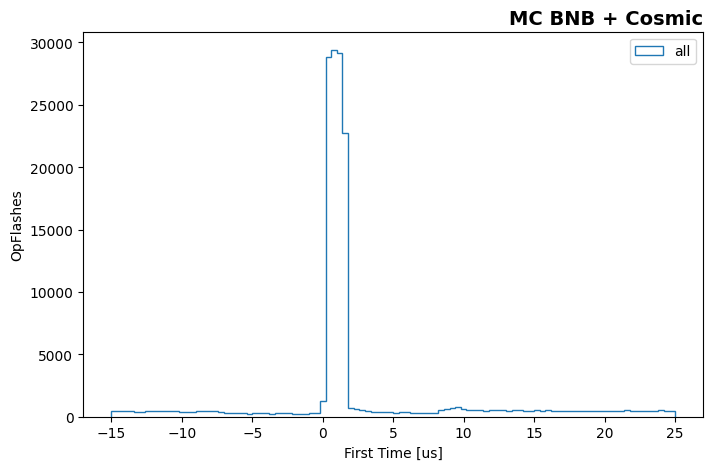

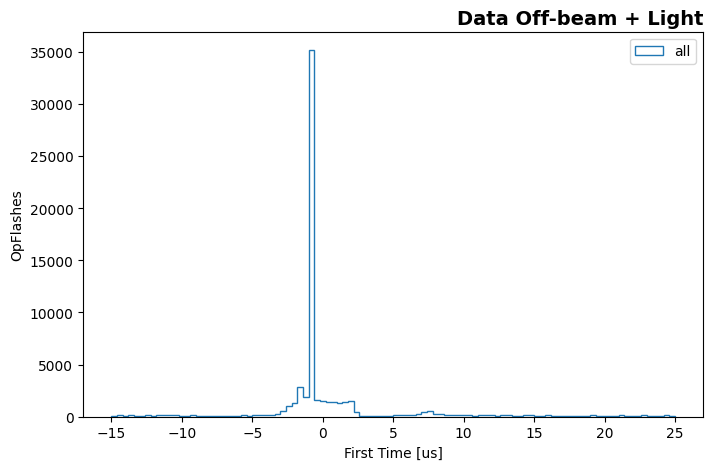

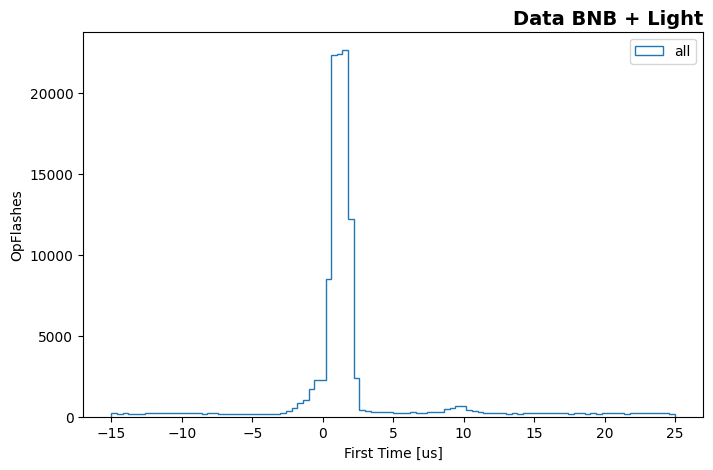

In [36]:
## Check OpFlash First Time distributions
draw_a_distribution(mc_bnb_cosmic_opflash_df, ('firsttime'), "First Time [us]", -15., 25., 100, "OpFlashes", False, False, "MC BNB + Cosmic")
draw_a_distribution(data_offbeam_light_opflash_df, ('firsttime'), "First Time [us]", -15., 25., 100, "OpFlashes", False, False, "Data Off-beam + Light")
draw_a_distribution(data_bnb_light_opflash_df, ('firsttime'), "First Time [us]", -15., 25., 100, "OpFlashes", False, False, "Data BNB + Light")

In [37]:
## Based on the previous block's result, we use [-5 us, +5 us] window for collecting OpFlashes corresponding to the trigger

mc_bnb_light_opflash_time_cut_df = mc_bnb_cosmic_opflash_df[(mc_bnb_cosmic_opflash_df.firsttime > -5.) & (mc_bnb_cosmic_opflash_df.firsttime < 5.)]
data_offbeam_light_opflash_df = data_offbeam_light_opflash_df[(data_offbeam_light_opflash_df.firsttime > -5.) & (data_offbeam_light_opflash_df.firsttime < 5.)]
data_bnb_light_opflash_df = data_bnb_light_opflash_df[(data_bnb_light_opflash_df.firsttime > -5.) & (data_bnb_light_opflash_df.firsttime < 5.)]

In [38]:
## Sum PEs for OpFlashes within the timing window

mc_bnb_cosmic_totalpe_sum_time_cut=(mc_bnb_light_opflash_time_cut_df.groupby(level=[0, 1])["totalpe"].sum())
data_offbeam_light_totalpe_sum_time_cut=(data_offbeam_light_opflash_df.groupby(level=[0, 1])["totalpe"].sum())
data_bnb_light_totalpe_sum_time_cut=(data_bnb_light_opflash_df.groupby(level=[0, 1])["totalpe"].sum())

In [39]:
## Add the total PE column to the hdr DataFrames, and fill empty (NaN) entries with 0.

mc_bnb_cosmic_dfs['hdr']['totalpe_timecut'] = mc_bnb_cosmic_totalpe_sum_time_cut
mc_bnb_cosmic_dfs['hdr']['totalpe_timecut'] = (mc_bnb_cosmic_dfs['hdr']['totalpe_timecut'].fillna(-1.))

data_offbeam_light_dfs['hdr']['totalpe_timecut'] = data_offbeam_light_totalpe_sum_time_cut
data_offbeam_light_dfs['hdr']['totalpe_timecut'] = (data_offbeam_light_dfs['hdr']['totalpe_timecut'].fillna(-1.))

data_bnb_light_dfs['hdr']['totalpe_timecut'] = data_bnb_light_totalpe_sum_time_cut
data_bnb_light_dfs['hdr']['totalpe_timecut'] = (data_bnb_light_dfs['hdr']['totalpe_timecut'].fillna(-1.))

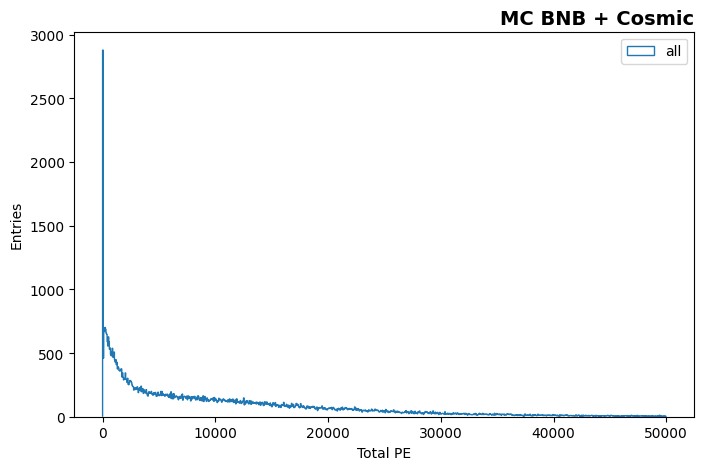

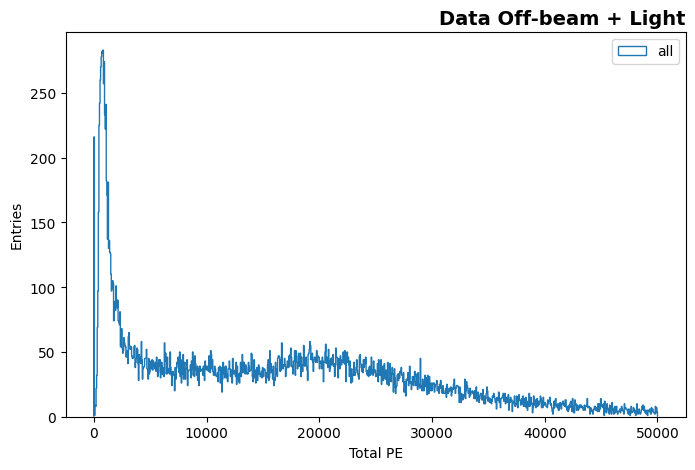

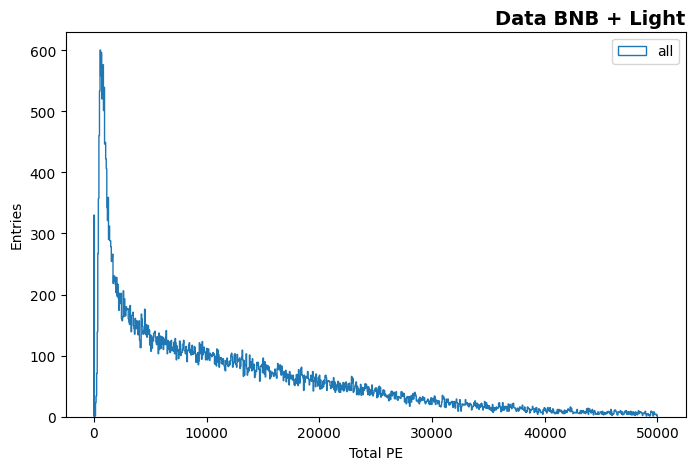

In [40]:
## Check the total PE distributions

draw_a_distribution(mc_bnb_cosmic_dfs['hdr'], ('totalpe_timecut'), "Total PE", -10, 50000, 1000, "Entries", False, False, "MC BNB + Cosmic")
draw_a_distribution(data_offbeam_light_dfs['hdr'], ('totalpe_timecut'), "Total PE", -10, 50000, 1000, "Entries", False, False, "Data Off-beam + Light")
draw_a_distribution(data_bnb_light_dfs['hdr'], ('totalpe_timecut'), "Total PE", -10, 50000, 1000, "Entries", False, False, "Data BNB + Light")

In [41]:
## Apply a scale to MC total PE
mc_bnb_cosmic_hdr_df = mc_bnb_cosmic_dfs['hdr']
#mc_bnb_cosmic_hdr_df['totalpe_timecut_0p66'] = mc_bnb_cosmic_hdr_df['totalpe_timecut'] * 0.66

data_offbeam_light_hdr_df = data_offbeam_light_dfs['hdr']
data_bnb_light_hdr_df = data_bnb_light_dfs['hdr']

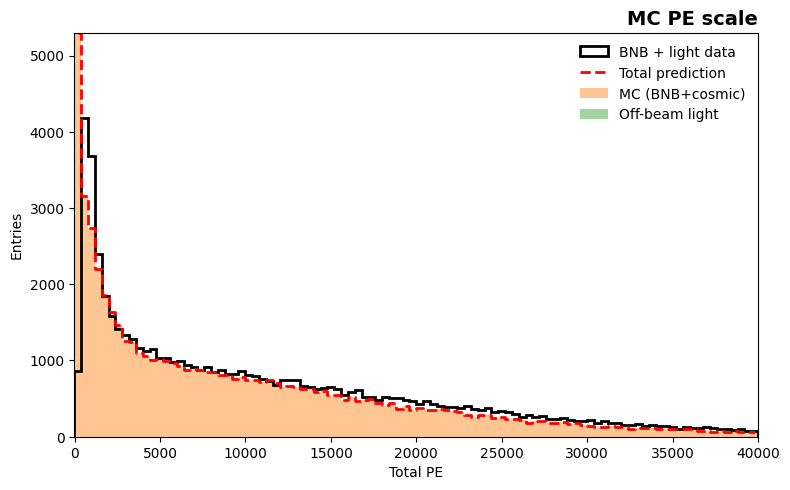

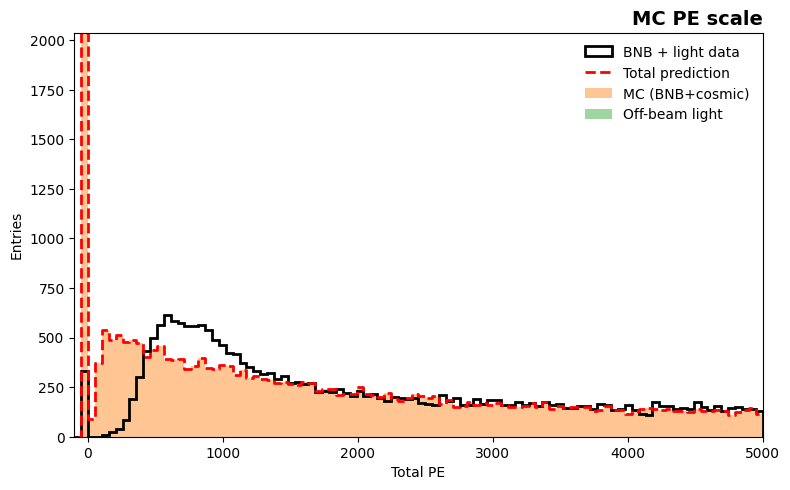

In [42]:
## Check total PE distribution
abs_comp_total_pe_two_mc_stack(mc_bnb_cosmic_hdr_df, data_bnb_light_hdr_df, data_offbeam_light_hdr_df, ('totalpe_timecut'), ('totalpe_timecut'), "Total PE", -10., 40000, 100, "Entries", False, False, "MC PE scale", mc_pot_scale, intime_gate_scale)
abs_comp_total_pe_two_mc_stack(mc_bnb_cosmic_hdr_df, data_bnb_light_hdr_df, data_offbeam_light_hdr_df, ('totalpe_timecut'), ('totalpe_timecut'), "Total PE", -100, 5000, 100, "Entries", False, False, "MC PE scale", mc_pot_scale, intime_gate_scale)

In [43]:
##leave it there, no PE cut for now

## DEFINE PE CUT
total_pe_cut = 2000.
mc_bnb_cosmic_pe_mask = mc_bnb_cosmic_hdr_df["totalpe_timecut"] > total_pe_cut
data_offbeam_pe_mask = data_offbeam_light_hdr_df['totalpe_timecut'] > total_pe_cut
data_bnb_light_pe_mask = data_bnb_light_hdr_df['totalpe_timecut'] > total_pe_cut

In [44]:
## Since evt DataFrame has more level in labels, we should make a mask for considering the difference
def get_evt_pe_mask(mask, df):
    sel_idx = mask[mask].index
    pairs = df.index.droplevel([-2, -1])
    mask2 = pairs.isin(sel_idx)
    return mask2

In [45]:
mc_bnb_cosmic_evt_pe_mask = get_evt_pe_mask(mc_bnb_cosmic_pe_mask, mc_bnb_cosmic_dfs["evt"])
data_offbeam_evt_pe_mask = get_evt_pe_mask(data_offbeam_pe_mask, data_offbeam_light_dfs["evt"])
data_bnb_light_evt_pe_mask = get_evt_pe_mask(data_bnb_light_pe_mask, data_bnb_light_dfs["evt"])

In [46]:
## Double checking for legnths of evt DataFrame and the mask array
print("mc_bnb_cosmic_dfs['evt'] length: %d" %len(mc_bnb_cosmic_dfs['evt']))
print("mc_bnb_cosmic_evt_pe_mask length: %d" %len(mc_bnb_cosmic_evt_pe_mask))

print("data_offbeam_light_dfs['evt'] length: %d" %len(data_offbeam_light_dfs['evt']))
print("data_offbeam_evt_pe_mask length: %d" %len(data_offbeam_evt_pe_mask))

print("data_bnb_light_dfs['evt'] length: %d" %len(data_bnb_light_dfs['evt']))
print("data_bnb_light_evt_pe_mask length: %d" %len(data_bnb_light_evt_pe_mask))

mc_bnb_cosmic_dfs['evt'] length: 3934878
mc_bnb_cosmic_evt_pe_mask length: 3934878
data_offbeam_light_dfs['evt'] length: 1836403
data_offbeam_evt_pe_mask length: 1836403
data_bnb_light_dfs['evt'] length: 3408174
data_bnb_light_evt_pe_mask length: 3408174


In [47]:
## Add PE cut decision (boolean) column to evt DataFrame
mc_bnb_cosmic_dfs["evt"][('pemask', '', '', '', '', '')] = mc_bnb_cosmic_evt_pe_mask
data_bnb_light_dfs["evt"][('pemask', '', '', '', '', '')] = data_bnb_light_evt_pe_mask
data_offbeam_light_dfs["evt"][('pemask', '', '', '', '', '')] = data_offbeam_evt_pe_mask

## Define FV

In [17]:
def InFV_trk(data): # cm
    xmin = -190.
    ymin = -190.
    zmin = 10.
    xmax = 190.
    ymax =  190.
    zmax =  450.
    return (data.x > xmin) & (data.x < xmax) & (data.y > ymin) & (data.y < ymax) & (data.z > zmin) & (data.z < zmax)

def InFV(data): # cm
    xmin = -190.
    ymin = -190.
    zmin = 10.
    xmax = 190.
    ymax =  190.
    zmax =  450.
    return (np.abs(data.x) > 10) & (np.abs(data.x) < 190) & (data.y > ymin) & (data.y < ymax) & (data.z > zmin) & (data.z < zmax)

def InAV(data): # cm
    xmin = -200.
    ymin = -200.
    zmin = 0.
    xmax = 200.
    ymax =  200.
    zmax =  500.
    return (np.abs(data.x) > 10) & (np.abs(data.x) < 190) & (data.y > ymin) & (data.y < ymax) & (data.z > zmin) & (data.z < zmax)


def InFV_xy(data): # cm
    xmin = 10.
    ymin = -190.
    xmax = 190.
    ymax =  190.
    return (np.abs(data.x) > xmin) & (np.abs(data.x) < xmax) & (data.y > ymin) & (data.y < ymax)

## Vetoing high y and high z region
def InFV_nohiyz(data):
    xmin = 10.
    xmax = 190.
    zmin = 10.
    zmax = 450.
    ymax_highz = 100.
    pass_xz = (np.abs(data.x) > xmin) & (np.abs(data.x) < xmax) & (data.z > zmin) & (data.z < zmax)
    pass_y = ((data.z < 250) & (np.abs(data.y) < 190.)) | ((data.z > 250) & (data.y > -190.) & (data.y < ymax_highz))
    return pass_xz & pass_y

def InFV_nohiyz_trk(data):
    xmax = 190.
    zmin = 10.
    zmax = 450.
    ymax_highz = 100.
    pass_xz = (np.abs(data.x) < xmax) & (data.z > zmin) & (data.z < zmax)
    pass_y = ((data.z < 250) & (np.abs(data.y) < 190.)) | ((data.z > 250) & (data.y > -190.) & (data.y < ymax_highz))
    return pass_xz & pass_y

## Match truth and MC and create categories

In [18]:
def get_true_t(df):
    t = (df.E - df.mu.genE - df.cpi.genE)**2 - (df.momentum.x - df.mu.genp.x - df.cpi.genp.x)**2 - (df.momentum.y - df.mu.genp.y - df.cpi.genp.y)**2 - (df.momentum.z - df.mu.genp.z - df.cpi.genp.z)**2
    return np.abs(t)

In [19]:
true_t = get_true_t(mc_bnb_cosmic_dfs['mcnu']).fillna(999999)
mc_bnb_cosmic_dfs['mcnu']['true_t'] = true_t

In [20]:
## For MC BNB + cosmic sample
is_fv = InFV(mc_bnb_cosmic_dfs['mcnu'].position)     #based on the true position
is_cc = mc_bnb_cosmic_dfs['mcnu'].iscc               #based on truth CC info
genie_mode = mc_bnb_cosmic_dfs['mcnu'].genie_mode    #based on true interaction category
w = mc_bnb_cosmic_dfs['mcnu'].w
true_pdg = mc_bnb_cosmic_dfs['mcnu'].pdg
muon_energy = mc_bnb_cosmic_dfs["mcnu"].mu.genE

try :
    nuint_categ = pd.Series(8, index=mc_bnb_cosmic_dfs['mcnu'].index)
except Exception as e:
    print(f"Error init nuint_categ")

nuint_categ[~is_fv] = -1  # Out of FV
nuint_categ[is_fv & is_cc & ((true_pdg == 14) & (muon_energy > 0.1))] = 1 # Signal
nuint_categ[is_fv & ~is_cc] = 0  # NC
nuint_categ[is_fv & is_cc & (~((true_pdg == 14) & (muon_energy > 0.1))) & (genie_mode == 3)] = 2  #  CCCOH
nuint_categ[is_fv & is_cc & (~((true_pdg == 14) & (muon_energy > 0.1))) & (genie_mode == 0)] = 3  # CCQE
nuint_categ[is_fv & is_cc & (~((true_pdg == 14) & (muon_energy > 0.1))) & (genie_mode == 10)] = 4  # 2p2h
nuint_categ[is_fv & is_cc & (~((true_pdg == 14) & (muon_energy > 0.1))) & (genie_mode != 0) & (genie_mode != 3) & (genie_mode != 10) & ((w < 1.4) | (genie_mode == 1))] = 5  # RES
nuint_categ[is_fv & is_cc & (~((true_pdg == 14) & (muon_energy > 0.1))) & (genie_mode != 0) & (genie_mode != 3) & (genie_mode != 10) & ((w > 2.0) | (genie_mode == 2))] = 6  # DIS

mc_bnb_cosmic_dfs['mcnu']['nuint_categ'] = nuint_categ

In [21]:
#### 1) Merging is based on matching between slc.tmatch.idx of evtdf and rec.mc.nu..index of mcnudf.
####    For each entry (readout window), there could be multiple truth neutrino interactions and reconstructed slices
####    We want to match each truth neutrino interaction to a corresponding slice

#It matches the levels of the two datasets to be merged, and then merges them (so all columns and rows join the dataset)


# match for mc bnb cosmic
mc_bnb_cosmic_dfs["mcnu"].columns = pd.MultiIndex.from_tuples([('gen',) + col if isinstance(col, tuple) else ('gen', col) for col in mc_bnb_cosmic_dfs["mcnu"].columns])
mc_bnb_cosmic_dfs["mcnu"].columns = pd.MultiIndex.from_tuples([
    col + ('',) * (6 - len(col)) for col in mc_bnb_cosmic_dfs["mcnu"].columns
])
mc_bnb_cosmic_dfs["evt"] = ph.multicol_merge(mc_bnb_cosmic_dfs["evt"].reset_index(), mc_bnb_cosmic_dfs["mcnu"].reset_index(),
                                            left_on=[('__ntuple', '', '', '', '', ''), ('entry', '', '', '', '', ''), ('slc','tmatch', 'idx', '', '', '')],
                                            right_on=[('__ntuple', '', '', '', '', ''), ('entry', '', '', '', '', ''), ('rec.mc.nu..index', '','', '', '', '')], 
                                            how="left") ## -- save all sllices
mc_bnb_cosmic_dfs["evt"] = mc_bnb_cosmic_dfs["evt"].set_index(["__ntuple", "entry", "rec.slc..index", "rec.slc.reco.pfp..index"], verify_integrity=True)
mc_bnb_cosmic_dfs["evt"].loc[mc_bnb_cosmic_dfs["evt"][('gen', 'nuint_categ', '', '', '', '')].isna(), [('gen', 'nuint_categ', '', '', '', '')]] = -2

data_offbeam_light_dfs["evt"][('gen', 'nuint_categ', '', '', '', '')] = -3

In [22]:
## Check 
mc_bnb_cosmic_dfs["mcnu"].gen.nuint_categ.value_counts()

nuint_categ
-1    119644
 1     21253
 0      8607
 3       133
 5       116
 4        45
 6        41
 2         5
Name: count, dtype: int64

values =  [      0.  505395. 3429483.       0.]
sum values =  3934878.0


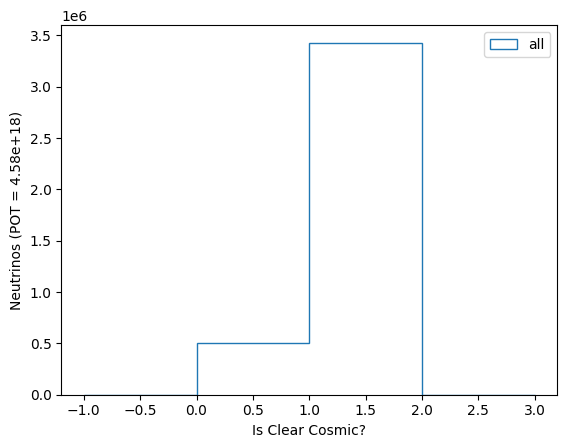

In [23]:
#Plot a variable

var = mc_bnb_cosmic_dfs["evt"].slc.is_clear_cosmic 
values, bins, patches = plt.hist(var, bins=np.linspace(-1., 3., 5), weights=[np.ones_like(data) * 1. for data in var], histtype="step", label=["all"])
print("values = ", values)
print("sum values = ", sum(values))
plt.xlabel("Is Clear Cosmic?")
plt.ylabel(f"Neutrinos (POT = {mc_tot_pot:.2e})")
plt.legend()
plt.show()

sum_value_nocut = sum(values)

In [24]:
mc_bnb_cosmic_dfs["evt"].columns.values

array([('slc', 'barycenterFM', 'chargeTotal', '', '', ''),
       ('slc', 'barycenterFM', 'flashTime', '', '', ''),
       ('slc', 'barycenterFM', 'flashPEs', '', '', ''),
       ('slc', 'barycenterFM', 'chi2', '', '', ''),
       ('slc', 'barycenterFM', 'score', '', '', ''),
       ('slc', 'barycenterFM', 'deltaZ', '', '', ''),
       ('slc', 'is_clear_cosmic', '', '', '', ''),
       ('slc', 'vertex', 'x', '', '', ''),
       ('slc', 'vertex', 'y', '', '', ''),
       ('slc', 'vertex', 'z', '', '', ''),
       ('slc', 'self', '', '', '', ''),
       ('slc', 'tmatch', 'eff', '', '', ''),
       ('slc', 'tmatch', 'pur', '', '', ''),
       ('slc', 'tmatch', 'idx', '', '', ''),
       ('slc', 'producer', '', '', '', ''),
       ('slc', 'nuid', 'crlongtrkdiry', '', '', ''),
       ('slc', 'nu_score', '', '', '', ''),
       ('slc', 'opt0', 'score', '', '', ''),
       ('slc', 'opt0', 'time', '', '', ''),
       ('slc', 'opt0', 'measPE', '', '', ''),
       ('slc', 'opt0', 'hypoPE', '', '

## Set up plotting

In [25]:

mode_list = [1, 2, 0, 3, 4, 5, 6, -1, -2, -3]
mode_labels = ["Signal", "CC COH (non. Sig)", "NC (non. Sig)", "QE (non. Sig)", "2p2h (non. Sig)", "RES (non. Sig)", "DIS (non. Sig)", "Non-FV (non. Sig)", "Others (non. Sig)", "Intime Cosmics (non. Sig)"]
colors = ['#d62728',  # Red            Signal
          '#1f77b4',  # Blue           NS CCCOH
          '#ff7f0e',  # Orange          NC
          '#2ca02c',  # Green           QE
          '#17becf',  # Teal           2p2h
          '#9467bd',  # Purple         RES
          '#8c564b',  # Brown           DIS
          '#e377c2',  # Pink            NON FV
          '#7f7f7f',  # Gray             Other
          '#bcbd22']  # Yellow-green      In time cosmics

def draw_reco_stacked_hist(var_mc, var_offbeam_data, is_logx, is_logy,
                           title_x, title_y, x_min, x_max, nbins, outname,
                           data_overlay=False, var_data=[], draw_density=False):
    
    ## Define the output figure to have two pads
    fig = plt.figure(figsize=(8, 8), dpi=100)
    gs = gridspec.GridSpec(2, 1, height_ratios=[5, 1], hspace=0.10)
    ax_main = fig.add_subplot(gs[0])
    ax_ratio = fig.add_subplot(gs[1], sharex=ax_main)
    
    if is_logx:
        ax_main.set_xscale('log')
        ax_ratio.set_xscale('log')        
    if is_logy:
        ax_main.set_yscale('log')


    ax_main.set_xlabel("")  # Only bottom has x-label
    ax_main.set_ylabel(title_y)
    ax_ratio.set_ylabel("Data/MC", fontsize=12)
    ax_ratio.set_xlabel(title_x, fontsize = 20)

    ax_ratio.axhline(1.0, color='red', linestyle='--', linewidth=1)
    ax_ratio.set_ylabel("Data/MC", fontsize=12)
    ax_ratio.set_xlabel(title_x, fontsize=12)
    ax_ratio.set_ylim(0.5, 1.5)
    ax_ratio.tick_params(width=2, length=6)
    for spine in ax_ratio.spines.values():
        spine.set_linewidth(2)

    plt.setp(ax_main.get_xticklabels(), visible=False)

    ## Defind binning
    if is_logx:
        bins = np.logspace(np.log10(x_min), np.log10(x_max), nbins + 1)
        bin_centers = np.sqrt(bins[:-1] * bins[1:])
    else:
        bins = np.linspace(x_min, x_max, nbins + 1)
        bin_centers = 0.5 * (bins[:-1] + bins[1:])

    ## Define data for MC
    all_mc_data = var_mc + var_offbeam_data
    #print("len all_mc_data ", len(all_mc_data[0]))
    all_weights = (
        [np.ones_like(data) * mc_pot_scale for data in var_mc] + 
        [np.ones_like(data) * intime_gate_scale for data in var_offbeam_data]
    )
    #print("all_weights ", all_weights)
    each_mc_hist_data = [np.histogram(data, bins=bins, weights=w)[0] for data, w in zip(all_mc_data, all_weights)]
    total_mc = np.sum(each_mc_hist_data, axis=0)
    print("total_mc ", total_mc)

    #each_mc_hist_data2 = [np.histogram(data, bins=bins)[0] for data in zip(var_mc)]
    #for item in each_mc_hist_data2:
     #   print(item)
    #print(len(var_mc))
    #total_mc2 = np.sum(each_mc_hist_data2, axis=0)
    #print("total_mc 2 ", total_mc2)

    ## Plot stacked MC
    hist_data, bins, _ = ax_main.hist(all_mc_data,
                                      bins=bins,
                                      weights=all_weights,
                                      stacked=True,
                                      color=colors,
                                      label=mode_labels,
                                      edgecolor='none',
                                      linewidth=0,
                                      density=draw_density,
                                      histtype='stepfilled')

    max_y = np.max(total_mc)

    ## Plot MC stat error box
    each_mc_hist_data = []
    each_mc_hist_err2 = []  # sum of squared weights for error

    for data, w in zip(all_mc_data, all_weights):
        hist_vals, _ = np.histogram(data, bins=bins, weights=w)
        hist_err2, _ = np.histogram(data, bins=bins, weights=np.square(w))
        each_mc_hist_data.append(hist_vals)
        each_mc_hist_err2.append(hist_err2)

    total_mc = np.sum(each_mc_hist_data, axis=0)
    total_mc_err2 = np.sum(each_mc_hist_err2, axis=0)
    mc_stat_err = np.sqrt(total_mc_err2)
    #mc_stat_err = np.sqrt(total_mc)

    ax_main.bar(
       bin_centers,
        2 * mc_stat_err,
        width=np.diff(bins),
        bottom=total_mc - mc_stat_err,
        facecolor='none',             # transparent fill
        edgecolor='black',            # outline color of the hatching
        hatch='xxxx',                 # hatch pattern similar to ROOT's 3004
        linewidth=0.0,
        label='MC Stat. Unc.'
    )

    ax_main.tick_params(width=2, length=10)
    for spine in ax_main.spines.values():
        spine.set_linewidth(2)

    ## Draw Ratio error bar
    mc_stat_err_ratio = mc_stat_err / total_mc
    mc_content_ratio = total_mc / total_mc
    mc_stat_err_ratio = np.nan_to_num(mc_stat_err_ratio, nan=0.)
    mc_content_ratio = np.nan_to_num(mc_content_ratio, nan=-999.)
    ax_ratio.bar(
        bin_centers,
        2*mc_stat_err_ratio,
        width=np.diff(bins),
        bottom=mc_content_ratio - mc_stat_err_ratio,
        facecolor='none',             # transparent fill
        edgecolor='black',            # outline color of the hatching
        hatch='xxxx',                 # hatch pattern similar to ROOT's 3004
        linewidth=0.0,
        label='MC Stat. Unc.'
    )

    ## Draw data too
    if data_overlay:
        ax_main.set_ylabel("Events (POT = %.2e)" % target_pot)
        if draw_density:
            ax_main.set_ylabel("A.U.")

        ## Define data histogram
        counts, _ = np.histogram(var_data, bins=bins)

        bin_widths = np.diff(bins)
        total_data = np.sum(counts)
        print("total data = ", total_data)
        norm_counts = counts
        data_eylow, data_eyhigh = sh.return_data_stat_err(counts)

        if draw_density:
            norm_counts = counts / (total_data * bin_widths)
            data_eylow = data_eylow / (total_data * bin_widths) if total_data > 0 else np.zeros_like(counts)
            data_eyhigh = data_eyhigh / (total_data * bin_widths) if total_data > 0 else np.zeros_like(counts)

        errors = data_eylow + data_eyhigh
        
        ## Plot data points on main histogram
        #ax_main.errorbar(bin_centers, norm_counts, yerr=errors,
        #                 fmt='o', color='black', label='Data',
        #                 markersize=5, capsize=3, linewidth=1.5)
        
        ax_main.errorbar(bin_centers, norm_counts,
                 yerr=np.vstack((data_eylow, data_eyhigh)),
                 fmt='o', color='black', label='Data',
                 markersize=5, capsize=3, linewidth=1.5)
        
        max_y_data = np.max(norm_counts + data_eyhigh)
        #print("max_y: %f" %(max_y))
        #print("max_y_data: %f" %(max_y_data))
        max_y = max(max_y, max_y_data)
        #print("max_y: %f" %(max_y))

        ## Make data/mc ratio plot
        data_ratio = norm_counts / total_mc
        print(norm_counts)
        print(total_mc)
        print("data ratio ", data_ratio)
        data_ratio_eylow = data_eylow / total_mc
        data_ratio_eyhigh = data_eyhigh / total_mc
        data_ratio = np.nan_to_num(data_ratio, nan=-999.)
        data_ratio_eylow = np.nan_to_num(data_ratio_eylow, nan=0.)
        data_ratio_eyhigh = np.nan_to_num(data_ratio_eyhigh, nan=0.)
        
        #data_ratio_errors = data_ratio_eylow + data_ratio_eyhigh
        #ax_ratio.errorbar(bin_centers, data_ratio, yerr=data_ratio_errors,
        #                 fmt='o', color='black', label='Data',
        #                 markersize=5, capsize=3, linewidth=1.5)

        ax_ratio.errorbar(bin_centers, data_ratio,
                  yerr=np.vstack((data_ratio_eylow, data_ratio_eyhigh)),
                  fmt='o', color='black', label='Data',
                  markersize=5, capsize=3, linewidth=1.5)

    ## Set ax_main axes variables
    ax_main.set_xlim(x_min, x_max)
    ax_main.set_ylim(0.0, max_y * 1.5)
    if is_logy:
        ax_main.set_ylim(0.1, max_y * 600)
    
    # Legend with fractions
    accum_sum = [np.sum(data) for data in hist_data]
    accum_sum = [0.] + accum_sum
    total_sum = accum_sum[-1]
    individual_sums = [accum_sum[i + 1] - accum_sum[i] for i in range(len(accum_sum) - 1)]
    print("mode sums = ", individual_sums)
    print("total sums = ", total_sum)
    fractions = [(count / total_sum) * 100 for count in individual_sums]
    legend_labels = [f"{label} ({frac:.1f}%)" for label, frac in zip(mode_labels[::-1], fractions[::-1])]
    if data_overlay:
        if draw_density:
            legend_labels.append("Data")
        else:
            legend_labels.append(f"Total MC Stat. Unc. ({total_sum:.0f})")
            legend_labels.append(f"Data ({total_data:.0f})")
            #legend_labels.append(f"Data ({total_data:.0f})")
    ax_main.legend(legend_labels, loc='upper left', fontsize=8, frameon=False, ncol=3, bbox_to_anchor=(0.05, 0.98))

    legend_labels_ratio = ["y=1", "MC (Stat. Only)", "Data/MC"]
    ax_ratio.legend(legend_labels_ratio, loc='upper left', fontsize=6, frameon=False, ncol=3, bbox_to_anchor=(0.05, 0.98))


    ax_main.text(0.00, 1.02, "SBND " + sample_str + ", Preliminary",
                 transform=ax_main.transAxes, fontsize=14, fontweight='bold')

    #fig.savefig("./plots/pandora_df/2025_v10_06_00_05/data_vs_mc_tpc/" + outname + ".pdf", format='pdf', bbox_inches='tight')
    plt.show()
    plt.close()

In [26]:
#this looks like it's seeing which selected reco events are also true signal events?

def draw_mc_data_shape_comp_per_slc(mc_bnb_cosmic_df, data_offbeam_df, data_df, column, x_title, y_title, x_min, x_max, n_bins, out_name, is_logx = False, is_logy = False):
    nuint_categ_col = ('gen', 'nuint_categ', '', '', '', '')

    mc_bnb_cosmic_df_per_slc = mc_bnb_cosmic_df.groupby([('__ntuple'), ('entry'), ('rec.slc..index')])[[column, nuint_categ_col]].first()
    data_offbeam_df_per_slc = data_offbeam_df.groupby([('__ntuple'), ('entry'), ('rec.slc..index')])[[column, nuint_categ_col]].first()

    data_df_per_slc = data_df.groupby([('__ntuple'), ('entry'), ('rec.slc..index')])[[column]].first()

    mode_list_mc = [m for m in mode_list if ((m != -3) and (m != -4))]
    var_mc_bnb_cosmic = [mc_bnb_cosmic_df_per_slc[mc_bnb_cosmic_df_per_slc[nuint_categ_col] == mode][column]for mode in mode_list_mc]
    var_data_offbeam = [data_offbeam_df_per_slc[data_offbeam_df_per_slc.gen.nuint_categ == -3][column]]
    var_data = data_df_per_slc[column]
    draw_reco_stacked_hist(var_mc_bnb_cosmic, var_data_offbeam, is_logx, is_logy, x_title, y_title, x_min, x_max, n_bins, out_name, True, var_data)


In [27]:
### For drawing data blind plots: this function does not draw data points in bins with singal contribution greater than 10%
def draw_reco_stacked_hist_blind(
    var_mc, var_offbeam_data, is_logx, is_logy,
    title_x, title_y, x_min, x_max, nbins, outname,
    data_overlay=False, var_data=[], draw_density=False,
    blind=True, blind_req=0.1
):
    fig = plt.figure(figsize=(8, 8), dpi=100)
    gs = gridspec.GridSpec(2, 1, height_ratios=[5, 1], hspace=0.10)
    ax_main = fig.add_subplot(gs[0])
    ax_ratio = fig.add_subplot(gs[1], sharex=ax_main)

    if is_logx:
        ax_main.set_xscale('log')
        ax_ratio.set_xscale('log')
    if is_logy:
        ax_main.set_yscale('log')

    ax_main.set_xlabel("")
    ax_main.set_ylabel(title_y)
    ax_ratio.set_ylabel("Data/MC", fontsize=12)
    ax_ratio.set_xlabel(title_x, fontsize=12)
    ax_ratio.axhline(1.0, color='red', linestyle='--', linewidth=1)
    ax_ratio.set_ylim(0.4, 1.6)
    ax_ratio.tick_params(width=2, length=6)
    for spine in ax_ratio.spines.values():
        spine.set_linewidth(2)

    plt.setp(ax_main.get_xticklabels(), visible=False)

    bins = np.logspace(np.log10(x_min), np.log10(x_max), nbins + 1) if is_logx else np.linspace(x_min, x_max, nbins + 1)
    bin_centers = np.sqrt(bins[:-1] * bins[1:]) if is_logx else 0.5 * (bins[:-1] + bins[1:])

    all_mc_data = var_mc + var_offbeam_data
    all_weights = (
        [np.ones_like(data) * mc_pot_scale for data in var_mc] +
        [np.ones_like(data) * intime_gate_scale for data in var_offbeam_data]
    )

    each_mc_hist_data = [
        np.histogram(data, bins=bins, weights=w)[0]
        for data, w in zip(all_mc_data, all_weights)
    ]
    total_mc = np.sum(each_mc_hist_data, axis=0)

    hist_data, bins, _ = ax_main.hist(
        all_mc_data, bins=bins, weights=all_weights,
        stacked=True, color=colors, label=mode_labels,
        edgecolor='none', linewidth=0, density=draw_density, histtype='stepfilled'
    )

    max_y = np.max(total_mc)
    each_mc_hist_data = []
    each_mc_hist_err2 = []  # sum of squared weights for error

    for data, w in zip(all_mc_data, all_weights):
        hist_vals, _ = np.histogram(data, bins=bins, weights=w)
        hist_err2, _ = np.histogram(data, bins=bins, weights=np.square(w))
        each_mc_hist_data.append(hist_vals)
        each_mc_hist_err2.append(hist_err2)

    total_mc = np.sum(each_mc_hist_data, axis=0)
    total_mc_err2 = np.sum(each_mc_hist_err2, axis=0)
    mc_stat_err = np.sqrt(total_mc_err2)
    #mc_stat_err = np.sqrt(total_mc)

    ax_main.bar(
        bin_centers, 2 * mc_stat_err,
        width=np.diff(bins), bottom=total_mc - mc_stat_err,
        facecolor='none', edgecolor='black', hatch='xxxx',
        linewidth=0.0, label='MC Stat. Unc.'
    )

    mc_stat_err_ratio = np.nan_to_num(mc_stat_err / total_mc, nan=0.)
    mc_content_ratio = np.nan_to_num(total_mc / total_mc, nan=-999.)
    ax_ratio.bar(
        bin_centers, 2 * mc_stat_err_ratio,
        width=np.diff(bins), bottom=mc_content_ratio - mc_stat_err_ratio,
        facecolor='none', edgecolor='black', hatch='xxxx',
        linewidth=0.0, label='MC Stat. Unc.'
    )

    if data_overlay:
        ax_main.set_ylabel("A.U." if draw_density else f"Events (POT = {target_pot:.2e})")

        counts, _ = np.histogram(var_data, bins=bins)
        bin_widths = np.diff(bins)
        total_data = np.sum(counts)

        norm_counts = counts
        data_eylow, data_eyhigh = sh.return_data_stat_err(counts)
        if draw_density and total_data > 0:
            norm_counts = counts / (total_data * bin_widths)
            data_eylow = data_eylow / (total_data * bin_widths)
            data_eyhigh = data_eyhigh / (total_data * bin_widths)
        elif draw_density:
            norm_counts[:] = 0
            data_eylow[:] = 0
            data_eyhigh[:] = 0

        ### --> Apply blinding to bins where Signal fraction > blind_req
        if blind:
            signal_mc = each_mc_hist_data[0]  # index 0 = "Signal"
            signal_frac = np.nan_to_num(signal_mc / total_mc, nan=0.)
            blind_bins = signal_frac > blind_req
            norm_counts[blind_bins] = -1
            data_eylow[blind_bins] = 0
            data_eyhigh[blind_bins] = 0

        ax_main.errorbar(
            bin_centers, norm_counts,
            yerr=np.vstack((data_eylow, data_eyhigh)),
            fmt='o', color='black', label='Data',
            markersize=5, capsize=3, linewidth=1.5
        )

        max_y_data = np.max(norm_counts + data_eyhigh)
        max_y = max(max_y, max_y_data)

        data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
        data_ratio_eylow = np.nan_to_num(data_eylow / total_mc, nan=0.)
        data_ratio_eyhigh = np.nan_to_num(data_eyhigh / total_mc, nan=0.)

        ax_ratio.errorbar(
            bin_centers, data_ratio,
            yerr=np.vstack((data_ratio_eylow, data_ratio_eyhigh)),
            fmt='o', color='black', label='Data',
            markersize=5, capsize=3, linewidth=1.5
        )

    ax_main.set_xlim(x_min, x_max)
    ax_main.set_ylim(0.1 if is_logy else 0.0, max_y * (600 if is_logy else 1.5))

    accum_sum = [np.sum(data) for data in hist_data]
    accum_sum = [0.] + accum_sum
    total_sum = accum_sum[-1]
    individual_sums = [accum_sum[i+1] - accum_sum[i] for i in range(len(accum_sum)-1)]
    fractions = [(count / total_sum) * 100 for count in individual_sums]
    legend_labels = [f"{label} ({frac:.1f}%)" for label, frac in zip(mode_labels[::-1], fractions[::-1])]

    if data_overlay:
        if draw_density:
            legend_labels.append("Data")
        else:
            legend_labels.append(f"Total MC Stat. Unc. ({total_sum:.0f})")
            legend_labels.append(f"Data ({total_data:.0f})")

    ax_main.legend(legend_labels, loc='upper left', fontsize=10, frameon=False, ncol=3, bbox_to_anchor=(0.05, 0.98))
    ax_ratio.legend(["y=1", "MC (Stat. Only)", "Data/MC"], loc='upper left', fontsize=7, frameon=False, ncol=3, bbox_to_anchor=(0.05, 0.98))

    ax_main.text(0.00, 1.02, "SBND " + sample_str + ", Preliminary",
                 transform=ax_main.transAxes, fontsize=14, fontweight='bold')

    #fig.savefig(f"./plots/pandora_df/2025_v10_06_00_05/data_vs_mc_tpc/{outname}.pdf", format='pdf', bbox_inches='tight')
    plt.show()
    plt.close()

def draw_mc_data_shape_comp_per_slc_blind(mc_bnb_cosmic_df,  data_offbeam_df, data_df, column, x_title, y_title, x_min, x_max, n_bins, out_name, is_logx = False, is_logy = False, blind = True, blind_req = 0.1):
    nuint_categ_col = ('gen', 'nuint_categ', '', '', '', '')

    mc_bnb_cosmic_df_per_slc = mc_bnb_cosmic_df.groupby([('__ntuple'), ('entry'), ('rec.slc..index')])[[column, nuint_categ_col]].first()
    data_offbeam_df_per_slc = data_offbeam_df.groupby([('__ntuple'), ('entry'), ('rec.slc..index')])[[column, nuint_categ_col]].first()
    data_df_per_slc = data_df.groupby([('__ntuple'), ('entry'), ('rec.slc..index')])[[column]].first()

    mode_list_mc = [m for m in mode_list if ((m != -3) and (m != -4))]
    var_mc_bnb_cosmic = [mc_bnb_cosmic_df_per_slc[mc_bnb_cosmic_df_per_slc[nuint_categ_col] == mode][column]for mode in mode_list_mc]
    var_data_offbeam = [data_offbeam_df_per_slc[data_offbeam_df_per_slc.gen.nuint_categ == -3][column]]
    var_data = data_df_per_slc[column]

    draw_reco_stacked_hist_blind(var_mc_bnb_cosmic, var_data_offbeam, is_logx, is_logy, x_title, y_title, x_min, x_max, n_bins, out_name, True, var_data, False, blind, blind_req)

In [28]:
#Draw plots for a number of variables

def draw_reco_valid_plots(mc_bnb_cosmic_df, data_offbeam_df, data_df, suffix, is_logx = False, is_logy = False):
    ## draw 1) clear cosmic, 2) nu score, 3) vertex x,y and z

    ## -- 1) PE Mask
    opt0_score_col = ('pemask', '', '', '', '', '')
    fractions_opt0_score = draw_mc_data_shape_comp_per_slc(mc_bnb_cosmic_df, data_offbeam_df, data_df, opt0_score_col, "PE Mask > 2000", "A.U.", -0.5, 1.5, 2, suffix + "_slc_opt0_score", is_logx, is_logy)

    ## -- 2) Clear cosmic
    clear_cosmic_col = ('slc', 'is_clear_cosmic', '', '', '', '')
    draw_mc_data_shape_comp_per_slc(mc_bnb_cosmic_df, data_offbeam_df, data_df, clear_cosmic_col, "Is Clear Cosmic", "A.U.", -0.5, 1.5, 2, suffix + "_slc_is_clear_cosmic", is_logx, is_logy)

    ## -- 3) vertex x,y,z
    vtx_x_col = ('slc', 'vertex', 'x', '', '', '')
    vtx_y_col = ('slc', 'vertex', 'y', '', '', '')
    vtx_z_col = ('slc', 'vertex', 'z', '', '', '')
    fractions_vtx_x = draw_mc_data_shape_comp_per_slc(mc_bnb_cosmic_df, data_offbeam_df, data_df, vtx_x_col, "Slice Vertex X [cm]", "A.U.", -300, 300, 100, suffix + "_slc_vtx_x", is_logx, is_logy)
    fractions_vtx_y = draw_mc_data_shape_comp_per_slc(mc_bnb_cosmic_df, data_offbeam_df, data_df, vtx_y_col, "Slice Vertex Y [cm]", "A.U.", -300, 300, 100, suffix + "_slc_vtx_y", is_logx, is_logy)
    fractions_vtx_z = draw_mc_data_shape_comp_per_slc(mc_bnb_cosmic_df, data_offbeam_df, data_df, vtx_z_col, "Slice Vertex Z [cm]", "A.U.", -100, 600, 100, suffix + "_slc_vtx_z", is_logx, is_logy)

    ## -- 4) muon candidate
    trk_len_col = ('pfp', 'trk', 'len', '', '', '')
    fractions_trk_len = draw_mc_data_shape_comp_per_slc(mc_bnb_cosmic_df, data_offbeam_df, data_df, trk_len_col, "Track Length [cm]", "A.U.", 0, 400, 40, suffix + "_pfp_trk_len", is_logx, is_logy)

    trk_score_col = ('pfp', 'trackScore', '', '', '', '')
    fractions_trk_score = draw_mc_data_shape_comp_per_slc(mc_bnb_cosmic_df, data_offbeam_df, data_df, trk_score_col, "Track Score", "A.U.", 0, 1, 50, suffix + "_pfp_trk_score", is_logx, is_logy)
    
    trk_chi2_muon_col = ('pfp', 'trk', 'chi2pid', 'I2', 'chi2_muon', '')
    trk_chi2_proton_col = ('pfp', 'trk', 'chi2pid', 'I2', 'chi2_proton', '')
    fractions_trk_chi2_mu = draw_mc_data_shape_comp_per_slc(mc_bnb_cosmic_df, data_offbeam_df, data_df, trk_chi2_muon_col, "Track Chi2 Muon", "A.U.", 0, 100, 100, suffix + "_pfp_trk_chi2_muon", is_logx, is_logy)
    fractions_trk_chi2_pro = draw_mc_data_shape_comp_per_slc(mc_bnb_cosmic_df, data_offbeam_df, data_df, trk_chi2_proton_col, "Track Chi2 Proton", "A.U.", 0, 100, 100, suffix + "_pfp_trk_chi2_proton", is_logx, is_logy)

    ## -- 5) Barycentre flash score
    bary_score_col = ('slc', 'barycenterFM', 'score', '', '', '')
    fractions_bary_score = draw_mc_data_shape_comp_per_slc(mc_bnb_cosmic_df, data_offbeam_df, data_df, bary_score_col, "Bary Flash Score", "A.U.", 0, 2, 40, suffix + "_bary_score", is_logx, is_logy)

    ## -- 6) muon candidate end point
    trk_end_z_col = ('pfp', 'trk', 'end', 'z', '', '')
    fractions_trks_end_z = draw_mc_data_shape_comp_per_slc(mc_bnb_cosmic_df, data_offbeam_df, data_df, trk_end_z_col, "PFP End Z [cm]", "A.U.", -100, 600, 100, suffix + "_slc_end_z", is_logx, is_logy)

    
    #return fractions_clear_cosmic, fractions_nu_score, fractions_vtx_x, fractions_vtx_y, fractions_vtx_z, fractions_trk_len 


In [29]:
data_bnb_light_dfs["evt"].columns.values

array([('slc', 'barycenterFM', 'chargeTotal', '', '', ''),
       ('slc', 'barycenterFM', 'flashTime', '', '', ''),
       ('slc', 'barycenterFM', 'flashPEs', '', '', ''),
       ('slc', 'barycenterFM', 'chi2', '', '', ''),
       ('slc', 'barycenterFM', 'score', '', '', ''),
       ('slc', 'barycenterFM', 'deltaZ', '', '', ''),
       ('slc', 'is_clear_cosmic', '', '', '', ''),
       ('slc', 'vertex', 'x', '', '', ''),
       ('slc', 'vertex', 'y', '', '', ''),
       ('slc', 'vertex', 'z', '', '', ''),
       ('slc', 'self', '', '', '', ''),
       ('slc', 'tmatch', 'eff', '', '', ''),
       ('slc', 'tmatch', 'pur', '', '', ''),
       ('slc', 'tmatch', 'idx', '', '', ''),
       ('slc', 'producer', '', '', '', ''),
       ('slc', 'nuid', 'crlongtrkdiry', '', '', ''),
       ('slc', 'nu_score', '', '', '', ''),
       ('slc', 'opt0', 'score', '', '', ''),
       ('slc', 'opt0', 'time', '', '', ''),
       ('slc', 'opt0', 'measPE', '', '', ''),
       ('slc', 'opt0', 'hypoPE', '', '

In [30]:
mc_bnb_cosmic_dfs["mcnu"].gen.nuint_categ.value_counts()

nuint_categ
-1    119644
 1     21253
 0      8607
 3       133
 5       116
 4        45
 6        41
 2         5
Name: count, dtype: int64

In [31]:
mc_bnb_cosmic_dfs["evt"].gen.nuint_categ.value_counts()

nuint_categ
-2.0    3758259
 1.0      85088
-1.0      72817
 0.0      17222
 5.0        573
 3.0        470
 6.0        254
 4.0        176
 2.0         19
Name: count, dtype: int64

In [32]:
data_offbeam_light_dfs["evt"].gen.nuint_categ.value_counts()

nuint_categ
-3    1836403
Name: count, dtype: int64

## Start Selection

/tmp/ipykernel_1484/3524794362.py:62: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  each_mc_hist_data = [np.histogram(data, bins=bins, weights=w)[0] for data, w in zip(all_mc_data, all_weights)]
/exp/sbnd/app/users/amoor/cafpyana/cafpyana/envs/venv_py39_cafpyana/lib/python3.9/site-packages/matplotlib/axes/_axes.py:6986: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  bins = np.histogram_bin_edges(
/exp/sbnd/app/users/amoor/cafpyana/cafpyana/envs/venv_py39_cafpyana/lib/python3.9/site-packages/matplotlib/axes/_axes.py:7001: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  m, bins = np.histogram(x[i], bins, weights=w[i], **hist_kwargs)
/tmp/ipykernel_1484/3524794362.py:92: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  hist_vals, _ = np.histogram(data, bins=bins, weights=w)
/tmp/ipykernel_1484/3524794362.py:93: RuntimeWarning

total_mc  [125451.17141861 400139.10791063]
total data =  588960
[111839 477121]
[125451.17141861 400139.10791063]
data ratio  [0.89149427 1.19238782]
mode sums =  [15446.276679992676, 4.300926685333252, 3654.9678649902344, 98.92119735479355, 34.40741729736328, 88.8857192993164, 32.973777770996094, 17621.75668334961, 488607.7890625, 0.0]
total sums =  525590.2793292403


/tmp/ipykernel_1484/3524794362.py:142: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  counts, _ = np.histogram(var_data, bins=bins)


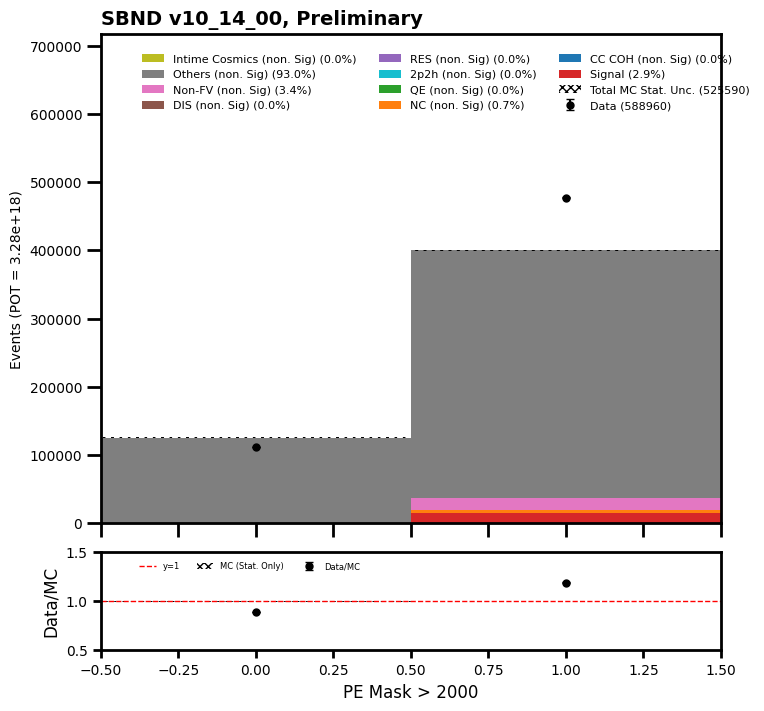

total_mc  [122913.04 402677.25]
total data =  588960
[147355 441605]
[122913.04 402677.25]
data ratio  [1.19885572 1.09667233]
mode sums =  [15446.2763671875, 4.300926685333252, 3654.9677734375, 98.92119598388672, 34.40741729736328, 88.8857192993164, 32.973777770996094, 17621.755859375, 488607.78125, 0.0]
total sums =  525590.2702870369


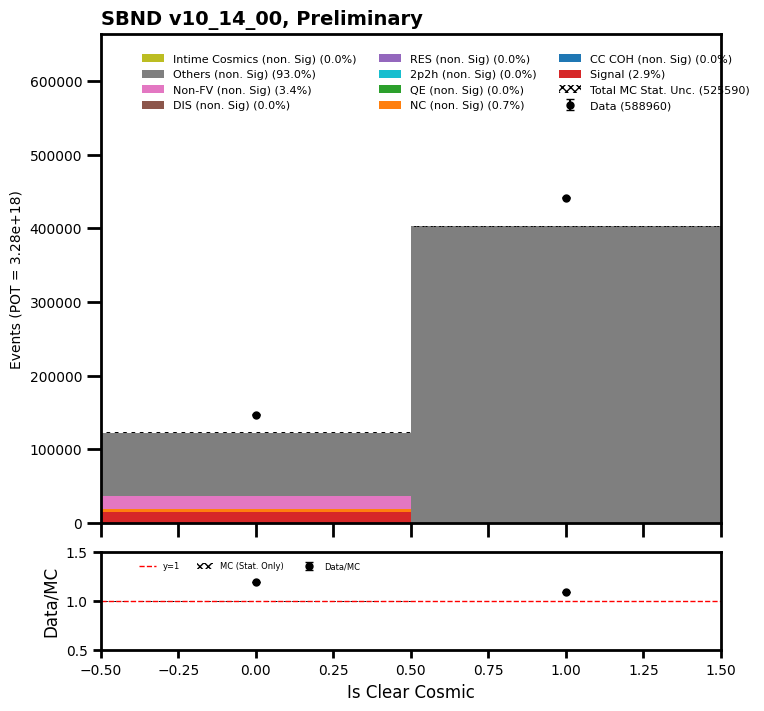

total_mc  [0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00 7.1682113e-01 0.0000000e+00 0.0000000e+00 7.1682113e-01
 1.0608952e+02 1.4941136e+04 2.7266943e+03 2.8435312e+03 2.9804453e+03
 2.8456836e+03 7.5722617e+03 4.3129658e+03 4.4176299e+03 4.4463032e+03
 4.4599146e+03 4.5789014e+03 4.4821318e+03 4.8649092e+03 4.9946372e+03
 4.9910610e+03 5.0691885e+03 5.1057422e+03 5.1272500e+03 5.2684629e+03
 5.3680898e+03 5.3795586e+03 5.4906660e+03 5.6827598e+03 5.7981816e+03
 5.7272012e+03 5.8712852e+03 5.9673301e+03 6.0533516e+03 6.1737676e+03
 6.1845254e+03 6.3859531e+03 6.4332246e+03 6.5608652e+03 3.3959695e+04
 9.6215508e+03 1.0159887e+04 1.0438723e+04 1.0464512e+04 9.1262461e+03
 9.2975762e+03 1.0367039e+04 1.0490314e+04 1.0103240e+04 9.6223281e+03
 3.4877875e+04 6.6912656e+03 6.5508203e+03 6.4283535e+03 6.3165254e+03
 6.2195586e+03 5.9256602e+03 5.9500215e+03 5.7826719e+03 5.7675684e+03
 5.5548691e+03 5.7121504e+03 5.5376016e+03 5.3257031e+03 5.2445605e

/tmp/ipykernel_1484/3524794362.py:119: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = mc_stat_err / total_mc
/tmp/ipykernel_1484/3524794362.py:120: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = total_mc / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: invalid value encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:178: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = data_eylow / total_mc
/tmp/ipykernel_1484/3524794362.py:179: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc


total data =  588820
[    0     0     0     0     0     0     0     0     0     0   144 17036
  2948  3350  3590  3416  8879  5008  4922  4914  5022  5071  5320  5426
  5509  5566  5595  5542  5766  5770  5788  5834  5960  6093  6284  6318
  6400  6589  6500  6814  6768  6938  7002  7264 39216 10940 11663 11981
 11684 10569 10063 11388 11541 11413 10956 39514  7152  7327  7063  6971
  6761  6757  6378  6526  6312  6259  6099  6002  5876  6000  5823  5578
  5622  5632  5431  5391  5246  5083  5036  4902  4829  4885  4820  8231
  3337  3609  3368  3084 16925   231     0     0     0     0     0     0
     0     0     0     0]
[0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00 7.1682113e-01 0.0000000e+00 0.0000000e+00 7.1682113e-01
 1.0608952e+02 1.4941136e+04 2.7266943e+03 2.8435312e+03 2.9804453e+03
 2.8456836e+03 7.5722617e+03 4.3129658e+03 4.4176299e+03 4.4463032e+03
 4.4599146e+03 4.5789014e+03 4.4821318e+03 4.8649092e+03 4.9946372e+03
 4.9910610e+03

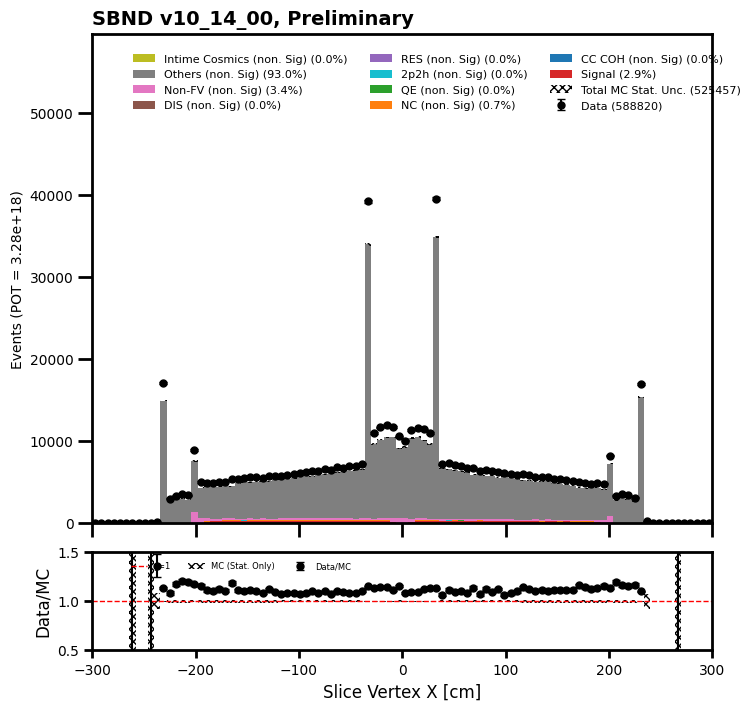

total_mc  [7.1682113e-01 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 7.1682107e-01 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 7.1682119e-01 7.1682119e-01 0.0000000e+00 7.1682113e-01 7.1682107e-01
 2.0931175e+02 6.2205884e+03 1.5282153e+03 1.9482632e+03 2.3016470e+03
 2.5453564e+03 2.7847607e+03 3.0184324e+03 3.2621470e+03 3.3703818e+03
 3.3632126e+03 3.5094397e+03 3.7201763e+03 3.8362939e+03 3.9043965e+03
 4.0448828e+03 4.0456035e+03 4.0542031e+03 4.1724785e+03 4.1524023e+03
 4.3165488e+03 4.4434238e+03 4.5072207e+03 4.4276543e+03 4.5172578e+03
 4.5530898e+03 4.6211875e+03 4.5681445e+03 4.5853418e+03 4.7373164e+03
 4.9466211e+03 4.8620371e+03 4.8111406e+03 4.8025410e+03 4.9036016e+03
 4.9752852e+03 4.8376543e+03 5.0254707e+03 4.9788770e+03 4.9838887e+03
 4.9810059e+03 5.0469902e+03 5.1602090e+03 5.1523340e+03 5.3594922e+03
 5.3939043e+03 5.3336934e+03 5.4060664e+03 5.4125449e+03 5.3659238e+03
 5.4856758e+03 5.5623203e+03 5.6741914e+03 5.7752148e+03 5.8239668e

/tmp/ipykernel_1484/3524794362.py:119: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = mc_stat_err / total_mc
/tmp/ipykernel_1484/3524794362.py:120: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = total_mc / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: divide by zero encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: invalid value encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:178: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = data_eylow / total_mc
/tmp/ipykernel_1484/3524794362.py:179: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc
/exp/sbnd/app/users/amoor/cafpyana/cafpyana/envs/venv_py39_cafpyana/lib/python3.9/site-packages/matplotlib/axes/_axes.py:3749: RuntimeWarning: overflow encountered in add
  low, high = dep + np.vstack(

total data =  588805
[     0      0      0      0      0      0      0      0      2      1
      0      1      0      0      0     21   8491   2812   2605   3042
   3174   3425   3550   3670   3887   3947   4168   4118   4201   4357
   4659   4586   4427   4554   4715   4955   4746   4766   4858   4771
   5084   5153   4955   5110   5059   5639   5058   5059   5274   6373
   5302   5107   5802   5268   5476   5488   5957   5544   5699   5800
   5780   5779   5818   6080   6072   6236   6069   6130   6344   6565
   6629   6710   6600   6977   7121   7084   7293   7643   7798   8035
   8421  10019  15347 197415  13939     70     35     32      8      4
      8      5      8      3      7      1      0      1      0      3]
[7.1682113e-01 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 7.1682107e-01 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 7.1682119e-01 7.1682119e-01 0.0000000e+00 7.1682113e-01 7.1682107e-01
 2.0931175e+02 6.2205884e+03 1.5282153e+03 1.9482632e+0

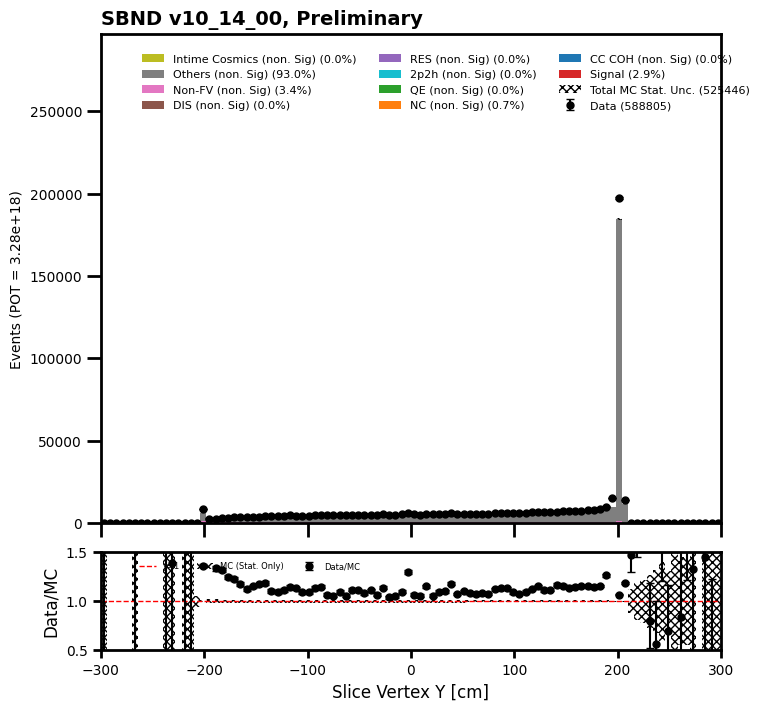

total_mc  [0.0000000e+00 7.1682107e-01 0.0000000e+00 7.1682119e-01 0.0000000e+00
 0.0000000e+00 0.0000000e+00 7.1682119e-01 2.1504633e+00 7.1682119e-01
 2.8672838e+00 3.5841045e+00 7.1682124e+00 4.6414429e+03 3.8142977e+04
 5.8461968e+03 5.9021230e+03 6.1365044e+03 6.3379160e+03 6.1709082e+03
 6.3371934e+03 6.2139268e+03 6.4296660e+03 6.1121357e+03 6.2862993e+03
 6.4181997e+03 6.4497461e+03 6.5601191e+03 6.4389946e+03 6.4103164e+03
 6.4841484e+03 6.3902383e+03 6.5773203e+03 6.3450820e+03 6.5680000e+03
 6.4325469e+03 6.5457754e+03 6.4734121e+03 6.6268223e+03 6.5357305e+03
 6.5895117e+03 6.3701484e+03 6.5787871e+03 6.4303848e+03 6.6052988e+03
 6.4461406e+03 6.4497227e+03 6.5730391e+03 6.6224785e+03 6.6217539e+03
 6.5587109e+03 6.5637285e+03 6.5708828e+03 6.6102754e+03 6.6167637e+03
 6.4834258e+03 6.5636934e+03 6.5429434e+03 6.4863066e+03 6.5113535e+03
 6.5658770e+03 6.6411094e+03 6.5207109e+03 6.6009863e+03 6.5450625e+03
 6.6357383e+03 6.6660879e+03 6.4971543e+03 6.6165039e+03 6.4792148e

/tmp/ipykernel_1484/3524794362.py:119: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = mc_stat_err / total_mc
/tmp/ipykernel_1484/3524794362.py:120: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = total_mc / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: divide by zero encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: invalid value encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:178: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = data_eylow / total_mc
/tmp/ipykernel_1484/3524794362.py:179: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc
/exp/sbnd/app/users/amoor/cafpyana/cafpyana/envs/venv_py39_cafpyana/lib/python3.9/site-packages/matplotlib/axes/_axes.py:3749: RuntimeWarning: overflow encountered in add
  low, high = dep + np.vstack(

total data =  588813
[    2     0     0     1     0     0     0     2     0     1     1     6
     9 12279 37602  6428  6473  6561  6984  6955  7048  7048  7075  6737
  6667  7229  7032  7059  7116  7146  7245  6999  7133  7154  7206  6969
  7528  7106  7296  7356  7164  7292  7082  7179  7150  7256  7155  7127
  6194  6720  8005  7951  7806  7433  7367  7396  7273  7348  7229  7483
  7375  7292  7324  7340  7262  7201  7438  7513  7117  7245  7558  7419
  7390  7287  7525  7358  7291  7466  7448  7321  7387  7590  7590  7836
  7590 20487 12083    11     0     2     0     0     0     1     0     0
     0     2     1     0]
[0.0000000e+00 7.1682107e-01 0.0000000e+00 7.1682119e-01 0.0000000e+00
 0.0000000e+00 0.0000000e+00 7.1682119e-01 2.1504633e+00 7.1682119e-01
 2.8672838e+00 3.5841045e+00 7.1682124e+00 4.6414429e+03 3.8142977e+04
 5.8461968e+03 5.9021230e+03 6.1365044e+03 6.3379160e+03 6.1709082e+03
 6.3371934e+03 6.2139268e+03 6.4296660e+03 6.1121357e+03 6.2862993e+03
 6.4181997e+03

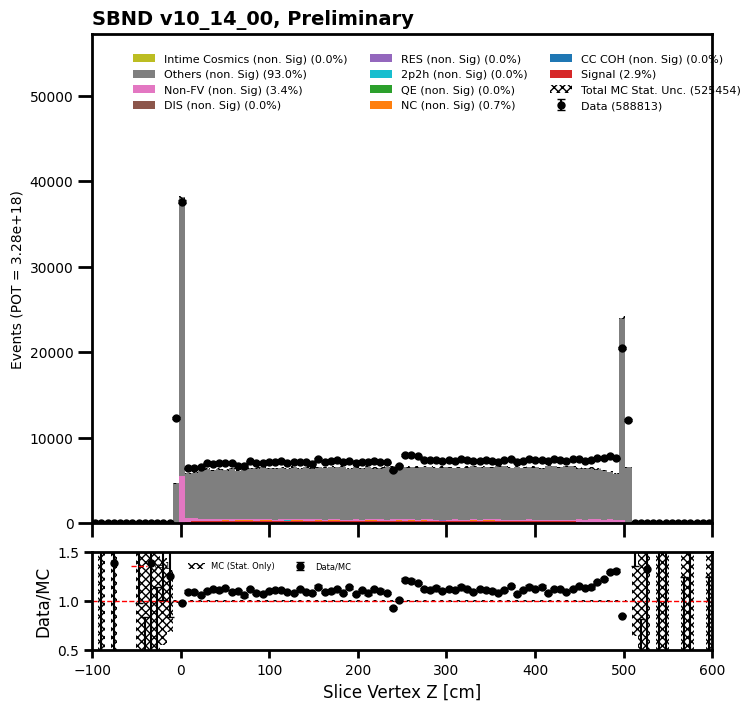

total_mc  [13110.481  20134.844  14667.811  14535.934  15003.986  15329.424
 15406.832  15277.084  15279.238  15368.125  15150.943  14686.447
 14518.01   14201.908  13946.719  13677.898  13159.678  12730.303
 12359.746  11888.8125 11559.756  11165.566  10505.348   9936.262
  9464.604   9046.648   8693.299   8339.252   7704.5195  7316.834
  7053.125   6657.2793  6560.922   6181.4824  5846.5977  5539.08
  5373.1377  5043.324   4878.0293  4857.213 ]
total data =  501014
[13995 24413 19753 18975 18965 18592 18440 18229 17977 17623 17185 16776
 16220 15777 15388 14882 14541 14103 13124 12971 12676 12012 11310 10830
 10461  9732  9239  8847  8397  7794  7405  7032  6915  6469  6352  5929
  5479  5392  5078  5736]
[13110.481  20134.844  14667.811  14535.934  15003.986  15329.424
 15406.832  15277.084  15279.238  15368.125  15150.943  14686.447
 14518.01   14201.908  13946.719  13677.898  13159.678  12730.303
 12359.746  11888.8125 11559.756  11165.566  10505.348   9936.262
  9464.604   9046.6

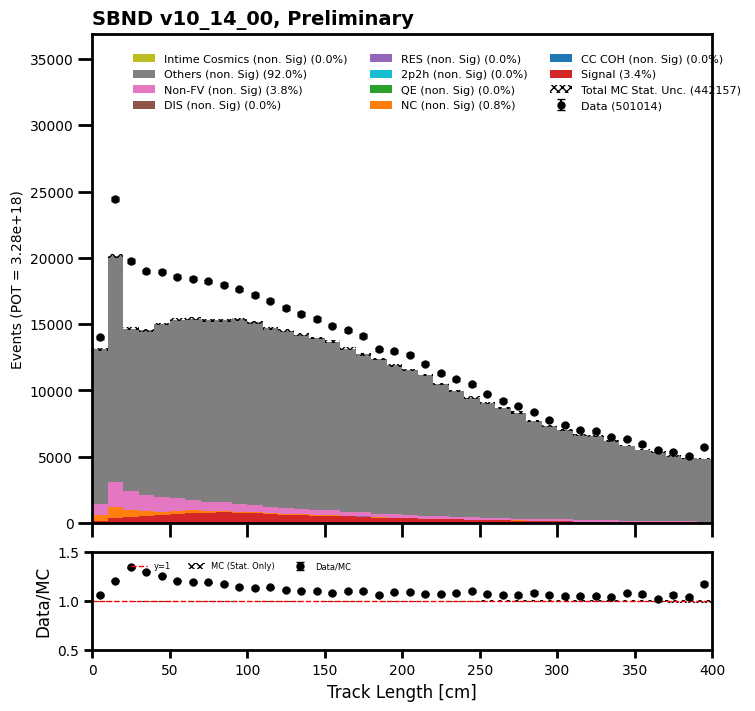

total_mc  [0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00 0.0000000e+00 0.0000000e+00 7.1682107e-01 3.5605774e+00
 1.1517767e+01 2.2890842e+01 6.2574928e+01 9.7565735e+01 1.7241806e+02
 2.4554828e+02 4.1846207e+02 6.1438904e+02 8.6084741e+02 1.2053639e+03
 1.6566021e+03 2.3026858e+03 3.3015254e+03 3.5824573e+03 3.1061816e+03
 2.7862598e+03 3.2075781e+03 4.2243203e+03 5.2258359e+03 5.4547012e+03
 5.7035391e+03 5.5418418e+03 5.3837266e+03 5.5117969e+03 5.6910938e+03
 5.9599980e+03 6.2674263e+03 6.6071602e+03 6.4227070e+03 6.3645981e+03
 6.2783984e+03 6.2662969e+03 5.8856636e+03 4.6884004e+03 1.8753418e+03
 9.7031250e+01 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00]


/tmp/ipykernel_1484/3524794362.py:119: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = mc_stat_err / total_mc
/tmp/ipykernel_1484/3524794362.py:120: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = total_mc / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: invalid value encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:178: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = data_eylow / total_mc
/tmp/ipykernel_1484/3524794362.py:179: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc


total data =  147317
[   0    0    0    0    0    0    0    0    0    0   16   36   68  118
  199  277  414  539  787 1101 1606 2447 3649 4138 3992 3943 4787 5883
 6727 6779 6888 6828 6676 6795 6816 7297 7514 7830 7455 7636 7222 7124
 6512 5185 1931  102    0    0    0    0]
[0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00 0.0000000e+00 0.0000000e+00 7.1682107e-01 3.5605774e+00
 1.1517767e+01 2.2890842e+01 6.2574928e+01 9.7565735e+01 1.7241806e+02
 2.4554828e+02 4.1846207e+02 6.1438904e+02 8.6084741e+02 1.2053639e+03
 1.6566021e+03 2.3026858e+03 3.3015254e+03 3.5824573e+03 3.1061816e+03
 2.7862598e+03 3.2075781e+03 4.2243203e+03 5.2258359e+03 5.4547012e+03
 5.7035391e+03 5.5418418e+03 5.3837266e+03 5.5117969e+03 5.6910938e+03
 5.9599980e+03 6.2674263e+03 6.6071602e+03 6.4227070e+03 6.3645981e+03
 6.2783984e+03 6.2662969e+03 5.8856636e+03 4.6884004e+03 1.8753418e+03
 9.7031250e+01 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00]
data ratio  [

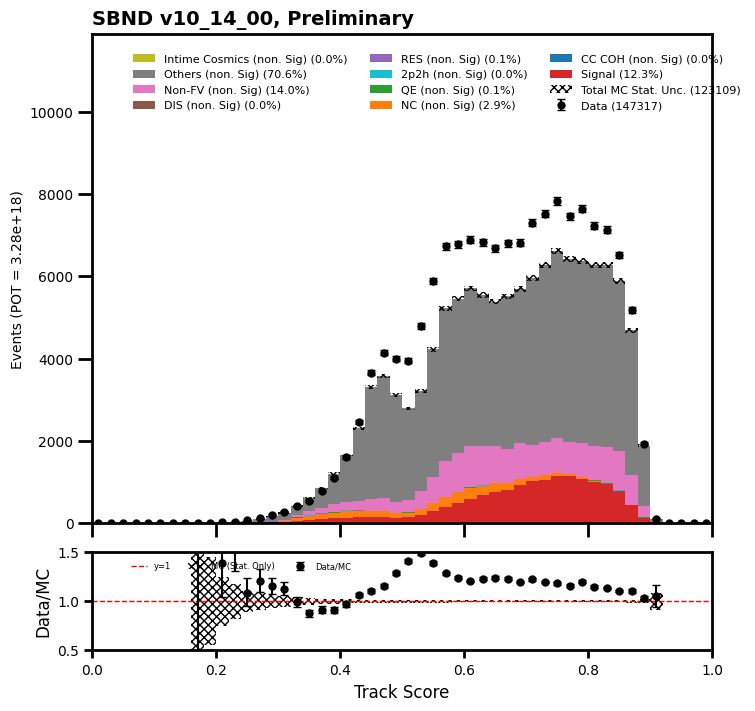

total_mc  [8.95662207e+03 9.59076953e+03 1.10458447e+04 9.99860059e+03
 1.18730322e+04 1.85686211e+04 3.31296406e+04 5.34451055e+04
 6.69875234e+04 6.42887773e+04 5.05248945e+04 3.48727070e+04
 2.39371211e+04 1.68845586e+04 1.28239824e+04 1.00038965e+04
 8.13494775e+03 6.91956104e+03 5.87854883e+03 5.14561328e+03
 4.49234424e+03 4.14450977e+03 3.67821289e+03 3.38061743e+03
 3.08240820e+03 2.79006079e+03 2.69800195e+03 2.50551978e+03
 2.39681274e+03 2.15846704e+03 2.02408215e+03 1.94850793e+03
 1.85154700e+03 1.76379297e+03 1.71425208e+03 1.65887122e+03
 1.61355481e+03 1.60902344e+03 1.55653333e+03 1.56143066e+03
 1.50811145e+03 1.50370703e+03 1.39740039e+03 1.19867188e+03
 1.04647473e+03 9.46734436e+02 7.54947327e+02 6.77443420e+02
 6.20695312e+02 5.42443359e+02 4.18093750e+02 3.95115265e+02
 3.12519531e+02 2.99607422e+02 2.75203156e+02 2.27021484e+02
 1.90447266e+02 1.68126953e+02 1.61677734e+02 1.34312500e+02
 1.15708984e+02 1.05601562e+02 7.89765625e+01 8.41015625e+01
 5.96132812e+0

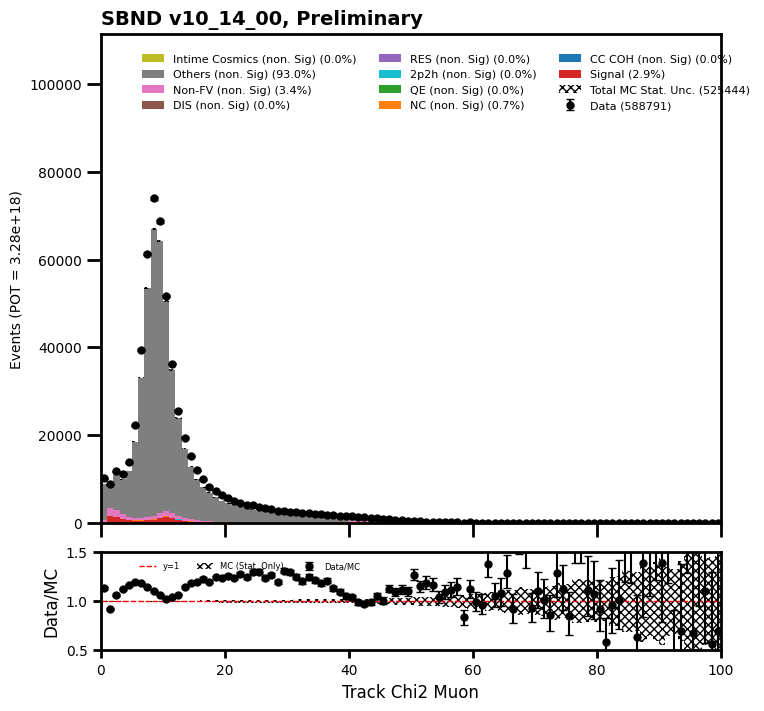

total_mc  [7954.5317   1479.5083   1230.028     520.39465   341.19534   255.89648
  217.90723   181.34961   161.2793    133.32422   138.3418    124.72363
  134.04102   112.53711   111.82031    91.75      121.85549   101.069336
   97.484375   92.4668     84.582054   78.13086    91.75002    77.41406
   98.91797   107.519554  101.78516    99.634766  115.4043     93.18457
  103.21875   103.21875   117.55469   118.271484  129.74023   116.83789
  106.803734  131.17383   103.93555   125.43945   134.75781   134.04102
  143.3594    126.15723   143.35938   141.20898   123.28906   118.27151
  137.62503   133.3252    120.421875  123.289085  116.12109   108.95315
  129.02344   127.58984   101.06836   113.9707    126.15625   121.13867
  122.57229   118.271484  124.00586   114.6875    118.98828   130.45703
  123.289085  136.1914    119.70508   131.17386   118.988304  142.64262
  122.572266  135.47461   144.79297   153.39453   155.54492   146.94336
  169.88086   165.58008   160.5625    194.96875   166

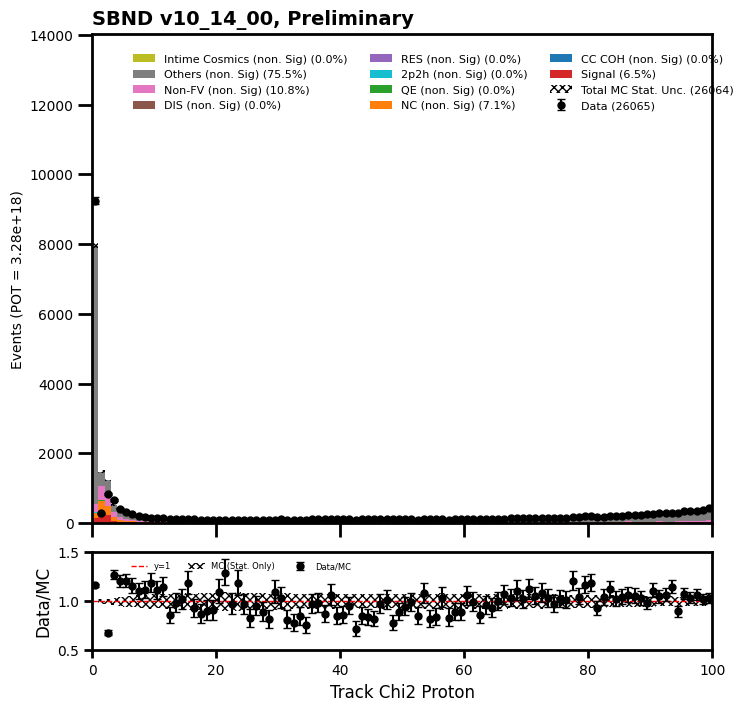

total_mc  [3.9463503e+05 1.2986112e+04 6.5655068e+03 3.7958530e+03 2.4247231e+03
 1.7191978e+03 1.2137463e+03 8.7895538e+02 6.8612622e+02 5.0681860e+02
 4.3090833e+02 3.3196310e+02 2.9094147e+02 2.2367586e+02 2.0724811e+02
 1.6776373e+02 1.5629688e+02 1.4404495e+02 1.1258594e+02 9.3224609e+01
 8.6000046e+01 8.3228516e+01 6.3052757e+01 5.2359375e+01 5.3054733e+01
 4.6537109e+01 5.4517624e+01 4.0894531e+01 3.9427780e+01 2.5125000e+01
 3.2201172e+01 3.0830078e+01 2.3695312e+01 2.6496117e+01 2.2253906e+01
 1.8607422e+01 2.0070312e+01 1.2185570e+01 1.7919922e+01 1.3623047e+01]
total data =  519784
[474977  13442   7825   4949   3466   2476   2019   1565   1214    979
    870    725    598    539    487    367    328    280    267    240
    234    214    192    151    144    140    117     92    106    101
    102     83     92     70     59     67     57     47     53     50]
[3.9463503e+05 1.2986112e+04 6.5655068e+03 3.7958530e+03 2.4247231e+03
 1.7191978e+03 1.2137463e+03 8.7895538e+02 6

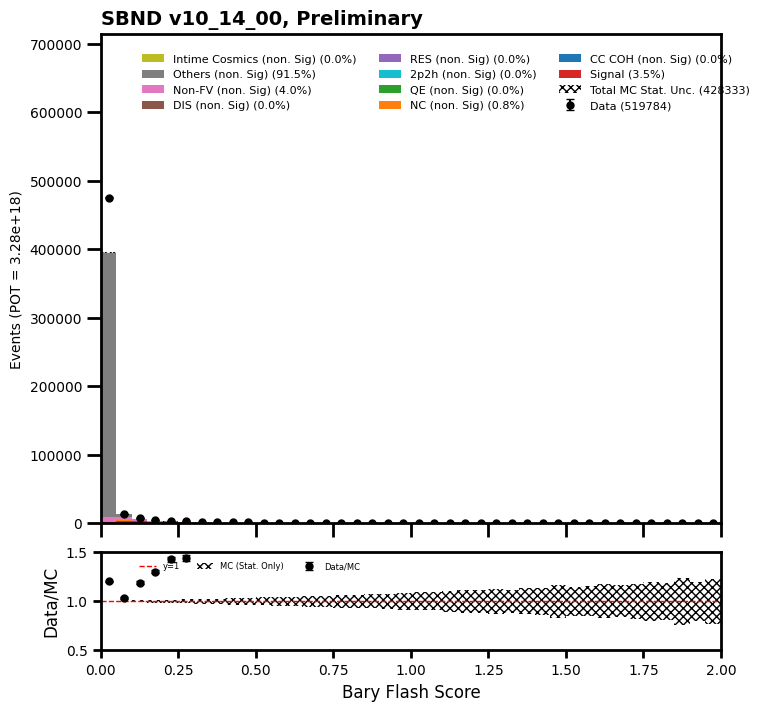

total_mc  [7.1682119e-01 0.0000000e+00 0.0000000e+00 7.1682096e-01 0.0000000e+00
 1.4336424e+00 1.4336424e+00 7.1682119e-01 1.4336414e+00 3.5841064e+00
 3.5841050e+00 6.4513907e+00 1.0035494e+01 4.0794502e+03 2.7818977e+04
 5.4361855e+03 5.7021274e+03 5.9902744e+03 6.0777183e+03 6.0676914e+03
 6.2454541e+03 6.2626689e+03 6.3307495e+03 6.1400874e+03 6.3673066e+03
 6.3608516e+03 6.3658691e+03 6.4067310e+03 6.4268057e+03 6.4196406e+03
 6.4447148e+03 6.4010059e+03 6.5465000e+03 6.4339688e+03 6.3952578e+03
 6.3615762e+03 6.3723066e+03 6.5537090e+03 6.3852246e+03 6.4913066e+03
 6.5035098e+03 6.4855605e+03 6.4769570e+03 6.5056719e+03 6.4733711e+03
 6.5486719e+03 6.4275215e+03 6.5429067e+03 6.4741230e+03 6.6411211e+03
 6.4131777e+03 6.4139102e+03 6.5035000e+03 6.4067148e+03 6.5336348e+03
 6.5063613e+03 6.4891484e+03 6.4963125e+03 6.3737871e+03 6.4676230e+03
 6.5049648e+03 6.3106504e+03 6.4368555e+03 6.4991875e+03 6.3372207e+03
 6.4612090e+03 6.4751016e+03 6.4559688e+03 6.4927598e+03 6.4353574e

/tmp/ipykernel_1484/3524794362.py:119: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = mc_stat_err / total_mc
/tmp/ipykernel_1484/3524794362.py:120: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = total_mc / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: divide by zero encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: invalid value encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:178: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = data_eylow / total_mc
/tmp/ipykernel_1484/3524794362.py:179: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc
/exp/sbnd/app/users/amoor/cafpyana/cafpyana/envs/venv_py39_cafpyana/lib/python3.9/site-packages/matplotlib/axes/_axes.py:3749: RuntimeWarning: overflow encountered in add
  low, high = dep + np.vstack(

total data =  588842
[    1     0     1     1     3     4     0     1     0     3     5    10
    26 10499 25927  6026  6730  6787  6949  6919  6973  6907  7007  6578
  6799  7055  7002  7068  7044  7115  7109  7159  7057  7120  7027  7129
  7393  6948  7088  7181  7274  7098  7263  6991  7197  6984  7016  7370
  6544  8581  7836  6851  7326  7291  7054  7116  7377  7191  7171  7182
  7130  7150  7142  7247  7230  7116  7104  7326  6974  7073  7038  7176
  6988  7056  7413  6980  6967  7034  7076  6989  6993  6855  6811  6888
  6958 35705 20957    35    22    11     8     3     4     2     5     3
     2     2     4     1]
[7.1682119e-01 0.0000000e+00 0.0000000e+00 7.1682096e-01 0.0000000e+00
 1.4336424e+00 1.4336424e+00 7.1682119e-01 1.4336414e+00 3.5841064e+00
 3.5841050e+00 6.4513907e+00 1.0035494e+01 4.0794502e+03 2.7818977e+04
 5.4361855e+03 5.7021274e+03 5.9902744e+03 6.0777183e+03 6.0676914e+03
 6.2454541e+03 6.2626689e+03 6.3307495e+03 6.1400874e+03 6.3673066e+03
 6.3608516e+03

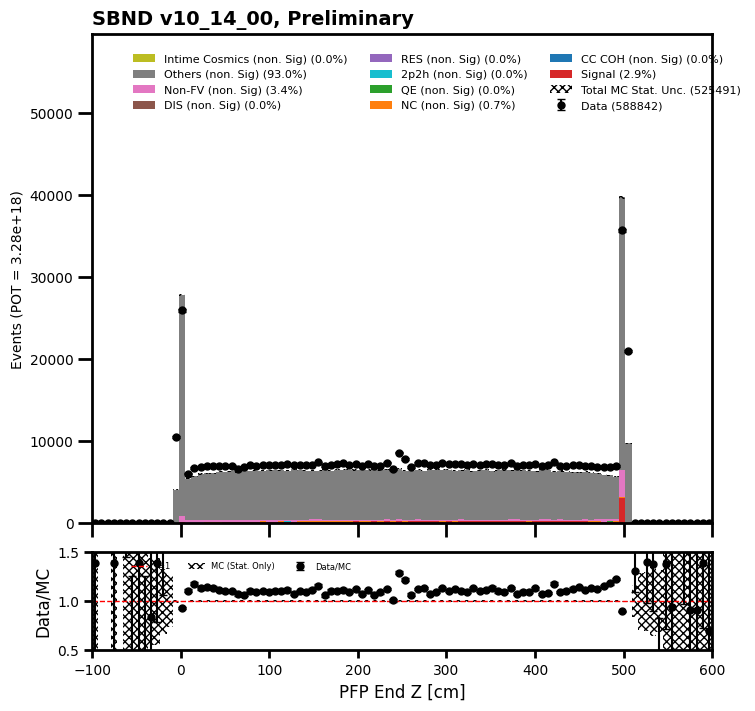

In [48]:
## Reco 1) Nocut
draw_reco_valid_plots(mc_bnb_cosmic_dfs["evt"], data_offbeam_light_dfs["evt"], data_bnb_light_dfs["evt"], "no_cut")

In [49]:
purity = 15446.276679992676/525590.2793292403
efficiency = 15446.276679992676/15446.276679992676
print("purity = ", round(purity*100,2), "% and efficiency = ", round(efficiency*100,2), "%")

purity =  2.94 % and efficiency =  100.0 %


/tmp/ipykernel_1484/3524794362.py:62: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  each_mc_hist_data = [np.histogram(data, bins=bins, weights=w)[0] for data, w in zip(all_mc_data, all_weights)]
/exp/sbnd/app/users/amoor/cafpyana/cafpyana/envs/venv_py39_cafpyana/lib/python3.9/site-packages/matplotlib/axes/_axes.py:6986: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  bins = np.histogram_bin_edges(
/exp/sbnd/app/users/amoor/cafpyana/cafpyana/envs/venv_py39_cafpyana/lib/python3.9/site-packages/matplotlib/axes/_axes.py:7001: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  m, bins = np.histogram(x[i], bins, weights=w[i], **hist_kwargs)
/tmp/ipykernel_1484/3524794362.py:92: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  hist_vals, _ = np.histogram(data, bins=bins, weights=w)
/tmp/ipykernel_1484/3524794362.py:93: RuntimeWarning

total_mc  [     0.         400027.94213915]
total data =  477121
[     0 477121]
[     0.         400027.94213915]
data ratio  [       nan 1.19271918]
mode sums =  [15377.4638671875, 4.300926685333252, 3585.4384765625, 98.20437622070312, 34.40741729736328, 88.8857192993164, 32.973777770996094, 17158.705078125, 363647.5625, 0.0]
total sums =  400027.9421391487


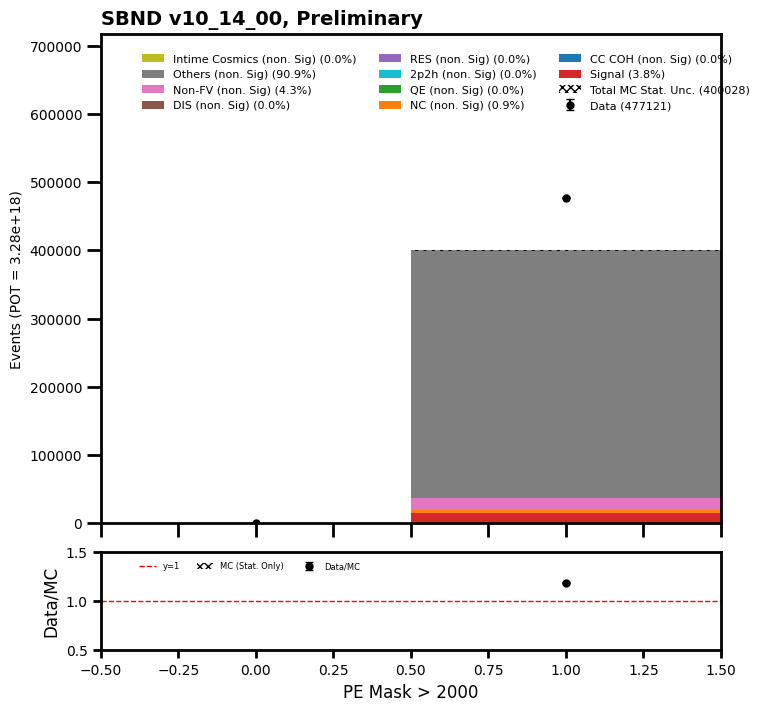

total_mc  [ 99428.56 300599.38]
total data =  477121
[123361 353760]
[ 99428.56 300599.38]
data ratio  [1.24069982 1.17684875]
mode sums =  [15377.4638671875, 4.300926685333252, 3585.4384765625, 98.20437622070312, 34.40741729736328, 88.8857192993164, 32.973777770996094, 17158.705078125, 363647.5703125, 0.0]
total sums =  400027.9499516487


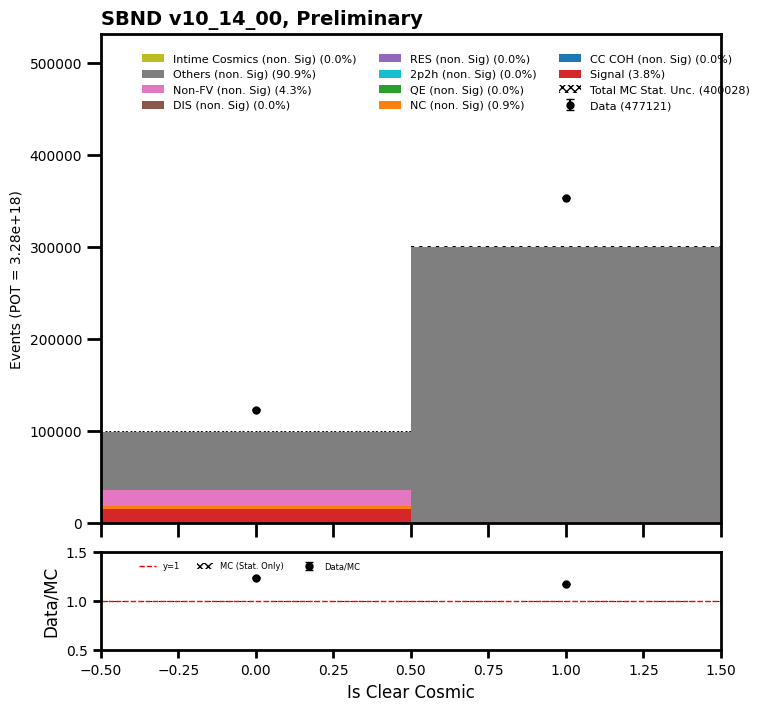

total_mc  [0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 7.1682113e-01
 8.3151245e+01 1.1132733e+04 2.0271016e+03 2.1131172e+03 2.2313887e+03
 2.1145508e+03 6.0146641e+03 3.3617803e+03 3.4585496e+03 3.4470864e+03
 3.3976255e+03 3.5596162e+03 3.4463623e+03 3.7323662e+03 3.8269810e+03
 3.8456177e+03 3.9309136e+03 3.9438164e+03 3.9423828e+03 4.0499006e+03
 4.0979258e+03 4.1832285e+03 4.2040137e+03 4.3380547e+03 4.4606348e+03
 4.4312383e+03 4.5186758e+03 4.5609844e+03 4.6305039e+03 4.7688574e+03
 4.7114961e+03 4.8541582e+03 4.9623809e+03 4.9910586e+03 2.5455613e+04
 7.2568652e+03 7.7206113e+03 7.8460566e+03 7.8869141e+03 6.9256914e+03
 7.0353555e+03 7.8532363e+03 7.9069863e+03 7.6976660e+03 7.2919863e+03
 2.6262740e+04 5.1071367e+03 4.9681523e+03 4.9564238e+03 4.8281816e+03
 4.7275898e+03 4.5517148e+03 4.5450898e+03 4.3741797e+03 4.4086934e+03
 4.2369277e+03 4.3993320e+03 4.2046719e+03 4.0868245e+03 4.0078284e

/tmp/ipykernel_1484/3524794362.py:119: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = mc_stat_err / total_mc
/tmp/ipykernel_1484/3524794362.py:120: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = total_mc / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: invalid value encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:178: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = data_eylow / total_mc
/tmp/ipykernel_1484/3524794362.py:179: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc


total data =  477008
[    0     0     0     0     0     0     0     0     0     0   124 13575
  2341  2654  2869  2767  7602  4142  4077  4034  4162  4182  4378  4447
  4495  4597  4597  4528  4727  4742  4731  4713  4832  4978  5132  5052
  5217  5356  5276  5538  5468  5648  5668  5795 31408  8849  9405  9646
  9412  8569  8103  9176  9362  9184  8844 31522  5845  5962  5726  5622
  5537  5476  5153  5278  5100  5094  5028  4820  4736  4951  4771  4523
  4571  4535  4404  4382  4274  4105  4080  4012  3976  3996  3904  6920
  2680  2859  2696  2447 13431   190     0     0     0     0     0     0
     0     0     0     0]
[0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 7.1682113e-01
 8.3151245e+01 1.1132733e+04 2.0271016e+03 2.1131172e+03 2.2313887e+03
 2.1145508e+03 6.0146641e+03 3.3617803e+03 3.4585496e+03 3.4470864e+03
 3.3976255e+03 3.5596162e+03 3.4463623e+03 3.7323662e+03 3.8269810e+03
 3.8456177e+03

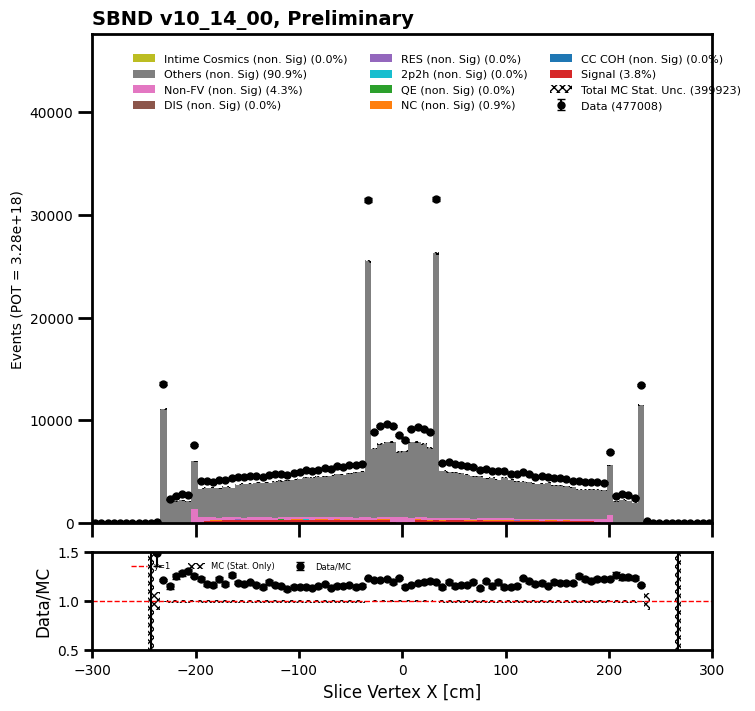

total_mc  [7.1682113e-01 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 7.1682113e-01 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 7.1682107e-01 7.1682119e-01 0.0000000e+00 7.1682113e-01 7.1682107e-01
 1.5124927e+02 4.8292314e+03 1.2156943e+03 1.5855652e+03 1.8149395e+03
 2.0335598e+03 2.1919668e+03 2.3840681e+03 2.5474985e+03 2.6327979e+03
 2.6349470e+03 2.7481995e+03 2.9374360e+03 3.0112651e+03 3.0105469e+03
 3.1252383e+03 3.1746914e+03 3.1510371e+03 3.2141194e+03 3.1639377e+03
 3.3008496e+03 3.4585469e+03 3.4764648e+03 3.4012012e+03 3.5144629e+03
 3.5287871e+03 3.6126562e+03 3.5187502e+03 3.5624824e+03 3.6427659e+03
 3.8061895e+03 3.8054690e+03 3.7201799e+03 3.7122893e+03 3.8126445e+03
 3.8742891e+03 3.7259182e+03 3.8685432e+03 3.8205276e+03 3.8470449e+03
 3.8119319e+03 3.8879062e+03 3.9359299e+03 3.9689084e+03 4.1316191e+03
 4.1086738e+03 4.0986523e+03 4.1552637e+03 4.1975762e+03 4.1466621e+03
 4.1452520e+03 4.3050723e+03 4.4039922e+03 4.4212012e+03 4.4470176e

/tmp/ipykernel_1484/3524794362.py:119: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = mc_stat_err / total_mc
/tmp/ipykernel_1484/3524794362.py:120: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = total_mc / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: divide by zero encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: invalid value encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:178: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = data_eylow / total_mc
/tmp/ipykernel_1484/3524794362.py:179: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc
/exp/sbnd/app/users/amoor/cafpyana/cafpyana/envs/venv_py39_cafpyana/lib/python3.9/site-packages/matplotlib/axes/_axes.py:3749: RuntimeWarning: overflow encountered in add
  low, high = dep + np.vstack(

total data =  476995
[     0      0      0      0      0      0      0      0      2      1
      0      1      0      0      0     17   6855   2288   2152   2469
   2597   2815   2928   3027   3157   3245   3435   3347   3433   3593
   3805   3747   3615   3738   3845   4070   3913   3919   3975   3942
   4161   4222   4088   4196   4121   4641   4169   4155   4323   5143
   4339   4234   4764   4329   4537   4508   4857   4511   4679   4717
   4662   4763   4764   4925   4942   5041   4880   4977   5113   5349
   5341   5469   5377   5665   5700   5705   5908   6206   6257   6491
   6738   7972  12329 158549  11093     57     28     29      6      3
      5      5      6      3      7      1      0      1      0      3]
[7.1682113e-01 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 7.1682113e-01 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 7.1682107e-01 7.1682119e-01 0.0000000e+00 7.1682113e-01 7.1682107e-01
 1.5124927e+02 4.8292314e+03 1.2156943e+03 1.5855652e+0

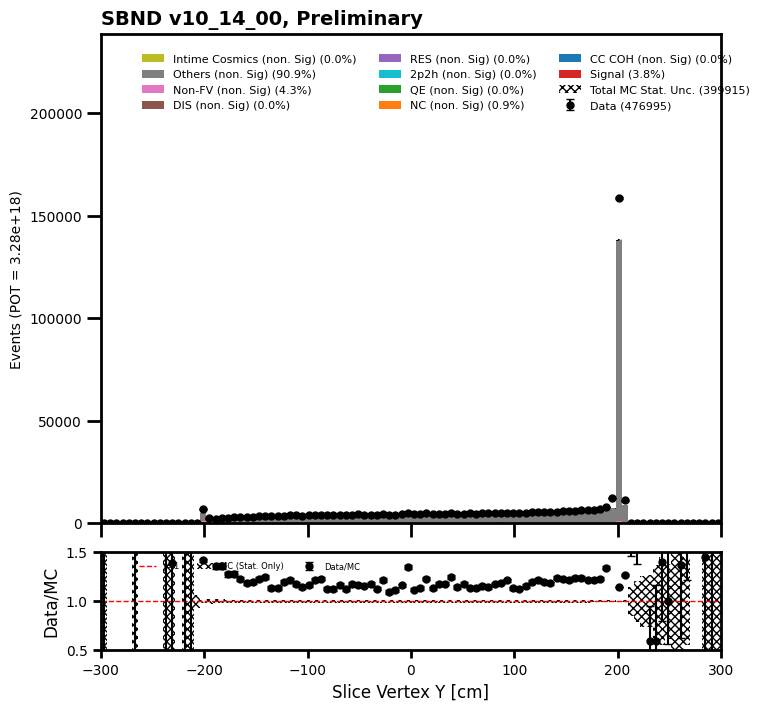

total_mc  [0.0000000e+00 0.0000000e+00 0.0000000e+00 7.1682107e-01 0.0000000e+00
 0.0000000e+00 0.0000000e+00 7.1682119e-01 1.4336421e+00 7.1682119e-01
 1.4336424e+00 2.8672848e+00 6.4513888e+00 3.4565312e+03 2.9576523e+04
 4.4656499e+03 4.5079414e+03 4.6362563e+03 4.8297754e+03 4.7351641e+03
 4.8433965e+03 4.7229775e+03 4.9071934e+03 4.6871392e+03 4.8305005e+03
 4.8605947e+03 4.8950098e+03 4.9917773e+03 4.9093345e+03 4.8433945e+03
 4.9330000e+03 4.8892715e+03 4.9881992e+03 4.8505586e+03 5.0663203e+03
 4.8770820e+03 4.9975020e+03 4.9416133e+03 5.0383535e+03 4.9889082e+03
 5.0075566e+03 4.8390957e+03 4.9638027e+03 4.8778125e+03 5.0340605e+03
 4.9236836e+03 4.8613027e+03 5.0003887e+03 5.0333359e+03 5.0419570e+03
 4.9788789e+03 4.9638027e+03 4.9581094e+03 5.0125547e+03 5.0419453e+03
 4.8950117e+03 5.0347734e+03 4.9444629e+03 4.9079023e+03 4.9638301e+03
 4.9308398e+03 5.0720508e+03 4.9588008e+03 5.0168652e+03 5.0713379e+03
 5.0537305e+03 5.0648516e+03 4.9843398e+03 5.0311758e+03 4.9405352e

/tmp/ipykernel_1484/3524794362.py:119: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = mc_stat_err / total_mc
/tmp/ipykernel_1484/3524794362.py:120: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = total_mc / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: divide by zero encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: invalid value encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:178: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = data_eylow / total_mc
/tmp/ipykernel_1484/3524794362.py:179: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc
/exp/sbnd/app/users/amoor/cafpyana/cafpyana/envs/venv_py39_cafpyana/lib/python3.9/site-packages/matplotlib/axes/_axes.py:3749: RuntimeWarning: overflow encountered in add
  low, high = dep + np.vstack(

total data =  477002
[    1     0     0     1     0     0     0     2     0     1     1     6
     6  9916 30645  5173  5220  5389  5686  5614  5774  5696  5746  5501
  5384  5884  5763  5710  5690  5815  5882  5672  5881  5764  5870  5664
  6071  5781  5918  5970  5818  5858  5695  5818  5813  5927  5813  5777
  5076  5459  6484  6430  6361  5998  5982  5971  5902  5970  5860  6100
  6035  5904  5917  5937  5869  5863  6029  6121  5757  5834  6125  5999
  6012  5886  6110  6021  5884  6003  6056  5903  5963  6099  6112  6227
  6076 16386  9649    10     0     2     0     0     0     1     0     0
     0     2     1     0]
[0.0000000e+00 0.0000000e+00 0.0000000e+00 7.1682107e-01 0.0000000e+00
 0.0000000e+00 0.0000000e+00 7.1682119e-01 1.4336421e+00 7.1682119e-01
 1.4336424e+00 2.8672848e+00 6.4513888e+00 3.4565312e+03 2.9576523e+04
 4.4656499e+03 4.5079414e+03 4.6362563e+03 4.8297754e+03 4.7351641e+03
 4.8433965e+03 4.7229775e+03 4.9071934e+03 4.6871392e+03 4.8305005e+03
 4.8605947e+03

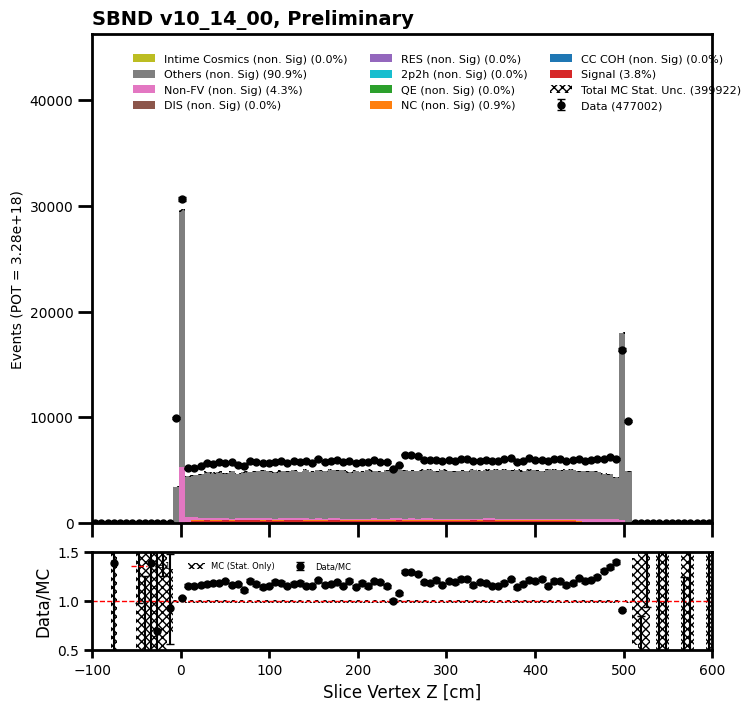

total_mc  [ 9223.231  15604.686  11412.123  11349.047  11689.523  11908.146
 11974.09   11824.279  11819.986  11776.25   11604.939  11278.8125
 11131.863  10837.973  10706.791  10367.031  10024.391   9701.145
  9407.975   9125.525   8787.918   8445.32    7977.9316  7616.676
  7201.6816  6838.9355  6598.834   6325.7363  5846.4785  5452.4355
  5328.924   4976.217   4966.2344  4655.7676  4349.037   4193.836
  4040.8242  3797.1992  3685.1543  3615.5566]
total data =  406112
[10818 19527 15948 15414 15451 15180 15043 14946 14639 14345 14018 13638
 13271 12886 12519 12119 11813 11489 10523 10474 10275  9758  9135  8797
  8499  7872  7448  7247  6774  6338  6009  5696  5570  5246  5147  4774
  4398  4363  4075  4630]
[ 9223.231  15604.686  11412.123  11349.047  11689.523  11908.146
 11974.09   11824.279  11819.986  11776.25   11604.939  11278.8125
 11131.863  10837.973  10706.791  10367.031  10024.391   9701.145
  9407.975   9125.525   8787.918   8445.32    7977.9316  7616.676
  7201.6816  68

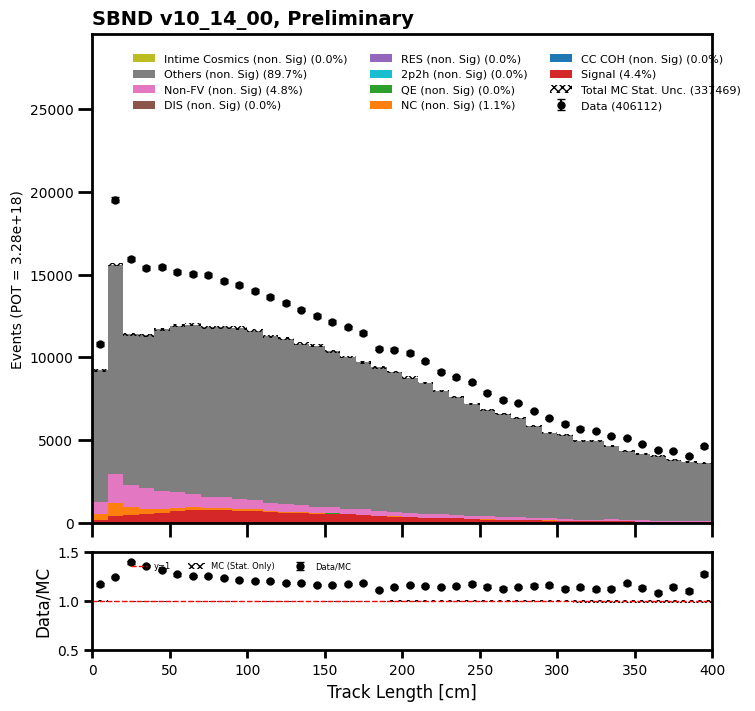

total_mc  [0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00 0.0000000e+00 0.0000000e+00 7.1682107e-01 1.4668274e+00
 1.0767767e+01 1.9390842e+01 5.2356178e+01 8.3284485e+01 1.3573056e+02
 2.0026895e+02 3.5587500e+02 5.1954529e+02 7.0473608e+02 9.9984424e+02
 1.3381119e+03 1.7973049e+03 2.4920664e+03 2.7010315e+03 2.2953086e+03
 2.1112227e+03 2.4851621e+03 3.2890762e+03 4.1202754e+03 4.4172324e+03
 4.6138379e+03 4.5525703e+03 4.4506523e+03 4.5218203e+03 4.7528691e+03
 4.9304668e+03 5.1149224e+03 5.4417148e+03 5.2893301e+03 5.2710532e+03
 5.1777930e+03 5.1527559e+03 4.8267563e+03 3.7881633e+03 1.4795625e+03
 7.3937500e+01 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00]


/tmp/ipykernel_1484/3524794362.py:119: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = mc_stat_err / total_mc
/tmp/ipykernel_1484/3524794362.py:120: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = total_mc / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: invalid value encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:178: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = data_eylow / total_mc
/tmp/ipykernel_1484/3524794362.py:179: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc


total data =  123333
[   0    0    0    0    0    0    0    0    0    0   14   33   57   96
  165  240  365  474  688  957 1360 2010 2927 3275 3143 3134 3793 4748
 5529 5587 5697 5716 5652 5747 5815 6243 6440 6708 6381 6483 6114 6081
 5553 4386 1641   81    0    0    0    0]
[0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00 0.0000000e+00 0.0000000e+00 7.1682107e-01 1.4668274e+00
 1.0767767e+01 1.9390842e+01 5.2356178e+01 8.3284485e+01 1.3573056e+02
 2.0026895e+02 3.5587500e+02 5.1954529e+02 7.0473608e+02 9.9984424e+02
 1.3381119e+03 1.7973049e+03 2.4920664e+03 2.7010315e+03 2.2953086e+03
 2.1112227e+03 2.4851621e+03 3.2890762e+03 4.1202754e+03 4.4172324e+03
 4.6138379e+03 4.5525703e+03 4.4506523e+03 4.5218203e+03 4.7528691e+03
 4.9304668e+03 5.1149224e+03 5.4417148e+03 5.2893301e+03 5.2710532e+03
 5.1777930e+03 5.1527559e+03 4.8267563e+03 3.7881633e+03 1.4795625e+03
 7.3937500e+01 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00]
data ratio  [

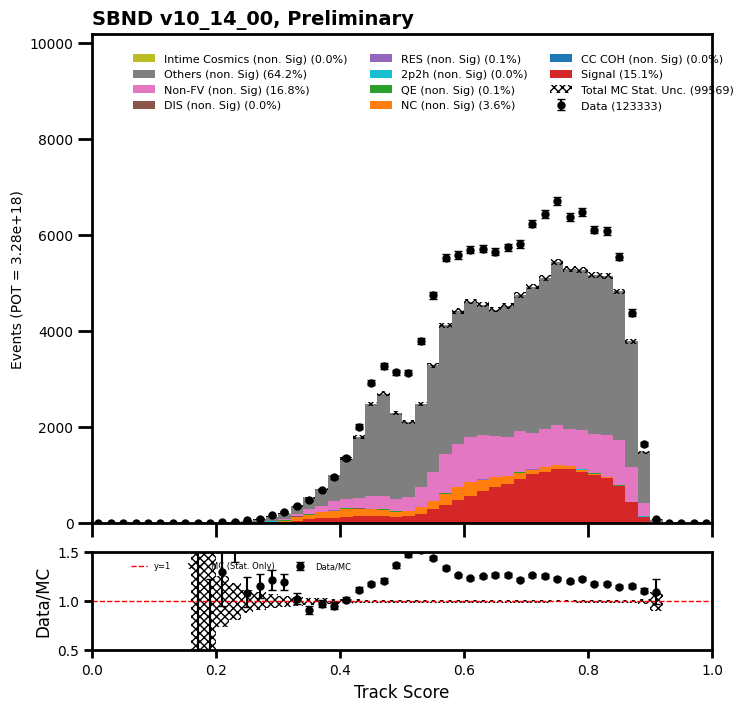

total_mc  [6.74381445e+03 7.95288232e+03 8.93344141e+03 7.97078223e+03
 9.21299316e+03 1.41008359e+04 2.49337832e+04 4.01814961e+04
 5.04245117e+04 4.85421992e+04 3.83271289e+04 2.66327305e+04
 1.83087090e+04 1.28071836e+04 9.73240820e+03 7.55422852e+03
 6.17855127e+03 5.19631104e+03 4.43197852e+03 3.85282251e+03
 3.37795532e+03 3.14077954e+03 2.74426758e+03 2.54378540e+03
 2.32247656e+03 2.09766821e+03 2.02798633e+03 1.92090051e+03
 1.82383215e+03 1.63644556e+03 1.51880872e+03 1.49308411e+03
 1.41688293e+03 1.36083008e+03 1.31116418e+03 1.25645325e+03
 1.23206653e+03 1.24697266e+03 1.22027161e+03 1.25395312e+03
 1.21213489e+03 1.21281836e+03 1.14170410e+03 9.66628967e+02
 8.28744263e+02 7.45558655e+02 6.01209045e+02 5.25824280e+02
 4.83511719e+02 4.15261719e+02 3.23939453e+02 3.13275421e+02
 2.52894531e+02 2.29892578e+02 2.15609406e+02 1.69554688e+02
 1.52982422e+02 1.27908203e+02 1.19240234e+02 1.07843750e+02
 9.54902344e+01 7.97890625e+01 6.25390625e+01 6.82265625e+01
 4.38632812e+0

/tmp/ipykernel_1484/3524794362.py:119: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = mc_stat_err / total_mc
/tmp/ipykernel_1484/3524794362.py:120: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = total_mc / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: divide by zero encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:178: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = data_eylow / total_mc
/tmp/ipykernel_1484/3524794362.py:179: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc
/exp/sbnd/app/users/amoor/cafpyana/cafpyana/envs/venv_py39_cafpyana/lib/python3.9/site-packages/matplotlib/axes/_axes.py:3749: RuntimeWarning: overflow encountered in add
  low, high = dep + np.vstack([-(1 - lolims), 1 - uplims]) * err


total data =  476987
[ 8206  7521  9999  9325 11311 18078 31888 49433 59489 55624 42059 29311
 20708 15604 12162  9586  8039  6588  5865  5151  4546  4087  3756  3421
  3248  2921  2721  2654  2380  2298  2147  1940  1835  1783  1654  1579
  1621  1493  1430  1362  1316  1239  1137   987   920   801   708   625
   567   485   451   374   304   289   223   210   179   167   106   124
    92    83    93    76    57    57    41    52    53    33    37    24
    19    20    25    14    18    16    11    14    13     8    10     9
    11     9     5     5     8     7     5     7     2     2     4     2
     3     4     2     1]
[6.74381445e+03 7.95288232e+03 8.93344141e+03 7.97078223e+03
 9.21299316e+03 1.41008359e+04 2.49337832e+04 4.01814961e+04
 5.04245117e+04 4.85421992e+04 3.83271289e+04 2.66327305e+04
 1.83087090e+04 1.28071836e+04 9.73240820e+03 7.55422852e+03
 6.17855127e+03 5.19631104e+03 4.43197852e+03 3.85282251e+03
 3.37795532e+03 3.14077954e+03 2.74426758e+03 2.54378540e+03
 2.

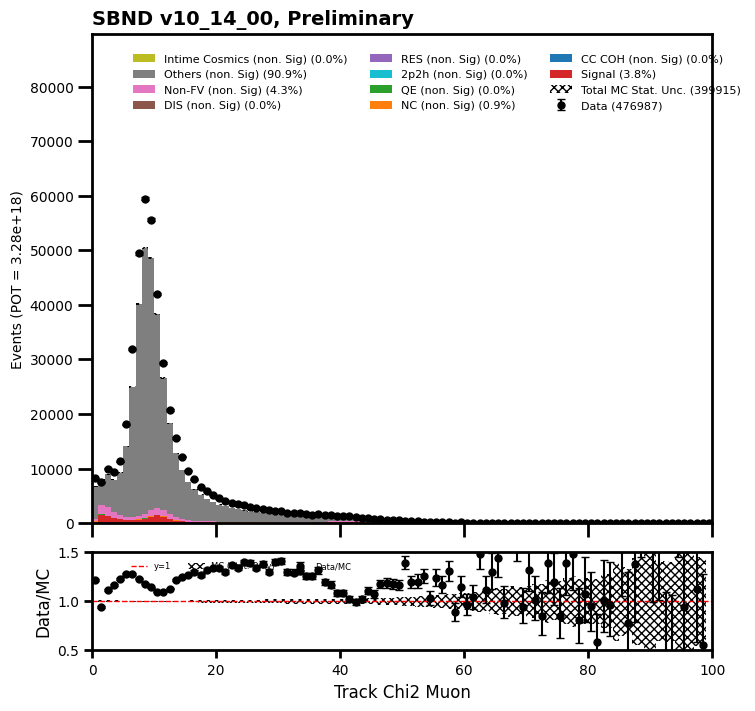

total_mc  [5971.101    1361.2366   1119.6404    461.61728   285.2852    221.49023
  187.80078   155.54492   134.75781   115.4043    118.271484  102.50195
  106.08594    92.4668     94.61719    73.11328    97.4844     74.546875
   85.29883    78.84766    70.96291    60.210938   80.28127    62.36133
   80.99805    90.31643    87.44922    74.546875   93.18359    83.14844
   80.99805    80.99805    96.76758    95.333984   99.634766   91.75
   81.71487   102.50195    78.13086   101.78516   113.9707    108.23633
  113.970726  103.21875   115.4043    113.9707     89.59961    96.7676
  108.23635   103.21875    94.61719   101.78518    86.73242    84.582054
  100.35156    95.333984   79.56445    86.73242   106.08594   101.06836
   98.91799    91.75       95.333984   80.99805    88.166016  108.23633
   91.75002   108.23633    93.18359   103.21877    87.44924   111.10356
   93.18359   105.36914   113.25391   124.72266   127.58984   116.12109
  132.60742   121.13867   128.30664   154.82812   126.15

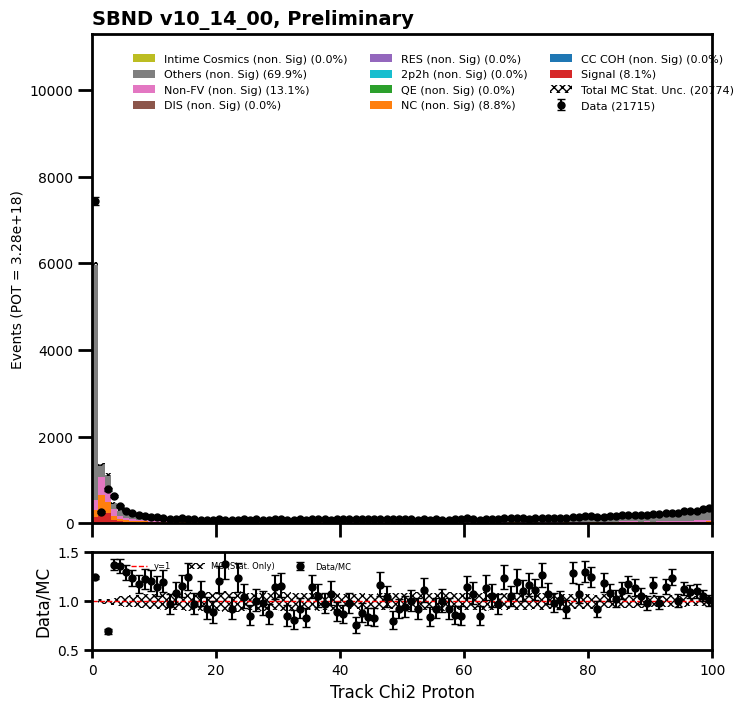

total_mc  [3.1021041e+05 1.2715204e+04 6.4902842e+03 3.7699487e+03 2.4140239e+03
 1.7184790e+03 1.2109377e+03 8.7889288e+02 6.8543970e+02 5.0688110e+02
 4.3016028e+02 3.3186935e+02 2.9106744e+02 2.2367586e+02 2.0649811e+02
 1.6773248e+02 1.5629688e+02 1.4410745e+02 1.1258594e+02 9.3162109e+01
 8.6093796e+01 8.3134766e+01 6.3115257e+01 5.1580078e+01 5.3054733e+01
 4.6599609e+01 5.4517624e+01 4.0832031e+01 3.9427780e+01 2.5125000e+01
 3.2263672e+01 3.0767578e+01 2.3695312e+01 2.6558617e+01 2.2191406e+01
 1.8669922e+01 2.0070312e+01 1.2185570e+01 1.7919922e+01 1.3623047e+01]
total data =  434682
[391456  12429   7528   4838   3406   2451   1998   1551   1209    979
    867    720    597    535    485    364    325    278    265    238
    234    214    192    151    144    140    116     91    106    100
    100     83     92     69     59     66     57     47     53     49]
[3.1021041e+05 1.2715204e+04 6.4902842e+03 3.7699487e+03 2.4140239e+03
 1.7184790e+03 1.2109377e+03 8.7889288e+02 6

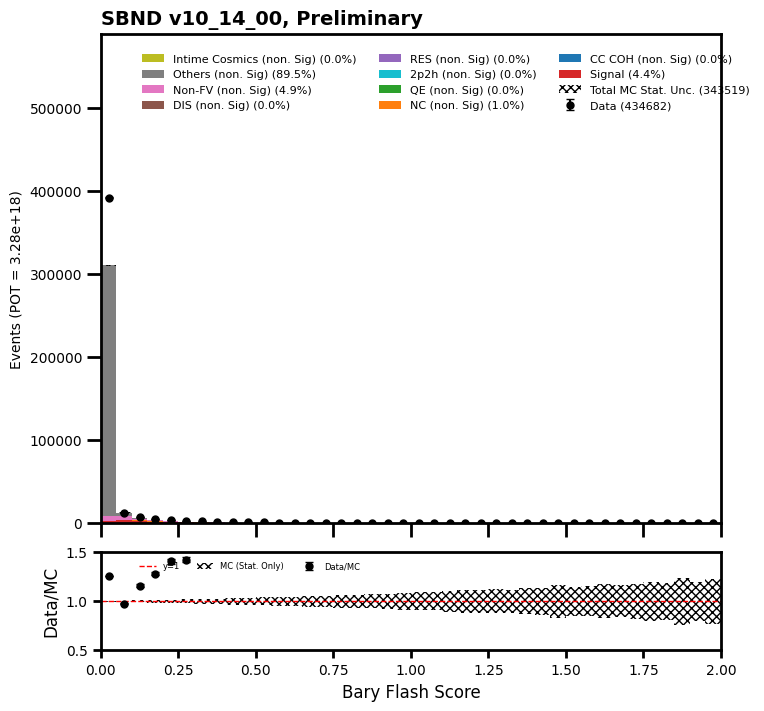

total_mc  [7.1682119e-01 0.0000000e+00 0.0000000e+00 7.1682119e-01 0.0000000e+00
 1.4336421e+00 7.1682119e-01 7.1682072e-01 0.0000000e+00 2.8672848e+00
 3.5841055e+00 2.8672843e+00 7.1682119e+00 3.0221338e+03 2.0906881e+04
 4.0334216e+03 4.3014985e+03 4.5065049e+03 4.5358960e+03 4.6133086e+03
 4.7839072e+03 4.7272803e+03 4.8233315e+03 4.6441245e+03 4.7896348e+03
 4.8541523e+03 4.8054004e+03 4.8656294e+03 4.8785190e+03 4.8921367e+03
 4.9502012e+03 4.8677676e+03 4.9552148e+03 4.9215371e+03 4.8469766e+03
 4.8670527e+03 4.8312109e+03 4.9996582e+03 4.8218828e+03 4.9301406e+03
 4.9588105e+03 4.9659609e+03 4.9057363e+03 4.9774512e+03 4.9423262e+03
 4.9810195e+03 4.8620332e+03 4.9853208e+03 4.8828281e+03 5.0197227e+03
 4.8505684e+03 4.8663125e+03 4.9115078e+03 4.8706426e+03 4.9616719e+03
 4.9616504e+03 4.8885469e+03 4.9710117e+03 4.8577129e+03 4.9509297e+03
 4.9071836e+03 4.8333555e+03 4.8814062e+03 5.0003535e+03 4.8648965e+03
 4.9065039e+03 4.9367891e+03 4.8712969e+03 4.9340234e+03 4.9088379e

/tmp/ipykernel_1484/3524794362.py:119: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = mc_stat_err / total_mc
/tmp/ipykernel_1484/3524794362.py:120: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = total_mc / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: divide by zero encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: invalid value encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:178: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = data_eylow / total_mc
/tmp/ipykernel_1484/3524794362.py:179: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc
/exp/sbnd/app/users/amoor/cafpyana/cafpyana/envs/venv_py39_cafpyana/lib/python3.9/site-packages/matplotlib/axes/_axes.py:3749: RuntimeWarning: overflow encountered in add
  low, high = dep + np.vstack(

total data =  477030
[    0     0     0     1     2     3     0     1     0     1     5     8
    24  8421 20816  4799  5335  5433  5582  5508  5568  5585  5693  5290
  5492  5686  5679  5709  5732  5769  5777  5768  5761  5793  5682  5787
  5993  5674  5717  5818  5924  5718  5842  5702  5861  5657  5663  5945
  5316  7000  6365  5566  5978  5915  5734  5801  5999  5818  5858  5875
  5835  5818  5766  5889  5877  5791  5728  5947  5686  5699  5719  5819
  5702  5743  6018  5665  5618  5703  5739  5656  5673  5558  5488  5543
  5640 29193 16980    30    19    10     6     1     4     2     4     3
     2     2     4     1]
[7.1682119e-01 0.0000000e+00 0.0000000e+00 7.1682119e-01 0.0000000e+00
 1.4336421e+00 7.1682119e-01 7.1682072e-01 0.0000000e+00 2.8672848e+00
 3.5841055e+00 2.8672843e+00 7.1682119e+00 3.0221338e+03 2.0906881e+04
 4.0334216e+03 4.3014985e+03 4.5065049e+03 4.5358960e+03 4.6133086e+03
 4.7839072e+03 4.7272803e+03 4.8233315e+03 4.6441245e+03 4.7896348e+03
 4.8541523e+03

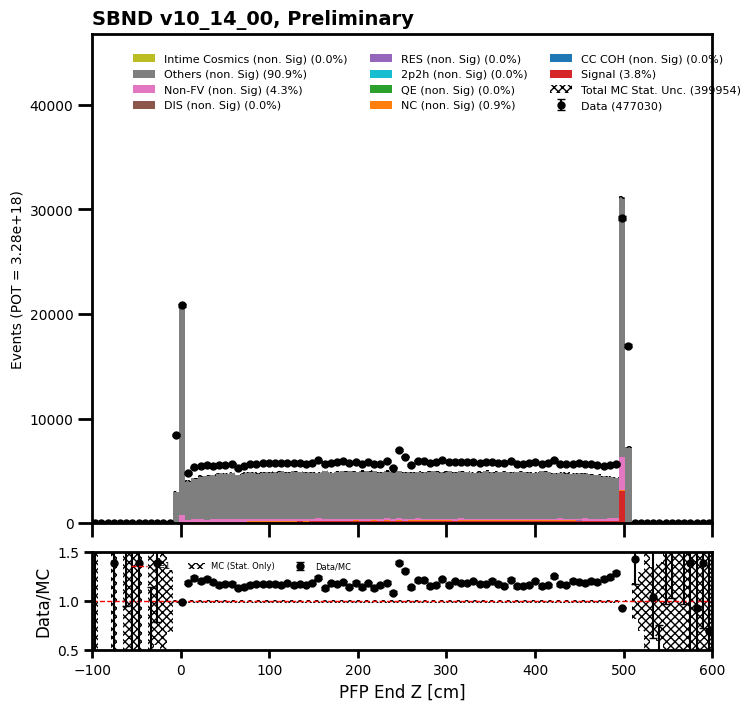

In [50]:
## PE Count > 2000

mc_bnb_cosmic_dfs["evt"] = mc_bnb_cosmic_dfs["evt"][mc_bnb_cosmic_dfs["evt"].pemask]
data_offbeam_light_dfs["evt"] = data_offbeam_light_dfs["evt"][data_offbeam_light_dfs["evt"].pemask]
data_bnb_light_dfs["evt"] = data_bnb_light_dfs["evt"][data_bnb_light_dfs["evt"].pemask]

draw_reco_valid_plots(mc_bnb_cosmic_dfs["evt"], data_offbeam_light_dfs["evt"], data_bnb_light_dfs["evt"], "a_a_b_pe_cut")

In [51]:
purity = 15377.4638671875/400027.9421391487
efficiency = 15377.4638671875/15446.276679992676
print("purity = ", round(purity*100,2), "% and efficiency = ", round(efficiency*100,2), "%")

purity =  3.84 % and efficiency =  99.55 %


/tmp/ipykernel_1484/3524794362.py:62: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  each_mc_hist_data = [np.histogram(data, bins=bins, weights=w)[0] for data, w in zip(all_mc_data, all_weights)]
/exp/sbnd/app/users/amoor/cafpyana/cafpyana/envs/venv_py39_cafpyana/lib/python3.9/site-packages/matplotlib/axes/_axes.py:6986: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  bins = np.histogram_bin_edges(
/exp/sbnd/app/users/amoor/cafpyana/cafpyana/envs/venv_py39_cafpyana/lib/python3.9/site-packages/matplotlib/axes/_axes.py:7001: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  m, bins = np.histogram(x[i], bins, weights=w[i], **hist_kwargs)
/tmp/ipykernel_1484/3524794362.py:92: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  hist_vals, _ = np.histogram(data, bins=bins, weights=w)
/tmp/ipykernel_1484/3524794362.py:93: RuntimeWarning

total_mc  [    0.        99467.1567502]
total data =  123361
[     0 123361]
[    0.        99467.1567502]
data ratio  [       nan 1.24021842]
mode sums =  [15071.3916015625, 4.300926685333252, 3554.6162109375, 96.05391693115234, 32.973777770996094, 87.45207977294922, 30.823314666748047, 16761.599609375, 63827.9453125, 0.0]
total sums =  99467.15675020218


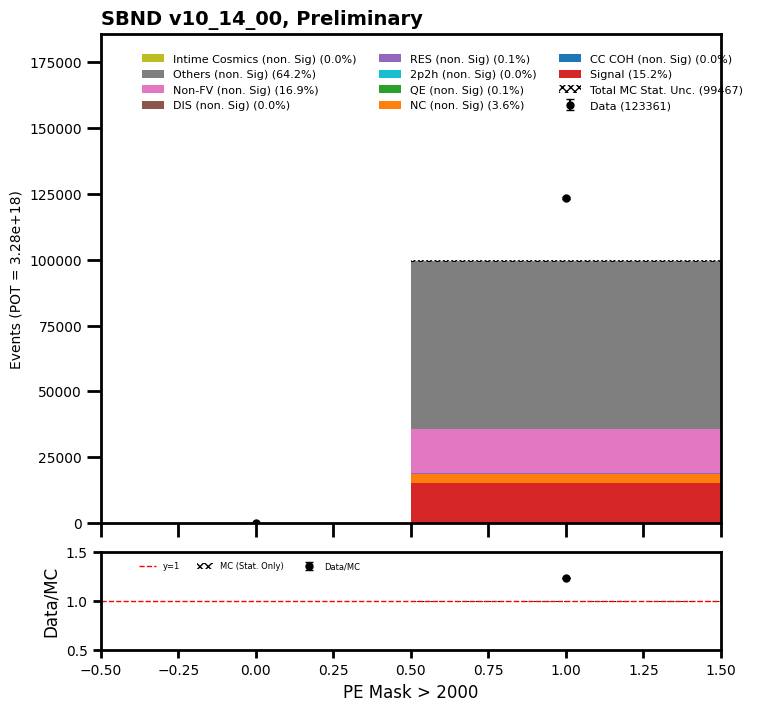

total_mc  [99467.16     0.  ]
total data =  123361
[123361      0]
[99467.16     0.  ]
data ratio  [1.24021843        nan]
mode sums =  [15071.3916015625, 4.300926685333252, 3554.6162109375, 96.05391693115234, 32.973777770996094, 87.45207977294922, 30.823314666748047, 16761.599609375, 63827.9453125, 0.0]
total sums =  99467.15675020218


/tmp/ipykernel_1484/3524794362.py:119: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = mc_stat_err / total_mc
/tmp/ipykernel_1484/3524794362.py:120: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = total_mc / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: invalid value encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:178: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = data_eylow / total_mc
/tmp/ipykernel_1484/3524794362.py:179: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc


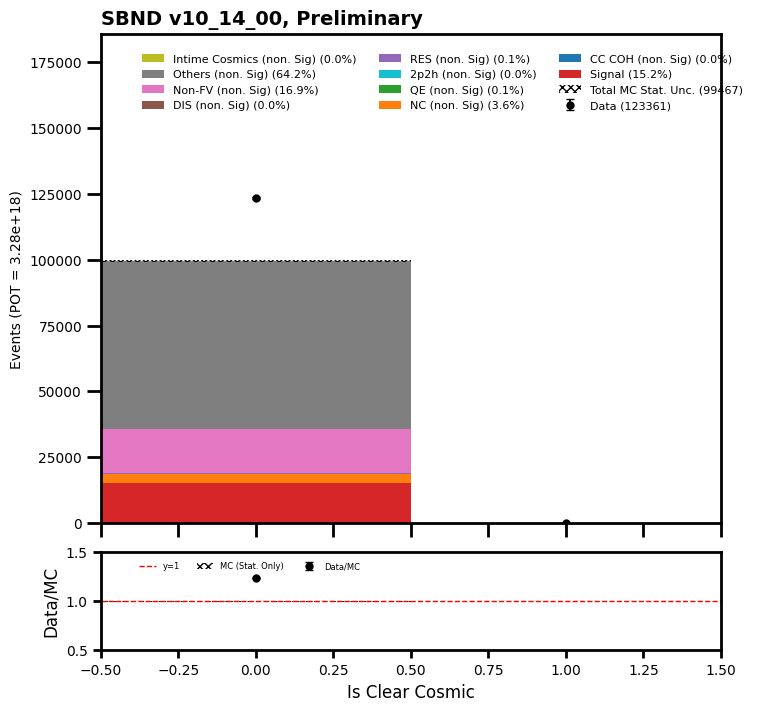

total_mc  [   0.        0.        0.        0.        0.        0.        0.
    0.        0.        0.        0.        0.        0.        0.
    0.        0.     2261.5452 1389.8799 1434.3206 1450.8088 1361.9188
 1470.8702 1491.6572 1510.294  1505.9928 1473.7368 1551.8667 1531.795
 1502.4062 1523.9104 1568.3517 1575.5198 1574.0862 1590.5724 1583.4045
 1537.5295 1591.2891 1531.0782 1503.1232 1551.8674 1435.0275 1502.4064
 1480.9005 1462.2657 1437.1798 1357.6134 1419.9727 1402.0549 1321.0568
 1595.5898 1605.625  1278.0508 1396.3185 1445.7794 1408.506  1448.6486
 1420.6897 1475.1681 1495.2405 1489.5021 1395.6038 1438.6135 1492.3712
 1414.8536 1437.7208 1444.0996 1526.7109 1476.51   1402.5588 1406.8889
 1422.7228 1391.7892 1413.3615 1467.211  1367.4122 1365.9827 1338.0078
 1364.5667 1279.1603 1264.7013 1279.8185 1236.7832 1185.7539 1708.5342
    0.        0.        0.        0.        0.        0.        0.
    0.        0.        0.        0.        0.        0.        0.
    0.       

/tmp/ipykernel_1484/3524794362.py:119: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = mc_stat_err / total_mc
/tmp/ipykernel_1484/3524794362.py:120: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = total_mc / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: invalid value encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:178: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = data_eylow / total_mc
/tmp/ipykernel_1484/3524794362.py:179: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc


total data =  123361
[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0 3160 1681 1800 1813 1807 1884 1918 1967 1859 2011 1971 1930
 1939 1938 1933 1968 1927 1980 1984 1939 1917 2000 1821 1934 1845 1891
 1843 1867 1799 1791 1743 1789 1532 1930 1770 1540 1609 1576 1689 1617
 1745 1811 1763 1779 1801 1806 1692 1756 1739 1744 1829 1688 1706 1884
 1753 1680 1719 1779 1716 1652 1682 1628 1593 1609 1568 1515 1442 2370
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0]
[   0.        0.        0.        0.        0.        0.        0.
    0.        0.        0.        0.        0.        0.        0.
    0.        0.     2261.5452 1389.8799 1434.3206 1450.8088 1361.9188
 1470.8702 1491.6572 1510.294  1505.9928 1473.7368 1551.8667 1531.795
 1502.4062 1523.9104 1568.3517 1575.5198 1574.0862 1590.5724 1583.4045
 1537.5295 1591.2891 1531.0782 1503.1232 1551.8674 1435.0275 1502.4064
 1480.9005 1462.2657 1437.1798 1357.6134 1419.9727 14

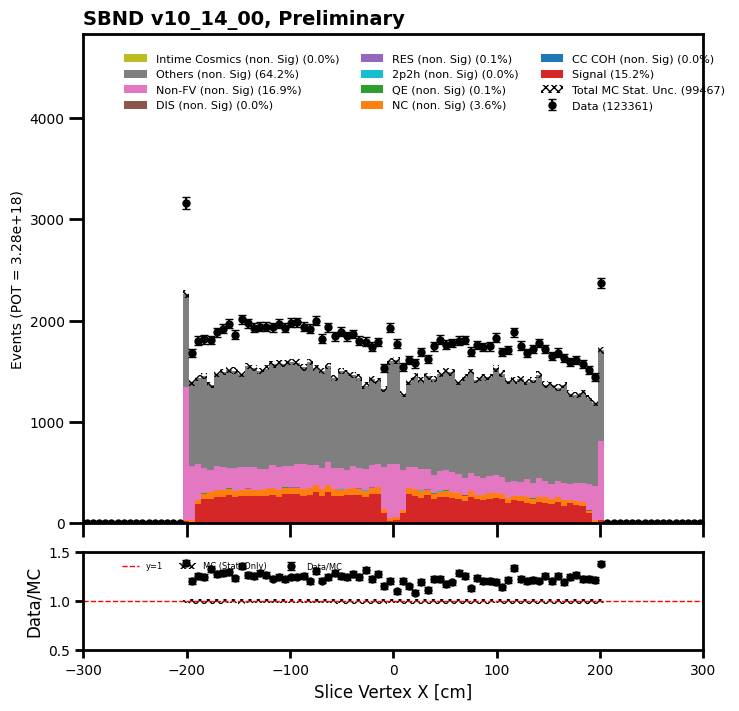

total_mc  [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 7.16821134e-01 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 7.16821134e-01 7.16821074e-01
 0.00000000e+00 7.16821134e-01 7.16821134e-01 1.51249115e+02
 4.78037598e+03 9.27536011e+02 9.54779846e+02 9.08190979e+02
 9.03171387e+02 9.28253845e+02 9.35421631e+02 9.34705627e+02
 9.67678467e+02 9.03165649e+02 9.13918213e+02 1.03362354e+03
 1.02143750e+03 9.82728577e+02 9.97781372e+02 1.03720520e+03
 9.69826233e+02 1.01068384e+03 1.01498456e+03 1.01928528e+03
 1.02932043e+03 1.06014258e+03 1.04580676e+03 1.07806262e+03
 1.07089465e+03 1.11390247e+03 1.03935571e+03 1.07161145e+03
 1.06802759e+03 1.10171692e+03 1.14257446e+03 1.12035376e+03
 1.09669946e+03 1.14400793e+03 1.15475989e+03 1.08451392e+03
 1.14185754e+03 1.10745142e+03 1.12967200e+03 1.13182446e+03
 1.17411340e+03 1.21066821e+03 1.16694751e+03 1.22428918e+03
 1.23360754e+03 1.20350208e+03 1.28450012e+03 1.26299426e+03
 1.24866028e+0

/tmp/ipykernel_1484/3524794362.py:119: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = mc_stat_err / total_mc
/tmp/ipykernel_1484/3524794362.py:120: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = total_mc / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: divide by zero encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: invalid value encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:178: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = data_eylow / total_mc
/tmp/ipykernel_1484/3524794362.py:179: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc
/exp/sbnd/app/users/amoor/cafpyana/cafpyana/envs/venv_py39_cafpyana/lib/python3.9/site-packages/matplotlib/axes/_axes.py:3749: RuntimeWarning: overflow encountered in add
  low, high = dep + np.vstack(

total data =  123359
[    0     0     0     0     0     0     0     0     1     1     0     0
     0     0     0    17  6784  1823  1230  1181  1144  1163  1133  1148
  1185  1105  1126  1082  1097  1115  1172  1161  1077  1130  1145  1173
  1216  1102  1162  1179  1166  1194  1225  1224  1193  1372  1261  1224
  1289  1440  1358  1334  1419  1348  1307  1291  1371  1291  1367  1438
  1373  1393  1409  1458  1483  1515  1464  1482  1563  1612  1685  1763
  1664  1800  1920  1915  2068  2197  2256  2422  2668  3128  3762 18822
   567     3     0     2     1     0     0     0     0     0     0     0
     0     0     0     0]
[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 7.16821134e-01 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 7.16821134e-01 7.16821074e-01
 0.00000000e+00 7.16821134e-01 7.16821134e-01 1.51249115e+02
 4.78037598e+03 9.27536011e+02 9.54779846e+02 9.08190979e+02
 9.03171387e+02 9.28253845e+02 9.35421631e+02 9.34705627e+02
 9.

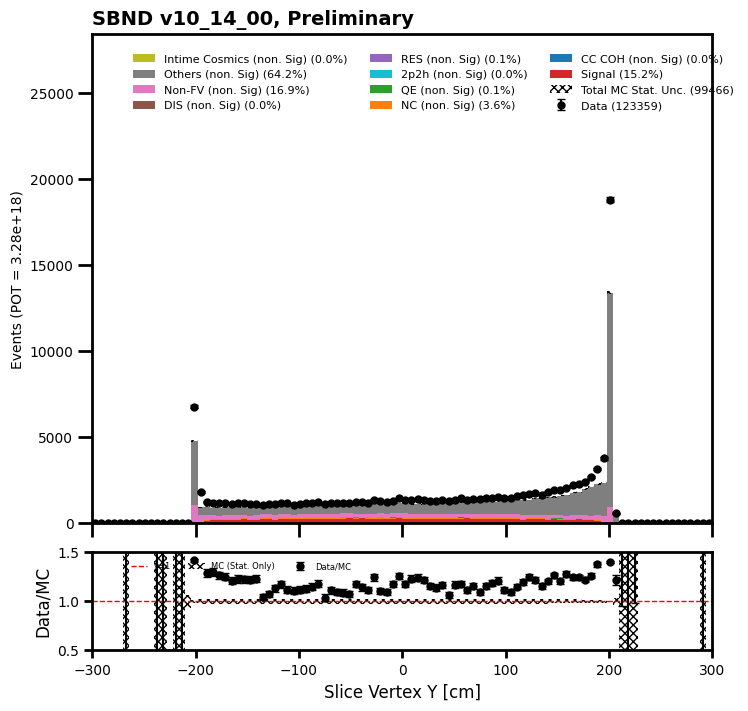

total_mc  [0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00 0.0000000e+00 0.0000000e+00 7.1682113e-01 7.1682113e-01
 0.0000000e+00 0.0000000e+00 0.0000000e+00 9.8777704e+02 1.3459328e+04
 1.5253472e+03 1.3640759e+03 1.3088798e+03 1.3239260e+03 1.2529629e+03
 1.2393439e+03 1.2379110e+03 1.0959843e+03 1.2149734e+03 1.1776995e+03
 1.1984854e+03 1.1827150e+03 1.2113870e+03 1.1440081e+03 1.1303889e+03
 1.1676624e+03 1.1647950e+03 1.2106721e+03 1.1662268e+03 1.1748322e+03
 1.0938322e+03 1.1905979e+03 1.1160529e+03 1.1898829e+03 1.1432913e+03
 1.1167698e+03 1.0809319e+03 1.1303868e+03 1.1146212e+03 1.1554766e+03
 1.1533245e+03 1.1189200e+03 1.1698146e+03 1.1913146e+03 1.1576271e+03
 1.1712462e+03 1.1905999e+03 1.1325392e+03 1.1690958e+03 1.2128223e+03
 1.1475919e+03 1.1791292e+03 1.1440081e+03 1.1311056e+03 1.1655138e+03
 1.1282365e+03 1.1647971e+03 1.1793848e+03 1.1763516e+03 1.2352170e+03
 1.1935959e+03 1.1965002e+03 1.1756525e+03 1.2251954e+03 1.1562736e

/tmp/ipykernel_1484/3524794362.py:119: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = mc_stat_err / total_mc
/tmp/ipykernel_1484/3524794362.py:120: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = total_mc / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: divide by zero encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: invalid value encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:178: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = data_eylow / total_mc
/tmp/ipykernel_1484/3524794362.py:179: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc
/exp/sbnd/app/users/amoor/cafpyana/cafpyana/envs/venv_py39_cafpyana/lib/python3.9/site-packages/matplotlib/axes/_axes.py:3749: RuntimeWarning: overflow encountered in add
  low, high = dep + np.vstack(

total data =  123361
[    0     0     0     0     0     0     0     0     0     0     0     2
     0  3456 15489  1965  1627  1503  1469  1415  1392  1431  1240  1313
  1273  1306  1337  1334  1296  1337  1342  1273  1377  1306  1308  1260
  1325  1314  1340  1379  1299  1326  1315  1319  1283  1395  1328  1434
  1286  1245  1623  1472  1503  1397  1368  1422  1360  1404  1400  1474
  1394  1406  1458  1421  1459  1451  1460  1439  1384  1428  1516  1514
  1517  1406  1599  1550  1540  1632  1653  1717  1668  1800  1858  2160
  2204  2288   376     1     0     0     0     0     0     0     0     0
     0     0     0     0]
[0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00 0.0000000e+00 0.0000000e+00 7.1682113e-01 7.1682113e-01
 0.0000000e+00 0.0000000e+00 0.0000000e+00 9.8777704e+02 1.3459328e+04
 1.5253472e+03 1.3640759e+03 1.3088798e+03 1.3239260e+03 1.2529629e+03
 1.2393439e+03 1.2379110e+03 1.0959843e+03 1.2149734e+03 1.1776995e+03
 1.1984854e+03

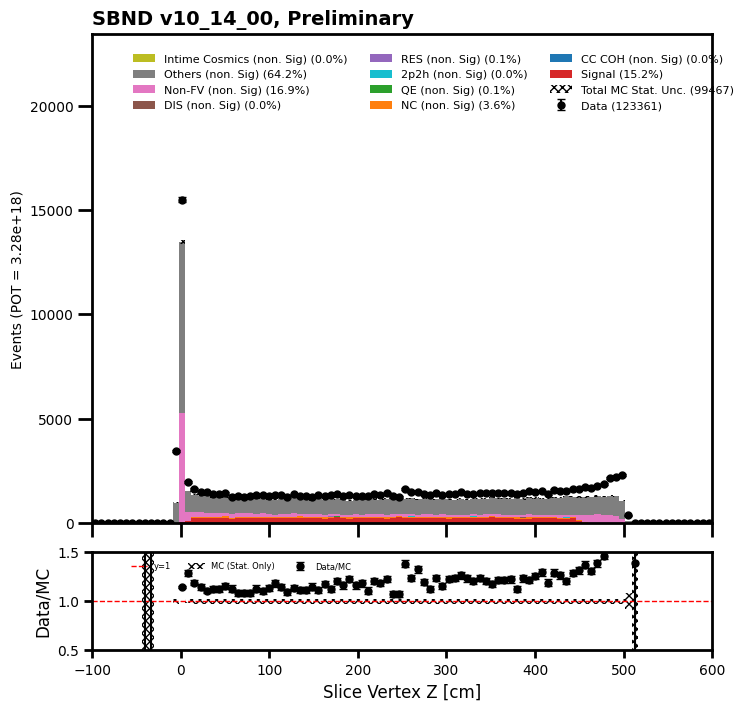

total_mc  [6274.2056  9883.216   5705.703   4990.34    4639.826   4345.2246
 4052.7678  3736.6646  3604.0552  3383.998   3166.8088  2970.4048
 2779.7388  2664.3364  2513.8052  2401.2698  2253.6096  2173.3228
 1914.9105  1858.8733  1726.0569  1620.6544  1439.0216  1428.3517
 1297.713   1252.4337  1141.9357  1095.4004  1002.12317  943.13293
  904.4299   788.922    785.33606  769.4962   710.67786  670.5079
  636.7969   587.19336  556.3575   475.9356 ]
total data =  118055
[ 6988 11120  7141  6432  5970  5521  5213  4796  4533  4325  4115  3796
  3521  3355  3102  2913  2729  2598  2252  2320  2175  2063  1821  1818
  1746  1576  1517  1431  1312  1157  1146  1134   946   905   936   855
   742   718   685   632]
[6274.2056  9883.216   5705.703   4990.34    4639.826   4345.2246
 4052.7678  3736.6646  3604.0552  3383.998   3166.8088  2970.4048
 2779.7388  2664.3364  2513.8052  2401.2698  2253.6096  2173.3228
 1914.9105  1858.8733  1726.0569  1620.6544  1439.0216  1428.3517
 1297.713   1252.

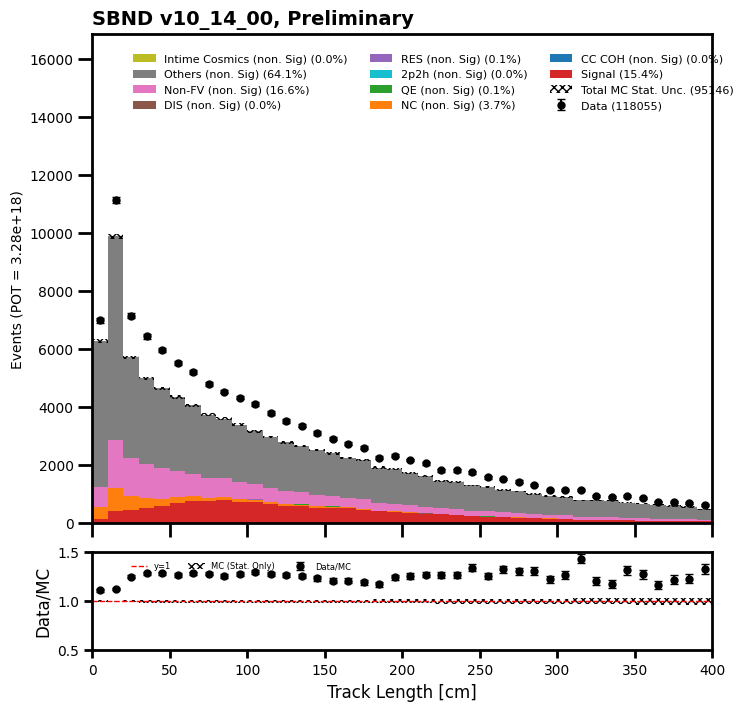

total_mc  [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 7.16821134e-01 1.43364191e+00 1.07523155e+01 1.93541775e+01
 5.23279037e+01 8.31511917e+01 1.35479263e+02 1.99993622e+02
 3.55543823e+02 5.18982544e+02 7.03914307e+02 9.98523926e+02
 1.33611743e+03 1.79414282e+03 2.48728516e+03 2.69587329e+03
 2.29088281e+03 2.10738281e+03 2.48083398e+03 3.28364648e+03
 4.11369727e+03 4.41045117e+03 4.60685352e+03 4.54592578e+03
 4.44414062e+03 4.51510547e+03 4.74591211e+03 4.92295898e+03
 5.10718018e+03 5.43332031e+03 5.28576367e+03 5.26867822e+03
 5.17541797e+03 5.15034570e+03 4.82452588e+03 3.78632349e+03
 1.47876562e+03 7.39453125e+01 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00]
total data =  123333
[   0    0    0    0    0    0    0    0    0    0   14   33   57   96
  165  240  365  474  688  957 1360 2010 2927 3275 3143 3134 3793 4748
 5529 5587 5697 5716 5652 5747 5815 6243 6440 6708 6381 6483 61

/tmp/ipykernel_1484/3524794362.py:119: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = mc_stat_err / total_mc
/tmp/ipykernel_1484/3524794362.py:120: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = total_mc / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: invalid value encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:178: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = data_eylow / total_mc
/tmp/ipykernel_1484/3524794362.py:179: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc


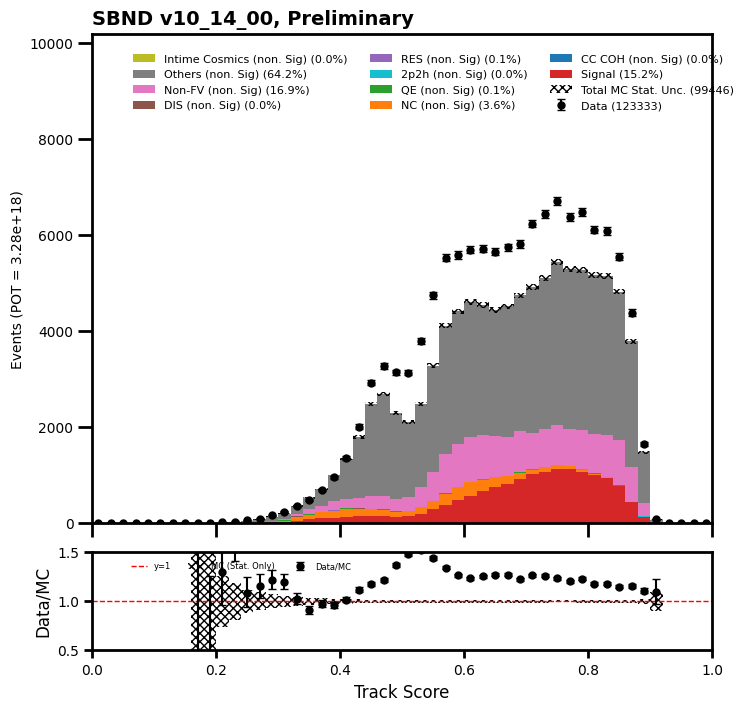

total_mc  [2.1353979e+03 4.7875132e+03 4.6620488e+03 3.6477822e+03 3.1467417e+03
 3.2478101e+03 4.1681768e+03 5.7738013e+03 7.6338867e+03 8.7406230e+03
 8.2531973e+03 6.3450884e+03 4.4434243e+03 3.2896936e+03 2.5610293e+03
 2.0752327e+03 1.7415569e+03 1.4902834e+03 1.3078497e+03 1.1557482e+03
 1.0552307e+03 9.8626776e+02 8.6780676e+02 8.4840845e+02 7.9243958e+02
 7.1634198e+02 7.0417969e+02 6.7116028e+02 6.9764075e+02 6.0509790e+02
 5.4627161e+02 5.5844733e+02 5.6059192e+02 5.3400006e+02 5.5051575e+02
 5.4326965e+02 5.3465833e+02 5.6897656e+02 5.8470715e+02 6.3416608e+02
 6.5709192e+02 6.8217975e+02 6.4557422e+02 4.9142194e+02 4.1610947e+02
 3.5876276e+02 2.7983405e+02 2.3894730e+02 2.1600586e+02 1.7729102e+02
 1.3562305e+02 1.1985354e+02 9.2574219e+01 9.0439453e+01 8.0388695e+01
 6.8894531e+01 5.3839844e+01 5.5980469e+01 4.6664062e+01 3.2291016e+01
 4.3070312e+01 2.7277344e+01 2.0808594e+01 2.7279297e+01 1.5076172e+01
 2.0105469e+01 2.1529297e+01 1.1482422e+01 1.2917969e+01 1.5068359e

/tmp/ipykernel_1484/3524794362.py:119: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = mc_stat_err / total_mc
/tmp/ipykernel_1484/3524794362.py:120: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = total_mc / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: invalid value encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:178: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = data_eylow / total_mc
/tmp/ipykernel_1484/3524794362.py:179: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc


total data =  123337
[ 2470  4373  5256  4069  3594  4259  5833  8752 11367 11402  9397  7112
  5276  4124  3375  2706  2316  1986  1811  1589  1436  1279  1232  1124
  1096   976   964   933   876   815   793   703   672   695   651   589
   656   608   606   636   568   588   526   456   374   306   262   219
   208   165   150   119    91   109    75    84    66    56    50    45
    42    36    37    29    18    25    20    28    20    12    19    10
    10    11    13     3     7     8     6     3     8     2     3     2
     7     7     1     4     2     3     4     2     1     1     4     0
     1     2     2     0]
[2.1353979e+03 4.7875132e+03 4.6620488e+03 3.6477822e+03 3.1467417e+03
 3.2478101e+03 4.1681768e+03 5.7738013e+03 7.6338867e+03 8.7406230e+03
 8.2531973e+03 6.3450884e+03 4.4434243e+03 3.2896936e+03 2.5610293e+03
 2.0752327e+03 1.7415569e+03 1.4902834e+03 1.3078497e+03 1.1557482e+03
 1.0552307e+03 9.8626776e+02 8.6780676e+02 8.4840845e+02 7.9243958e+02
 7.1634198e+02

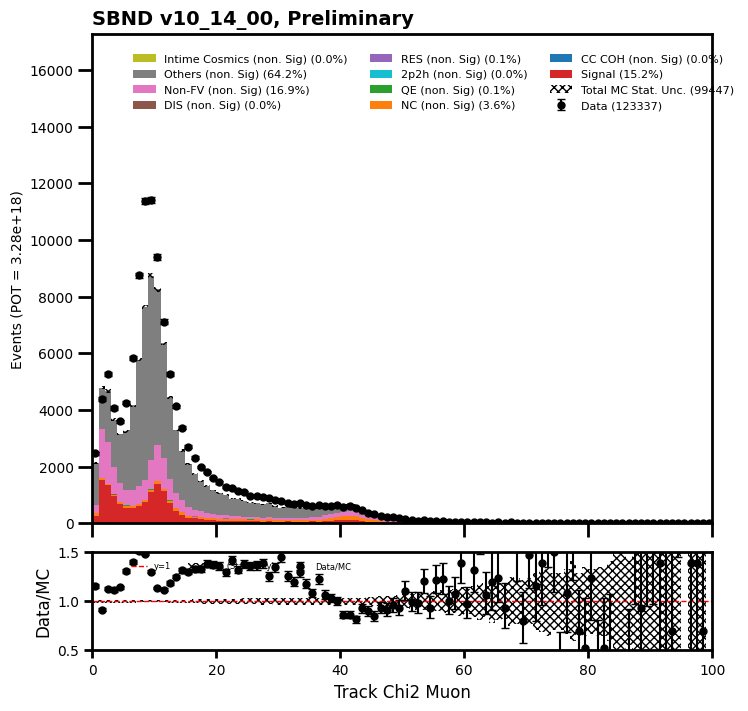

total_mc  [1872.3257   1292.4272   1031.4769    416.46017   245.14517   178.48267
  144.79297   129.02344   103.93555    95.333984   93.90039    73.11328
   80.28125    70.24609    74.546875   59.49414    73.8301     53.759766
   60.210938   58.060547   50.175804   43.007812   66.66213    38.70703
   60.210938   56.626976   63.79492    50.17578    66.66211    64.51172
   59.49414    53.759766   63.79492    75.26367    74.546875   62.36133
   68.81252    66.66211    53.04297    77.41406    88.166016   75.26367
   80.28127    80.99805    88.166016   81.71484    60.210938   64.51174
   70.24612    66.66211    60.927734   65.22854    51.609375   45.158226
   60.927734   58.060547   41.57422    44.441406   60.210938   59.49414
   53.75979    52.32617    55.19336    45.158203   42.291016   57.34375
   51.609398   60.210938   48.02539    55.193382   46.591797   58.060596
   44.441406   48.02539    59.49414    58.777344   70.24609    64.51172
   63.79492    60.927734   68.8125     65.228516   

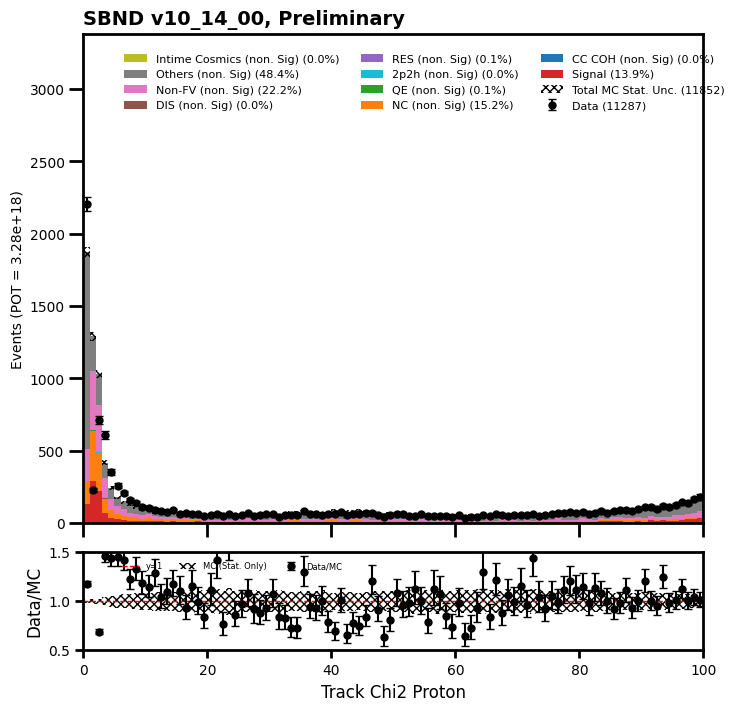

total_mc  [5.4809031e+04 9.4233418e+03 5.7370830e+03 3.4415735e+03 2.2472817e+03
 1.6272173e+03 1.1462288e+03 8.4082843e+02 6.4729907e+02 4.7741235e+02
 4.1289661e+02 3.1755490e+02 2.7525787e+02 2.1361726e+02 1.9855865e+02
 1.6057233e+02 1.4839062e+02 1.3476566e+02 1.0896094e+02 9.0319336e+01
 8.2439499e+01 7.7412109e+01 6.0212914e+01 5.0175781e+01 5.0894577e+01
 4.5158203e+01 5.2326218e+01 3.8707031e+01 3.7992233e+01 2.4375000e+01
 3.0826172e+01 2.9392578e+01 2.0789062e+01 2.5089867e+01 2.1503906e+01
 1.7919922e+01 2.0070312e+01 1.2185570e+01 1.7919922e+01 1.2185547e+01]
total data =  109885
[77953  7785  5750  3817  2679  1953  1637  1227   949   784   681   548
   480   424   384   298   248   223   206   186   179   158   163   110
   115   103    87    71    87    75    81    66    67    58    45    46
    46    38    36    42]
[5.4809031e+04 9.4233418e+03 5.7370830e+03 3.4415735e+03 2.2472817e+03
 1.6272173e+03 1.1462288e+03 8.4082843e+02 6.4729907e+02 4.7741235e+02
 4.1289661e+0

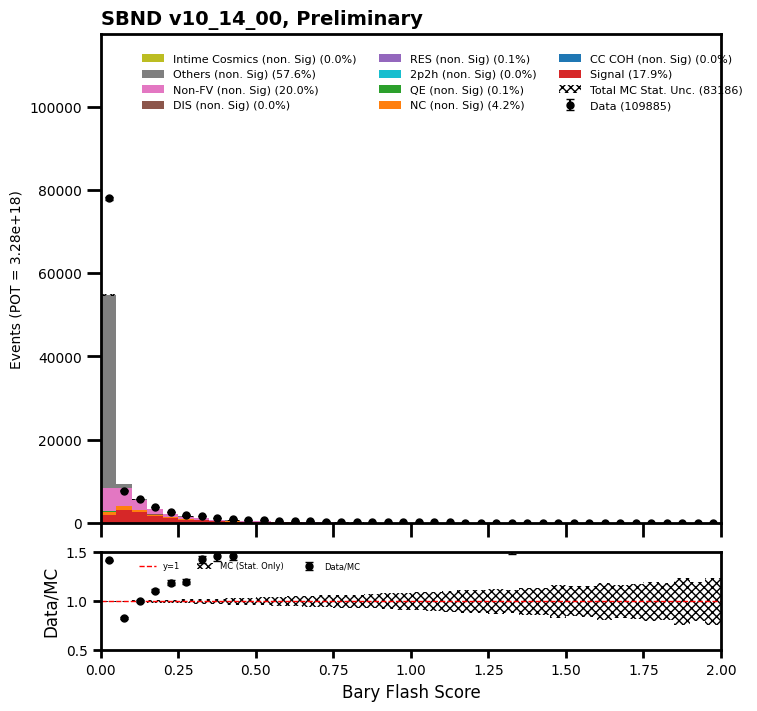

total_mc  [7.1682113e-01 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 7.1682107e-01 0.0000000e+00 0.0000000e+00 0.0000000e+00 2.1504636e+00
 2.8672845e+00 2.1504636e+00 1.4336424e+00 1.1254083e+02 1.9110327e+03
 1.1167794e+03 1.1999203e+03 1.1855847e+03 1.1777004e+03 1.2049392e+03
 1.2407800e+03 1.2070908e+03 1.3303796e+03 1.0873822e+03 1.1246562e+03
 1.1855839e+03 1.1726816e+03 1.2156901e+03 1.1705308e+03 1.2149707e+03
 1.1834316e+03 1.2135374e+03 1.1805645e+03 1.1633613e+03 1.1497423e+03
 1.1526095e+03 1.1748301e+03 1.1504590e+03 1.1461582e+03 1.1518926e+03
 1.1497423e+03 1.1060198e+03 1.1189200e+03 1.1332560e+03 1.1569082e+03
 1.1590607e+03 1.1318223e+03 1.1447269e+03 1.1354045e+03 1.2293068e+03
 1.0185685e+03 1.0995665e+03 1.1547599e+03 1.1475918e+03 1.1640782e+03
 1.1275215e+03 1.1253732e+03 1.1640764e+03 1.0744806e+03 1.1282363e+03
 1.1404240e+03 1.0673126e+03 1.1289532e+03 1.1468771e+03 1.1060157e+03
 1.1031525e+03 1.1139005e+03 1.1203556e+03 1.1533243e+03 1.1425764e

/tmp/ipykernel_1484/3524794362.py:119: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = mc_stat_err / total_mc
/tmp/ipykernel_1484/3524794362.py:120: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = total_mc / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: divide by zero encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: invalid value encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:178: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = data_eylow / total_mc
/tmp/ipykernel_1484/3524794362.py:179: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc
/exp/sbnd/app/users/amoor/cafpyana/cafpyana/envs/venv_py39_cafpyana/lib/python3.9/site-packages/matplotlib/axes/_axes.py:3749: RuntimeWarning: overflow encountered in add
  low, high = dep + np.vstack(

total data =  123350
[    0     0     0     1     2     1     0     1     0     0     3     2
     8   525  3155  1526  1653  1477  1514  1401  1366  1402  1533  1200
  1307  1371  1335  1349  1383  1415  1329  1378  1352  1381  1263  1345
  1355  1277  1340  1375  1314  1285  1343  1302  1288  1282  1288  1386
  1264  1785  1469  1494  1440  1347  1340  1395  1421  1339  1366  1341
  1378  1352  1385  1386  1352  1357  1363  1415  1323  1250  1301  1330
  1292  1384  1394  1348  1346  1423  1390  1350  1406  1423  1461  1678
  2145 14790  7442    23    15     9     5     1     3     2     4     3
     2     2     3     0]
[7.1682113e-01 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 7.1682107e-01 0.0000000e+00 0.0000000e+00 0.0000000e+00 2.1504636e+00
 2.8672845e+00 2.1504636e+00 1.4336424e+00 1.1254083e+02 1.9110327e+03
 1.1167794e+03 1.1999203e+03 1.1855847e+03 1.1777004e+03 1.2049392e+03
 1.2407800e+03 1.2070908e+03 1.3303796e+03 1.0873822e+03 1.1246562e+03
 1.1855839e+03

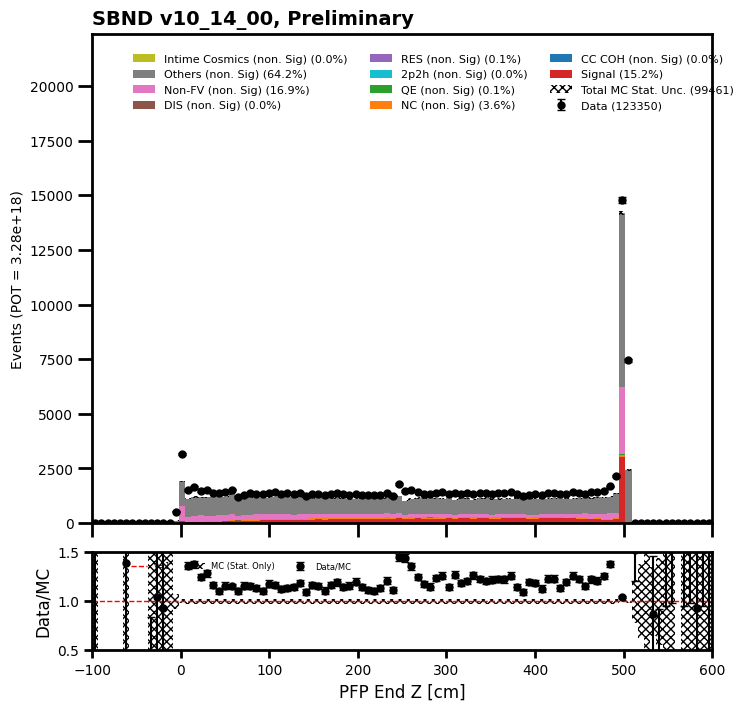

In [52]:
#Clear cosmic

mc_bnb_cosmic_dfs["evt"] = mc_bnb_cosmic_dfs["evt"][mc_bnb_cosmic_dfs["evt"].slc.is_clear_cosmic == 0]
data_offbeam_light_dfs["evt"] = data_offbeam_light_dfs["evt"][data_offbeam_light_dfs["evt"].slc.is_clear_cosmic == 0]
data_bnb_light_dfs["evt"] = data_bnb_light_dfs["evt"][data_bnb_light_dfs["evt"].slc.is_clear_cosmic == 0]


draw_reco_valid_plots(mc_bnb_cosmic_dfs["evt"], data_offbeam_light_dfs["evt"], data_bnb_light_dfs["evt"], "a_vtx_fv_and_not_clear_cosmic")

In [53]:
purity = 15071.3916015625/99467.15675020218
efficiency = 15071.3916015625/15446.276679992676
print("purity = ", round(purity*100,2), "% and efficiency = ", round(efficiency*100,2), "%")

purity =  15.15 % and efficiency =  97.57 %


/tmp/ipykernel_1484/3524794362.py:62: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  each_mc_hist_data = [np.histogram(data, bins=bins, weights=w)[0] for data, w in zip(all_mc_data, all_weights)]
/exp/sbnd/app/users/amoor/cafpyana/cafpyana/envs/venv_py39_cafpyana/lib/python3.9/site-packages/matplotlib/axes/_axes.py:6986: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  bins = np.histogram_bin_edges(
/exp/sbnd/app/users/amoor/cafpyana/cafpyana/envs/venv_py39_cafpyana/lib/python3.9/site-packages/matplotlib/axes/_axes.py:7001: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  m, bins = np.histogram(x[i], bins, weights=w[i], **hist_kwargs)
/tmp/ipykernel_1484/3524794362.py:92: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  hist_vals, _ = np.histogram(data, bins=bins, weights=w)
/tmp/ipykernel_1484/3524794362.py:93: RuntimeWarning

total_mc  [    0.         47040.60281038]
total data =  52623
[    0 52623]
[    0.         47040.60281038]
data ratio  [       nan 1.11867189]
mode sums =  [14625.5439453125, 4.300926685333252, 3270.7646484375, 91.75299835205078, 32.2569580078125, 85.30162048339844, 30.823314666748047, 2336.7783203125, 26563.080078125, 0.0]
total sums =  47040.60281038284


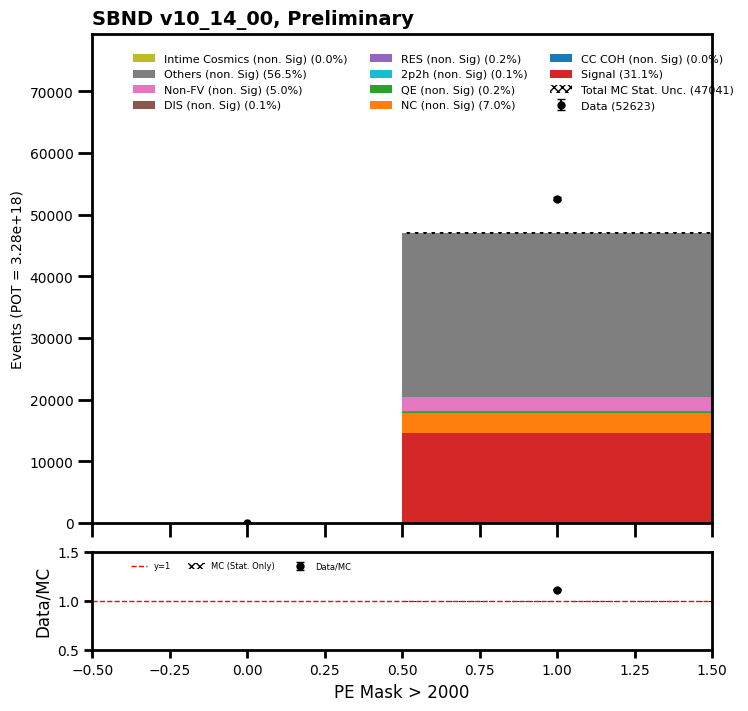

total_mc  [47040.6     0. ]
total data =  52623
[52623     0]
[47040.6     0. ]
data ratio  [1.11867192        nan]
mode sums =  [14625.5439453125, 4.300926685333252, 3270.7646484375, 91.75299835205078, 32.2569580078125, 85.30162048339844, 30.823314666748047, 2336.7783203125, 26563.080078125, 0.0]
total sums =  47040.60281038284


/tmp/ipykernel_1484/3524794362.py:119: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = mc_stat_err / total_mc
/tmp/ipykernel_1484/3524794362.py:120: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = total_mc / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: invalid value encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:178: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = data_eylow / total_mc
/tmp/ipykernel_1484/3524794362.py:179: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc


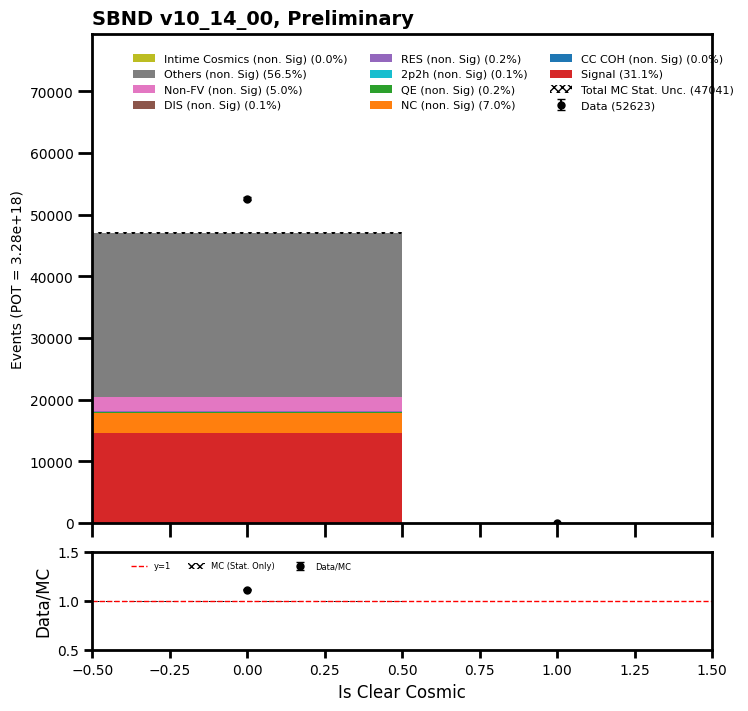

total_mc  [  0.        0.        0.        0.        0.        0.        0.
   0.        0.        0.        0.        0.        0.        0.
   0.        0.        0.        0.      589.2286  871.6482  812.14026
 901.736   860.1616  892.4169  832.9219  807.11743 861.5946  845.82135
 835.78516 832.9182  862.30676 827.1838  882.3772  860.87317 845.8205
 784.176   840.8028  840.80286 762.672   823.59985 744.7521  770.55676
 781.3087  769.83997 751.20325 675.9396  733.28326 745.469   222.92387
   0.        0.      210.73828 725.39856 728.26575 730.41614 732.5665
 719.66425 723.24817 785.6096  756.2218  723.2482  731.13306 770.55676
 739.0177  768.4064  754.0704  813.5645  770.5568  751.2033  754.7873
 787.7599  766.9728  787.7599  788.4767  784.1759  763.3889  749.7696
 751.2033  745.4689  731.13293 738.3009  488.1387    0.        0.
   0.        0.        0.        0.        0.        0.        0.
   0.        0.        0.        0.        0.        0.        0.
   0.        0.     ]


/tmp/ipykernel_1484/3524794362.py:119: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = mc_stat_err / total_mc
/tmp/ipykernel_1484/3524794362.py:120: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = total_mc / total_mc


total data =  52623
[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0  667  957  969  982 1020 1039  953 1046  992  974
  997  967  966  953  944 1004  966  894  905  990  882  906  934  868
  837  883  834  802  809  799  220    0    0  245  734  678  786  754
  758  789  807  840  847  817  757  837  838  872  815  826  849  918
  838  836  835  893  880  848  880  812  845  851  827  552    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0]
[  0.        0.        0.        0.        0.        0.        0.
   0.        0.        0.        0.        0.        0.        0.
   0.        0.        0.        0.      589.2286  871.6482  812.14026
 901.736   860.1616  892.4169  832.9219  807.11743 861.5946  845.82135
 835.78516 832.9182  862.30676 827.1838  882.3772  860.87317 845.8205
 784.176   840.8028  840.80286 762.672   823.59985 744.7521  770.55676
 781.3087  769.83997 751.20325 675.9396  733.28326 745.4

/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: invalid value encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:178: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = data_eylow / total_mc
/tmp/ipykernel_1484/3524794362.py:179: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc


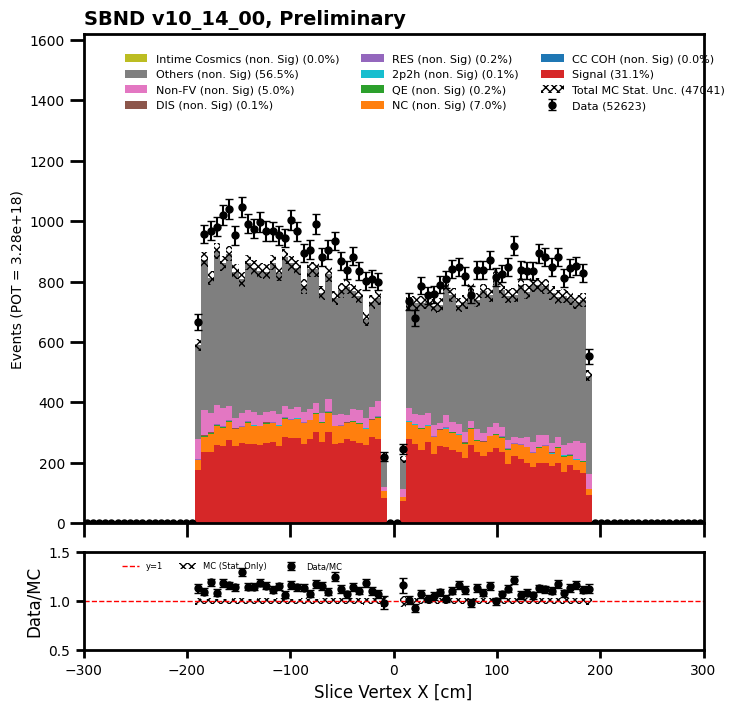

total_mc  [   0.         0.         0.         0.         0.         0.
    0.         0.         0.         0.         0.         0.
    0.         0.         0.         0.         0.         0.
  376.33112  557.69055  541.9133   566.99054  577.7423   548.3539
  609.9988   516.81335  541.1851   637.2362   574.87445  584.1918
  594.2249   625.7638   559.81836  602.8264   595.6584   623.6134
  604.2599   618.5957   635.08215  624.3302   653.0021   675.9396
  634.3655   661.60364  648.70135  675.2228   681.6741   668.7717
  672.3557   694.5763   680.95715  647.98456  685.97473  668.7717
  688.8419   683.82446  696.0099   728.98267  723.9651   741.1681
  785.6095   734.0001   775.57434  784.1759   756.2208   776.2911
  821.44934  842.2366   852.27264  839.36926  832.9181   936.8536
  931.1193   928.25214  969.1096  1040.0725  1057.9923  1131.1056
 1199.918   1293.1018  1420.6915  1002.08203    0.         0.
    0.         0.         0.         0.         0.         0.
    0.         0.   

/tmp/ipykernel_1484/3524794362.py:119: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = mc_stat_err / total_mc
/tmp/ipykernel_1484/3524794362.py:120: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = total_mc / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: invalid value encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:178: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = data_eylow / total_mc
/tmp/ipykernel_1484/3524794362.py:179: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc


total data =  52623
[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0  454  681  639  623  662  640  687  591  637  608
  627  632  647  673  599  616  687  650  710  678  708  662  667  677
  711  680  708  729  725  708  786  745  715  790  777  775  780  753
  739  761  838  869  827  806  867  878  915  889  922  873  948  974
 1001 1074  996 1105 1176 1184 1227 1290 1336 1428 1629 1234    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0]
[   0.         0.         0.         0.         0.         0.
    0.         0.         0.         0.         0.         0.
    0.         0.         0.         0.         0.         0.
  376.33112  557.69055  541.9133   566.99054  577.7423   548.3539
  609.9988   516.81335  541.1851   637.2362   574.87445  584.1918
  594.2249   625.7638   559.81836  602.8264   595.6584   623.6134
  604.2599   618.5957   635.08215  624.3302   653.0021   675.9396
  634.3655   661.6036

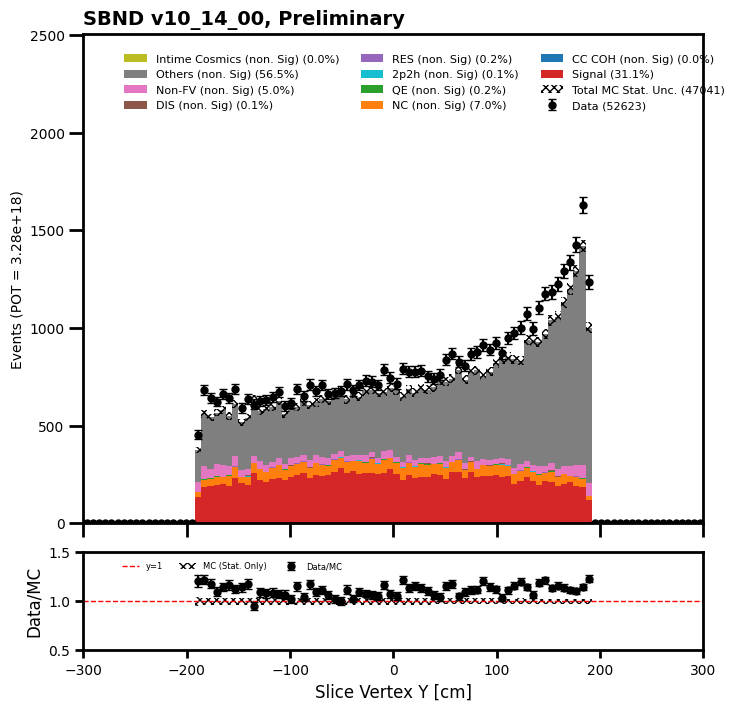

total_mc  [  0.        0.        0.        0.        0.        0.        0.
   0.        0.        0.        0.        0.        0.        0.
   0.      280.27698 894.5938  883.1097  851.5603  807.1195  823.6018
 807.83264 726.8338  766.9752  767.69165 794.92993 771.9917  769.1232
 736.86743 718.94745 749.7697  746.90247 767.6897  735.4338  734.0001
 713.9298  783.4592  693.8595  740.4513  729.6994  687.4084  679.5236
 726.83215 709.629   749.7696  725.3986  703.17786 726.83215 740.4513
 736.1505  739.0177  752.6369  718.2306  751.92004 731.8506  713.213
 732.56665 708.91235 690.9923  690.9923  700.31067 731.13306 727.5489
 748.336   775.5744  726.1154  745.46893 708.19543 741.1681  701.02747
 740.4515  747.6192  728.26575 735.4337  758.3712  753.3536  797.79504
 795.6446  466.6349    0.        0.        0.        0.        0.
   0.        0.        0.        0.        0.        0.        0.
   0.        0.        0.        0.        0.        0.        0.
   0.        0.     ]


/tmp/ipykernel_1484/3524794362.py:119: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = mc_stat_err / total_mc
/tmp/ipykernel_1484/3524794362.py:120: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = total_mc / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: invalid value encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:178: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = data_eylow / total_mc
/tmp/ipykernel_1484/3524794362.py:179: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc


total data =  52623
[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0  311 1060  938  938  869  851  893  771  807  801  826  839  795
  800  795  846  781  825  768  806  778  754  810  777  822  797  774
  752  783  733  846  792  842  829  796  893  888  874  809  819  869
  787  835  817  879  825  812  852  828  855  827  896  849  820  808
  902  857  872  814  940  898  867  920  506    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0]
[  0.        0.        0.        0.        0.        0.        0.
   0.        0.        0.        0.        0.        0.        0.
   0.      280.27698 894.5938  883.1097  851.5603  807.1195  823.6018
 807.83264 726.8338  766.9752  767.69165 794.92993 771.9917  769.1232
 736.86743 718.94745 749.7697  746.90247 767.6897  735.4338  734.0001
 713.9298  783.4592  693.8595  740.4513  729.6994  687.4084  679.5236
 726.83215 709.629   749.7696  725.3986  703.17786 726.8321

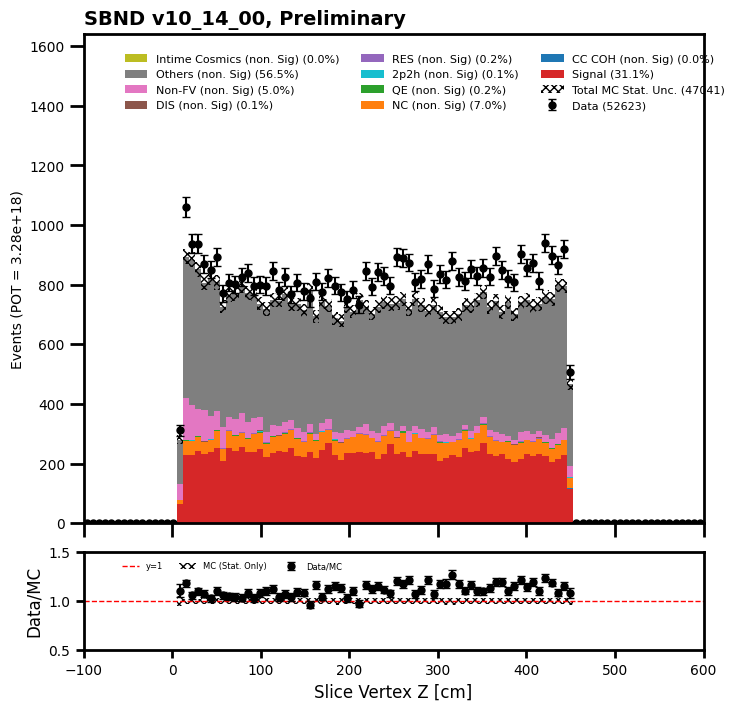

total_mc  [3627.0376  4919.4126  2607.7085  2303.7852  2126.7366  2053.623
 1982.6604  1841.4515  1819.2308  1705.2598  1632.8635  1500.2563
 1400.6226  1356.18    1250.8109  1157.6272  1144.7249  1075.9125
  924.66833  870.9085   820.7326   765.5392   687.4083   679.52356
  564.83606  545.48254  502.47476  475.2364   457.31653  409.29114
  389.93768  345.49622  313.95715  339.76187  291.01965  256.61334
  248.01172  225.79105  205.72076  174.89848]
total data =  51399
[3858 4876 2751 2545 2338 2322 2314 2141 1983 1946 1826 1815 1624 1569
 1397 1377 1272 1202 1010 1045  923  896  778  775  761  662  624  597
  536  484  431  427  368  315  342  332  263  256  200  218]
[3627.0376  4919.4126  2607.7085  2303.7852  2126.7366  2053.623
 1982.6604  1841.4515  1819.2308  1705.2598  1632.8635  1500.2563
 1400.6226  1356.18    1250.8109  1157.6272  1144.7249  1075.9125
  924.66833  870.9085   820.7326   765.5392   687.4083   679.52356
  564.83606  545.48254  502.47476  475.2364   457.31653  4

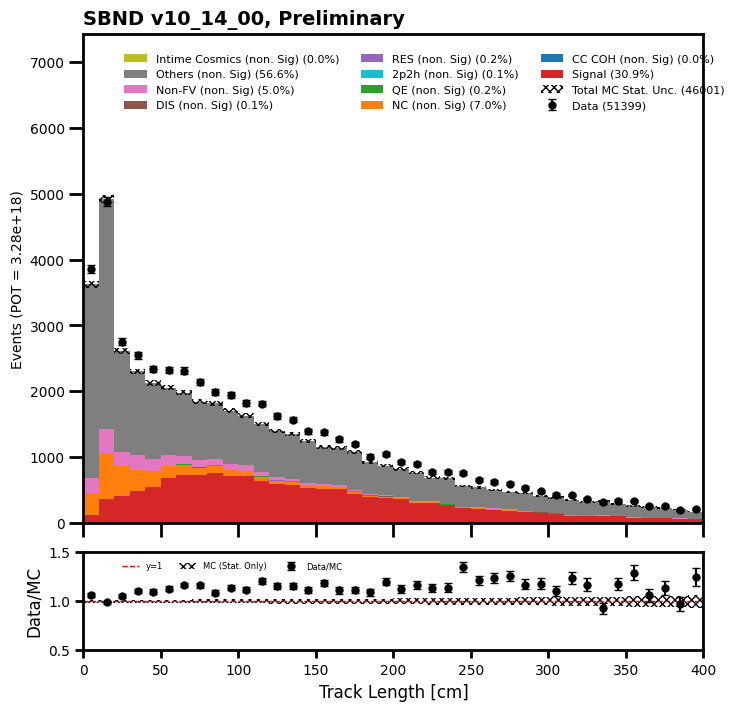

total_mc  [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 7.16821134e-01 0.00000000e+00 5.73456764e+00 1.29027805e+01
 2.86728477e+01 5.73456345e+01 8.17175369e+01 1.16125114e+02
 2.28666412e+02 3.14686768e+02 4.10024963e+02 5.92086243e+02
 7.87052002e+02 1.06157886e+03 1.47158789e+03 1.56548816e+03
 1.31747620e+03 1.11677197e+03 1.19848438e+03 1.54111340e+03
 1.85076965e+03 1.98122656e+03 2.08014453e+03 2.11741821e+03
 2.14393945e+03 2.21060181e+03 2.29876782e+03 2.37761646e+03
 2.47294971e+03 2.57688501e+03 2.53889453e+03 2.35181104e+03
 2.27081274e+03 2.12386938e+03 1.90094580e+03 1.33826001e+03
 4.59466858e+02 2.43710938e+01 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00]
total data =  52611
[   0    0    0    0    0    0    0    0    0    0    8   18   36   56
   95  140  193  265  406  556  777 1146 1593 1746 1496 1365 1495 1822
 2210 2246 2409 2465 2454 2536 2576 2703 2857 2867 2655 2576 246

/tmp/ipykernel_1484/3524794362.py:119: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = mc_stat_err / total_mc
/tmp/ipykernel_1484/3524794362.py:120: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = total_mc / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: invalid value encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:178: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = data_eylow / total_mc
/tmp/ipykernel_1484/3524794362.py:179: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc


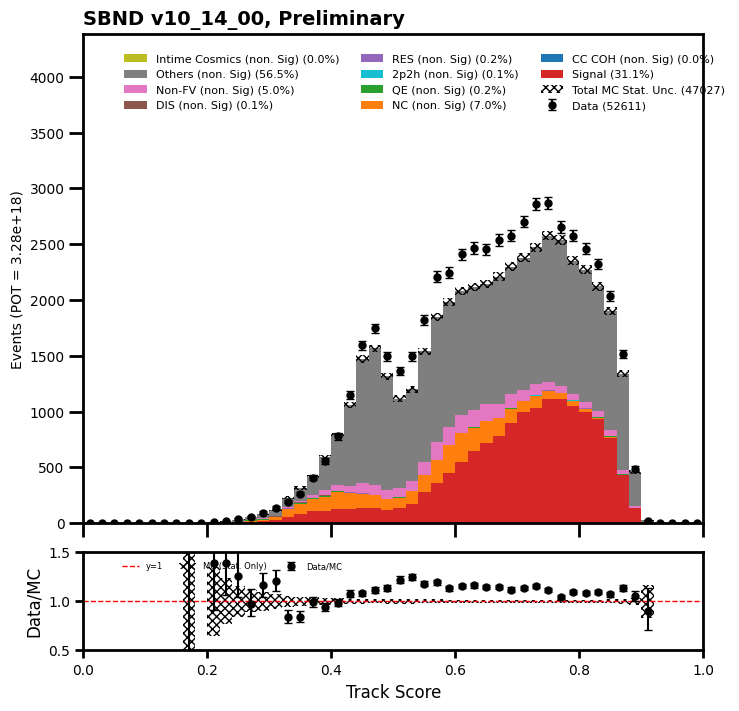

total_mc  [1.15120996e+03 1.95328564e+03 1.84288831e+03 1.49882715e+03
 1.42141418e+03 1.55832324e+03 2.06581592e+03 2.79264600e+03
 3.51087256e+03 3.88718994e+03 3.67573486e+03 2.75966846e+03
 1.92675146e+03 1.42857642e+03 1.14687512e+03 9.38287231e+02
 8.24316650e+02 7.49769836e+02 6.53002075e+02 5.65552856e+02
 5.44765869e+02 5.26129089e+02 4.46564545e+02 4.42263916e+02
 4.17892670e+02 3.83486511e+02 3.65566406e+02 3.49796997e+02
 3.83486450e+02 3.21125275e+02 2.98904358e+02 2.91736389e+02
 3.01054840e+02 2.84568420e+02 2.94603638e+02 2.96037201e+02
 3.03205170e+02 3.24709015e+02 3.58398560e+02 4.08574280e+02
 4.01406372e+02 4.32228577e+02 4.13591827e+02 3.16107483e+02
 2.60914154e+02 2.25074265e+02 1.72748093e+02 1.42642609e+02
 1.43359375e+02 1.16121094e+02 8.38652344e+01 7.74140854e+01
 6.02109375e+01 6.23613281e+01 4.87422104e+01 4.65917969e+01
 3.29726562e+01 3.29726562e+01 3.15390625e+01 2.07871094e+01
 2.72382812e+01 1.50527344e+01 1.43359375e+01 2.15039062e+01
 7.88476562e+0

/tmp/ipykernel_1484/3524794362.py:119: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = mc_stat_err / total_mc
/tmp/ipykernel_1484/3524794362.py:120: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = total_mc / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: divide by zero encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: invalid value encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:178: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = data_eylow / total_mc
/tmp/ipykernel_1484/3524794362.py:179: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc
/exp/sbnd/app/users/amoor/cafpyana/cafpyana/envs/venv_py39_cafpyana/lib/python3.9/site-packages/matplotlib/axes/_axes.py:3749: RuntimeWarning: overflow encountered in add
  low, high = dep + np.vstack(

total data =  52616
[1250 1653 1959 1590 1529 1811 2531 3771 4791 4664 3933 2863 2085 1632
 1288 1088  921  849  702  649  648  552  527  487  481  413  431  433
  396  395  368  362  329  328  345  302  353  328  341  374  314  368
  318  276  219  173  158  120  113   87   89   71   53   62   43   55
   39   33   29   20   27   13   21   18   11   15   12   18   10    7
   12    3    4    6    7    0    5    4    1    2    4    1    1    1
    2    6    1    1    0    2    3    2    0    0    1    0    1    1
    1    0]
[1.15120996e+03 1.95328564e+03 1.84288831e+03 1.49882715e+03
 1.42141418e+03 1.55832324e+03 2.06581592e+03 2.79264600e+03
 3.51087256e+03 3.88718994e+03 3.67573486e+03 2.75966846e+03
 1.92675146e+03 1.42857642e+03 1.14687512e+03 9.38287231e+02
 8.24316650e+02 7.49769836e+02 6.53002075e+02 5.65552856e+02
 5.44765869e+02 5.26129089e+02 4.46564545e+02 4.42263916e+02
 4.17892670e+02 3.83486511e+02 3.65566406e+02 3.49796997e+02
 3.83486450e+02 3.21125275e+02 2.98904358e+0

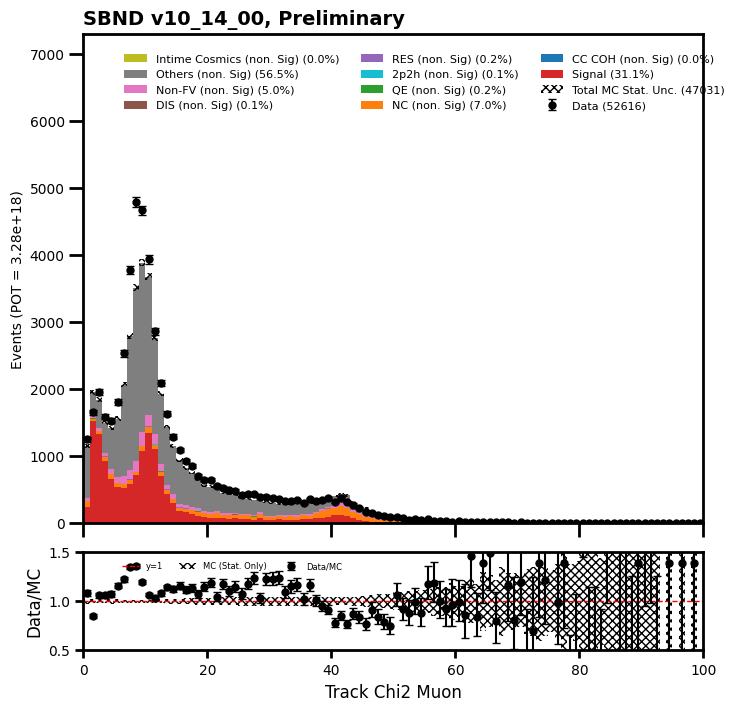

total_mc  [1088.846     865.91943   665.1952    246.57913   145.5104    101.06854
   87.44949    75.98071    69.52945    59.494415   62.36151    45.875275
   55.193512   45.1584     53.75995    41.57437    41.574303   36.556732
   37.990295   30.105652   27.9552     25.804749   39.423973   21.503967
   32.97278    33.689598   35.12314    30.822449   38.707153   37.990295
   35.1232     27.955109   39.42398    50.175903   45.875214   42.291107
   46.592003   39.42401    35.12317    50.175964   58.06079    50.176025
   53.043236   55.193512   50.176025   52.326355   40.14081    37.990387
   40.14071    40.14084    37.990326   35.84002    32.97278    27.238398
   36.556793   30.822418   22.937653   24.371185   32.972748   36.556793
   33.689598   27.238342   29.388702   22.937592   24.371185   32.97281
   27.955103   33.689545   27.238312   26.52157    23.654419   29.388752
   28.671936   24.371124   31.539124   30.10556    32.25595    32.25592
   30.822327   33.689606   34.406372   32.25

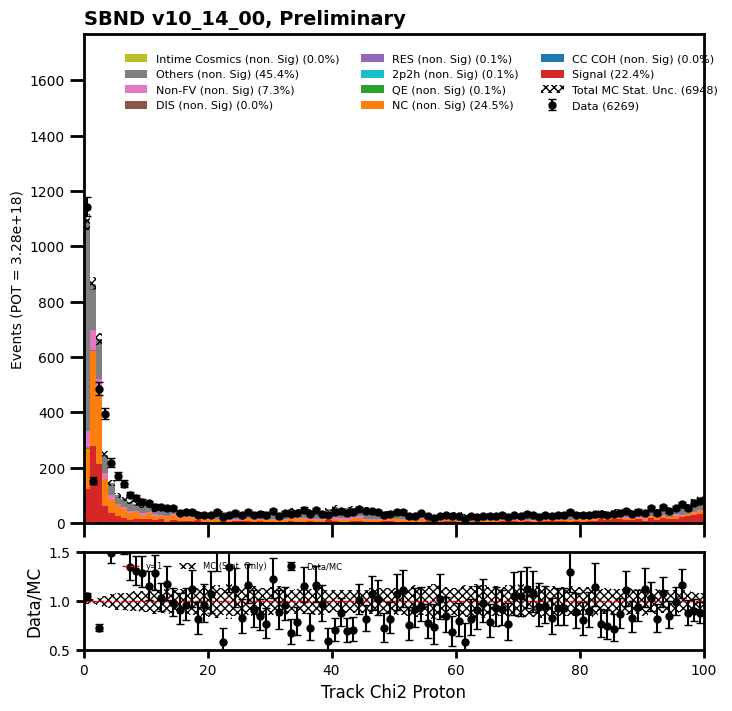

total_mc  [2.26501270e+04 4.90791016e+03 3.51445605e+03 2.24859302e+03
 1.54039709e+03 1.10315088e+03 8.11414368e+02 6.09277649e+02
 4.64484589e+02 3.46213135e+02 2.89586060e+02 2.27941620e+02
 2.05003952e+02 1.44793045e+02 1.44793030e+02 1.15404366e+02
 9.31835938e+01 1.00351585e+02 7.23964844e+01 5.94941406e+01
 5.66269989e+01 5.08925781e+01 4.08574448e+01 3.44062500e+01
 3.72734833e+01 3.01054688e+01 4.08574677e+01 2.65214844e+01
 2.43711414e+01 1.29023438e+01 2.00703125e+01 2.22207031e+01
 1.07519531e+01 1.57695541e+01 1.64863281e+01 1.07519531e+01
 1.07519531e+01 8.60156250e+00 1.21855469e+01 8.60156250e+00]
total data =  47347
[29469  3636  3029  2194  1542  1178   998   750   581   516   447   344
   319   291   208   197   170   132   132   135   105   108   109    60
    78    71    57    46    63    49    54    41    42    29    25    30
    31    28    23    30]
[2.26501270e+04 4.90791016e+03 3.51445605e+03 2.24859302e+03
 1.54039709e+03 1.10315088e+03 8.11414368e+02 6.09277

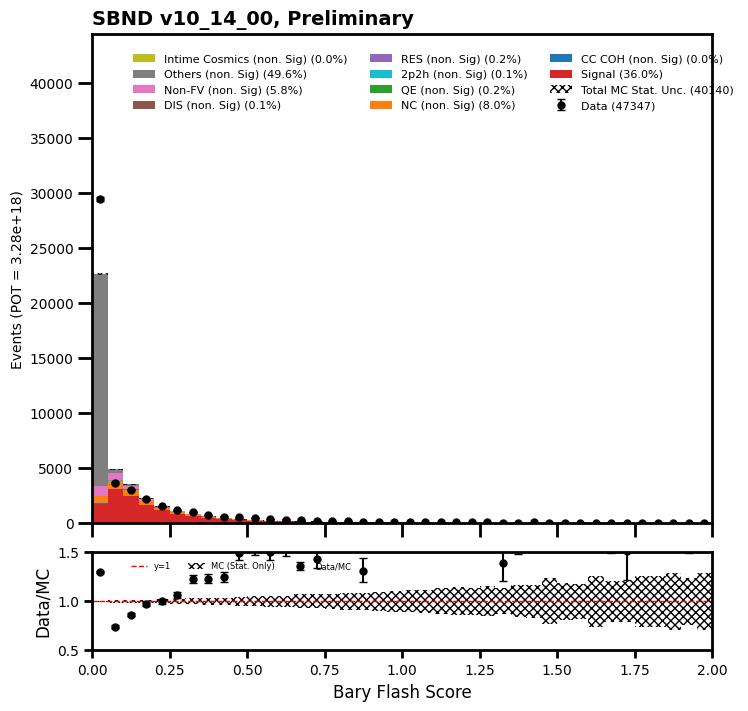

total_mc  [7.1682113e-01 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 7.1682107e-01 0.0000000e+00 0.0000000e+00 0.0000000e+00 1.4336423e+00
 2.1504633e+00 1.4336424e+00 0.0000000e+00 5.0894264e+01 9.7129822e+02
 1.5268195e+02 2.3367801e+02 3.0034027e+02 3.4836618e+02 3.6700305e+02
 4.3366614e+02 4.3796759e+02 4.9817960e+02 4.3939792e+02 4.7667172e+02
 5.3114807e+02 5.1967957e+02 5.5480310e+02 5.6268744e+02 5.5695270e+02
 5.6913721e+02 6.1429510e+02 5.5910156e+02 6.0139258e+02 5.8347278e+02
 5.9565833e+02 6.1644537e+02 5.9207422e+02 6.0712695e+02 6.0282623e+02
 6.3221497e+02 6.0282629e+02 6.5443567e+02 6.4941809e+02 6.4081647e+02
 6.6303717e+02 6.4870123e+02 6.5586951e+02 6.2791425e+02 6.9672668e+02
 6.3293176e+02 6.4081653e+02 6.9816028e+02 7.1034576e+02 7.0891223e+02
 6.6303717e+02 6.5228528e+02 6.9385962e+02 6.0641028e+02 6.7307233e+02
 6.6590442e+02 6.5443665e+02 6.7307239e+02 6.8955872e+02 6.7450598e+02
 6.5085168e+02 6.8884192e+02 6.6948840e+02 6.9385950e+02 6.9027563e

/tmp/ipykernel_1484/3524794362.py:119: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = mc_stat_err / total_mc
/tmp/ipykernel_1484/3524794362.py:120: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = total_mc / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: divide by zero encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: invalid value encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:178: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = data_eylow / total_mc
/tmp/ipykernel_1484/3524794362.py:179: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc
/exp/sbnd/app/users/amoor/cafpyana/cafpyana/envs/venv_py39_cafpyana/lib/python3.9/site-packages/matplotlib/axes/_axes.py:3749: RuntimeWarning: overflow encountered in add
  low, high = dep + np.vstack(

total data =  52619
[   0    0    0    1    0    1    0    1    0    0    2    0    4  258
  938  149  219  295  410  414  432  463  549  427  539  535  564  551
  615  649  605  615  606  644  611  655  699  645  698  708  677  681
  738  675  662  655  668  743  673  917  843  871  820  754  736  804
  796  768  750  755  819  785  799  760  785  778  812  802  754  705
  733  757  727  777  775  748  718  731  643  487  491  440  412  429
  443 3681 2314    9    6    1    2    0    1    0    1    3    0    1
    2    0]
[7.1682113e-01 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 7.1682107e-01 0.0000000e+00 0.0000000e+00 0.0000000e+00 1.4336423e+00
 2.1504633e+00 1.4336424e+00 0.0000000e+00 5.0894264e+01 9.7129822e+02
 1.5268195e+02 2.3367801e+02 3.0034027e+02 3.4836618e+02 3.6700305e+02
 4.3366614e+02 4.3796759e+02 4.9817960e+02 4.3939792e+02 4.7667172e+02
 5.3114807e+02 5.1967957e+02 5.5480310e+02 5.6268744e+02 5.5695270e+02
 5.6913721e+02 6.1429510e+02 5.5910156e+02 6.

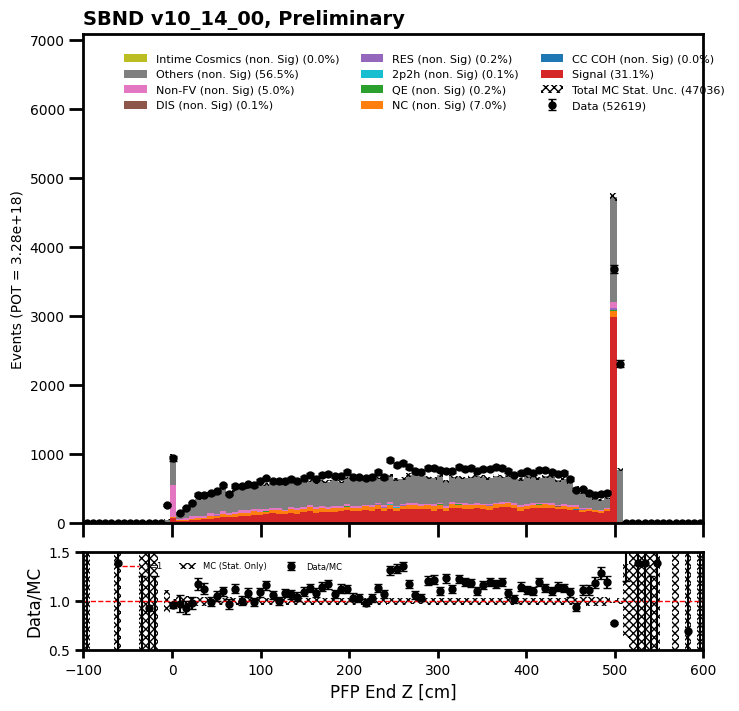

In [54]:
#Vertex Cut

mc_bnb_cosmic_dfs["evt"] = mc_bnb_cosmic_dfs["evt"][InFV(mc_bnb_cosmic_dfs["evt"].slc.vertex)]
data_offbeam_light_dfs["evt"] = data_offbeam_light_dfs["evt"][InFV(data_offbeam_light_dfs["evt"].slc.vertex)]
data_bnb_light_dfs["evt"] = data_bnb_light_dfs["evt"][InFV(data_bnb_light_dfs["evt"].slc.vertex)]

#plot

draw_reco_valid_plots(mc_bnb_cosmic_dfs["evt"], data_offbeam_light_dfs["evt"], data_bnb_light_dfs["evt"], "a_b_vtxfvcut")

In [55]:
purity = 14625.5439453125/47040.60281038284
efficiency = 14625.5439453125/15446.276679992676
print("purity = ", round(purity*100,2), "% and efficiency = ", round(efficiency*100,2), "%")

purity =  31.09 % and efficiency =  94.69 %


In [56]:
def get_evt_nmuon_mask(mask, df):
    sel_idx = mask[mask].index
    #pairs = df.index.droplevel([-2, -1])
    pairs = df.index
    mask2 = pairs.isin(sel_idx)
    return mask2

In [57]:
def make_nmuon_filtered_df(df):
    nmuon_cut = df[(df.pfp.trackScore > 0.6) & (df.pfp.trk.len > 32) & (df.pfp.trk.chi2pid.I2.chi2_muon < 20) & (df.pfp.trk.chi2pid.I2.chi2_proton > 90)].sort_values(df.pfp.index.names[:-1] + [('pfp','trk','len','','','')], ascending=True).groupby(level=[0,1]).nth(-1)
    nmuon_mask = (nmuon_cut == True)

    mc_bnb_cosmic_evt_nmuon_mask = get_evt_nmuon_mask(nmuon_mask, df)
    df[('lead_track_nmuon', '', '', '', '', '')] = mc_bnb_cosmic_evt_nmuon_mask

    valid_slices = df.lead_track_nmuon[df.lead_track_nmuon == True].index

    filtered_df = df.loc[df.index.droplevel('rec.slc.reco.pfp..index').isin(valid_slices.droplevel('rec.slc.reco.pfp..index'))]

    return filtered_df

In [58]:
filtered_df = make_nmuon_filtered_df(mc_bnb_cosmic_dfs["evt"])
filtered_dfb = make_nmuon_filtered_df(data_offbeam_light_dfs["evt"])
filtered_dfc = make_nmuon_filtered_df(data_bnb_light_dfs["evt"])

In [59]:
mc_bnb_cosmic_dfs["evt"] = filtered_df
data_offbeam_light_dfs["evt"] = filtered_dfb
data_bnb_light_dfs["evt"] = filtered_dfc

/tmp/ipykernel_1484/3524794362.py:62: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  each_mc_hist_data = [np.histogram(data, bins=bins, weights=w)[0] for data, w in zip(all_mc_data, all_weights)]
/exp/sbnd/app/users/amoor/cafpyana/cafpyana/envs/venv_py39_cafpyana/lib/python3.9/site-packages/matplotlib/axes/_axes.py:6986: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  bins = np.histogram_bin_edges(
/exp/sbnd/app/users/amoor/cafpyana/cafpyana/envs/venv_py39_cafpyana/lib/python3.9/site-packages/matplotlib/axes/_axes.py:7001: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  m, bins = np.histogram(x[i], bins, weights=w[i], **hist_kwargs)
/tmp/ipykernel_1484/3524794362.py:92: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  hist_vals, _ = np.histogram(data, bins=bins, weights=w)
/tmp/ipykernel_1484/3524794362.py:93: RuntimeWarning

total_mc  [    0.         21455.24174106]
total data =  24129
[    0 24129]
[    0.         21455.24174106]
data ratio  [       nan 1.12462028]
mode sums =  [9827.3056640625, 1.4336422681808472, 331.1729431152344, 36.55787658691406, 14.336419105529785, 33.69059753417969, 13.619598388671875, 843.6904296875, 10353.4345703125, 0.0]
total sums =  21455.24174106121


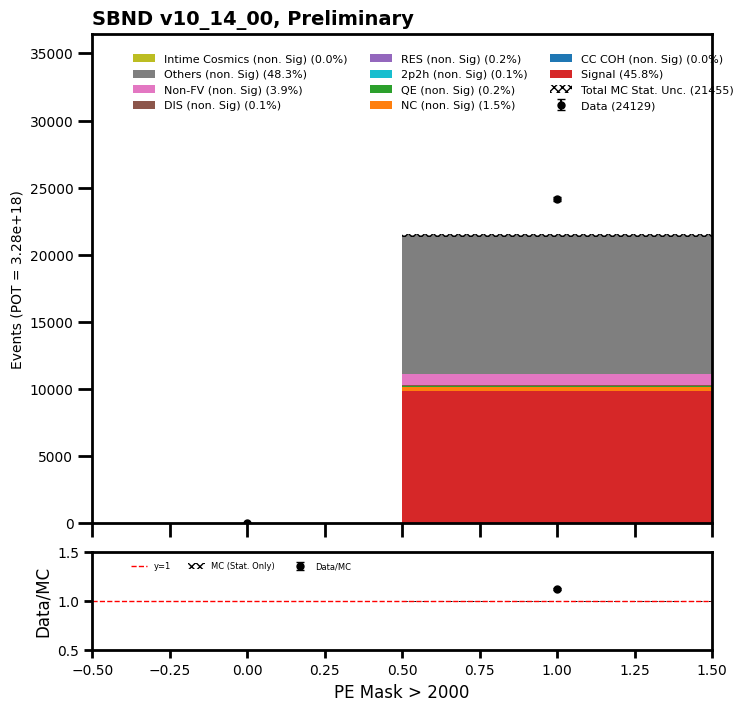

total_mc  [21455.24     0.  ]
total data =  24129
[24129     0]
[21455.24     0.  ]
data ratio  [1.12462036        nan]
mode sums =  [9827.3056640625, 1.4336422681808472, 331.1729431152344, 36.55787658691406, 14.336419105529785, 33.69059753417969, 13.619598388671875, 843.6904296875, 10353.4345703125, 0.0]
total sums =  21455.24174106121


/tmp/ipykernel_1484/3524794362.py:119: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = mc_stat_err / total_mc
/tmp/ipykernel_1484/3524794362.py:120: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = total_mc / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: invalid value encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:178: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = data_eylow / total_mc
/tmp/ipykernel_1484/3524794362.py:179: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc


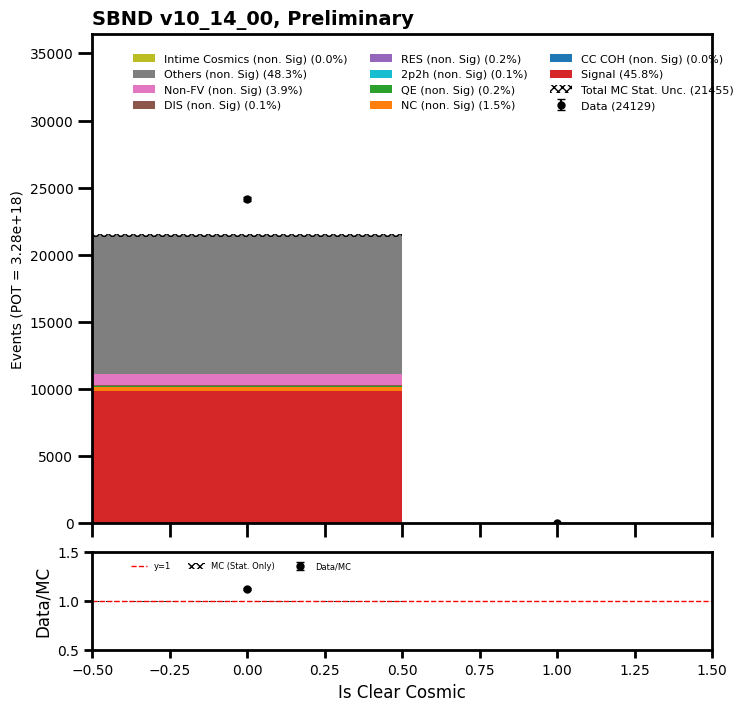

total_mc  [  0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
 221.49747  364.1475   346.94415  406.43204  384.2038   407.85828
 411.44214  402.84094  396.3895   397.10626  391.37183  397.82327
 402.12408  394.2392   440.83096  396.3894   427.92877  364.13373
 413.59262  389.9382   356.96564  392.08887  366.28403  337.61194
 359.1159   364.1337   328.29373  290.3036   332.59454  315.39178
  93.900925   0.         0.        88.16644  329.0107   310.37384
 301.77252  341.91327  307.50632  331.87732  356.96542  356.96527
 336.8948   337.61163  367.71695  350.51392  369.15073  362.69946
 376.3186   364.13303  336.17786  363.41626  359.11548  344.7796
 350.51392  366.2834   339.0451   346.92978  331.877    334.0275
 327.57642  298.18762  287.4357   186.36734    0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.

/tmp/ipykernel_1484/3524794362.py:119: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = mc_stat_err / total_mc
/tmp/ipykernel_1484/3524794362.py:120: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = total_mc / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: invalid value encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:178: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = data_eylow / total_mc
/tmp/ipykernel_1484/3524794362.py:179: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc


total data =  24129
[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
 280 391 400 451 484 493 464 531 502 472 487 458 460 440 455 486 452 450
 457 474 410 432 428 401 398 391 375 377 346 352  89   0   0 103 312 312
 305 311 310 374 339 383 396 360 363 390 383 409 353 369 395 413 394 388
 374 407 381 410 388 370 381 383 370 217   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0]
[  0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
 221.49747  364.1475   346.94415  406.43204  384.2038   407.85828
 411.44214  402.84094  396.3895   397.10626  391.37183  397.82327
 402.12408  394.2392   440.83096  396.3894   427.92877  364.13373
 413.59262  389.9382   356.96564  392.08887  366.28403  337.61194
 359.1159   364.1337   328.29373  290.3036   332.59454  315.39178
  93.900925   0.         0.        88.16644  329.0107   310.

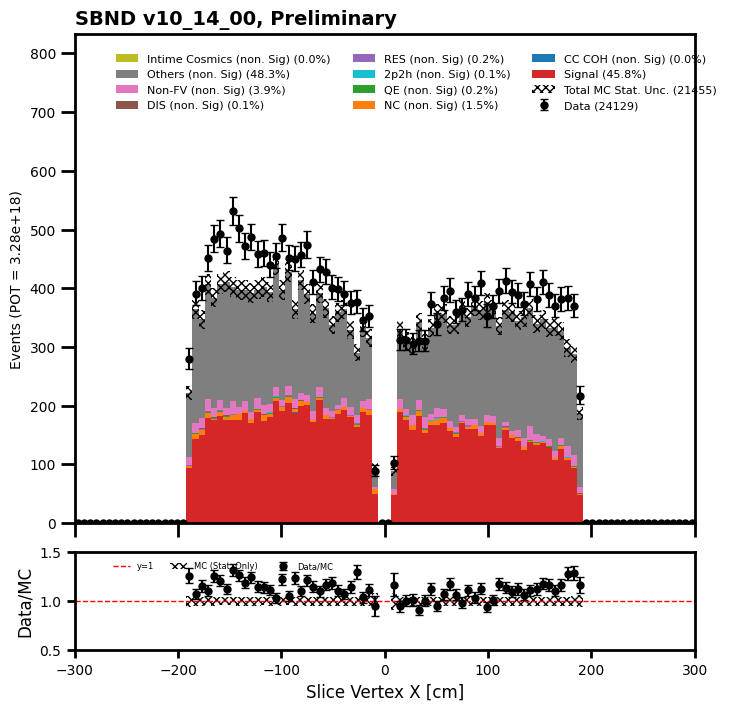

total_mc  [  0.        0.        0.        0.        0.        0.        0.
   0.        0.        0.        0.        0.        0.        0.
   0.        0.        0.        0.      138.34637 216.48027 250.8894
 288.1643  288.1624  252.31325 306.07327 267.36584 270.23315 322.5594
 297.47144 291.02026 288.15292 309.65695 289.58673 283.13574 298.90512
 307.5067  289.58664 301.7723  313.24106 293.8875  331.87772 322.55927
 323.27618 337.61212 314.67453 345.49695 322.55957 333.3113  331.87808
 329.7276  324.7096  306.7896  338.32938 303.92267 329.01074 317.54172
 348.36346 356.96515 356.24835 354.8147  407.1411  362.69943 387.0706
 374.16815 385.637   374.16827 404.9906  410.00806 402.84012 399.25613
 414.30884 463.05115 434.37903 432.94543 450.14868 477.3871  461.61758
 453.01584 401.40637 332.59418 267.36545 164.86331   0.        0.
   0.        0.        0.        0.        0.        0.        0.
   0.        0.        0.        0.        0.        0.        0.
   0.        0.     ]


/tmp/ipykernel_1484/3524794362.py:119: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = mc_stat_err / total_mc
/tmp/ipykernel_1484/3524794362.py:120: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = total_mc / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: invalid value encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:178: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = data_eylow / total_mc
/tmp/ipykernel_1484/3524794362.py:179: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc


total data =  24129
[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
 144 259 268 292 314 325 351 295 291 316 292 306 328 309 290 298 324 318
 364 334 328 317 313 319 338 356 357 350 340 343 365 359 333 393 378 368
 373 353 353 372 384 436 434 428 438 451 480 456 448 446 509 478 501 538
 485 551 573 570 549 565 501 374 307 201   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0]
[  0.        0.        0.        0.        0.        0.        0.
   0.        0.        0.        0.        0.        0.        0.
   0.        0.        0.        0.      138.34637 216.48027 250.8894
 288.1643  288.1624  252.31325 306.07327 267.36584 270.23315 322.5594
 297.47144 291.02026 288.15292 309.65695 289.58673 283.13574 298.90512
 307.5067  289.58664 301.7723  313.24106 293.8875  331.87772 322.55927
 323.27618 337.61212 314.67453 345.49695 322.55957 333.3113  331.87808
 329.7276  324.7096  306.7896  338.32938 303.92267 329.01074 317.54172
 348.36346 356.96

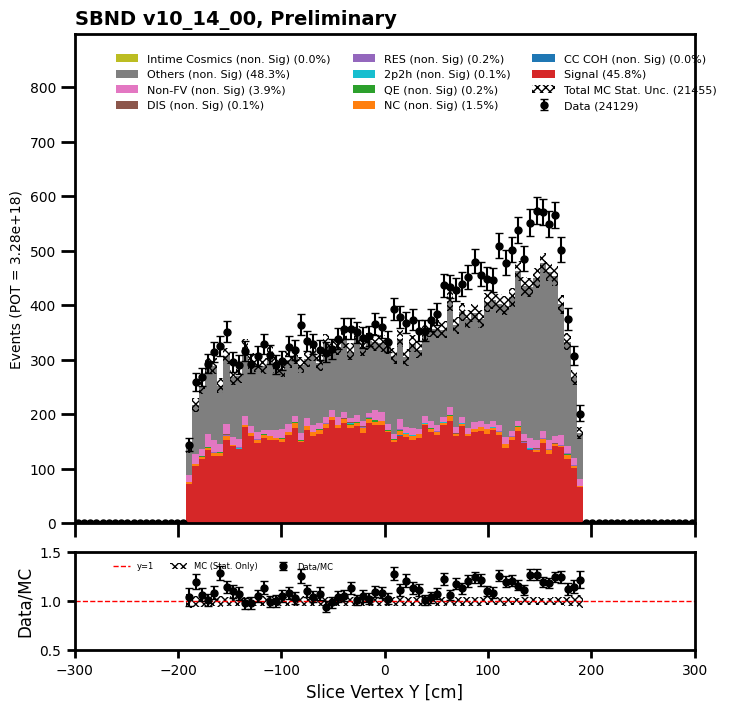

total_mc  [  0.        0.        0.        0.        0.        0.        0.
   0.        0.        0.        0.        0.        0.        0.
   0.      114.69132 344.792   392.10413 387.79904 367.00208 379.90387
 351.23154 326.86102 368.4347  338.3296  370.5857  376.31967 351.94855
 346.21405 308.22345 351.94824 325.42645 339.7627  321.8424  319.692
 323.9927  352.66492 315.39105 355.53207 329.72726 308.93976 292.45337
 308.2229  312.52368 337.61163 323.99255 316.8246  321.84213 319.69177
 341.91238 341.9123  327.5766  318.9748  328.2933  337.61172 324.7091
 312.5238  302.4886  334.02777 325.42593 330.4437  344.06293 327.57645
 338.32837 355.53146 332.59406 351.23074 335.46118 345.49634 320.40845
 341.9124  362.6994  343.34598 354.09802 374.885   349.79712 399.25616
 407.1409  242.9943    0.        0.        0.        0.        0.
   0.        0.        0.        0.        0.        0.        0.
   0.        0.        0.        0.        0.        0.        0.
   0.        0.     ]


/tmp/ipykernel_1484/3524794362.py:119: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = mc_stat_err / total_mc
/tmp/ipykernel_1484/3524794362.py:120: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = total_mc / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: invalid value encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:178: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = data_eylow / total_mc
/tmp/ipykernel_1484/3524794362.py:179: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc


total data =  24129
[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 116 449 407
 418 404 393 424 340 412 359 407 382 383 363 375 379 337 379 334 392 377
 349 356 361 372 364 342 330 369 320 399 343 398 346 340 354 365 390 358
 384 376 371 373 379 388 376 358 394 384 404 370 405 404 383 394 410 399
 406 408 444 439 443 482 269   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0]
[  0.        0.        0.        0.        0.        0.        0.
   0.        0.        0.        0.        0.        0.        0.
   0.      114.69132 344.792   392.10413 387.79904 367.00208 379.90387
 351.23154 326.86102 368.4347  338.3296  370.5857  376.31967 351.94855
 346.21405 308.22345 351.94824 325.42645 339.7627  321.8424  319.692
 323.9927  352.66492 315.39105 355.53207 329.72726 308.93976 292.45337
 308.2229  312.52368 337.61163 323.99255 316.8246  321.84213 319.69177
 341.91238 341.9123  327.5766  318.9748  328.2933  337.61172 324.7091
 312.5238  302.488

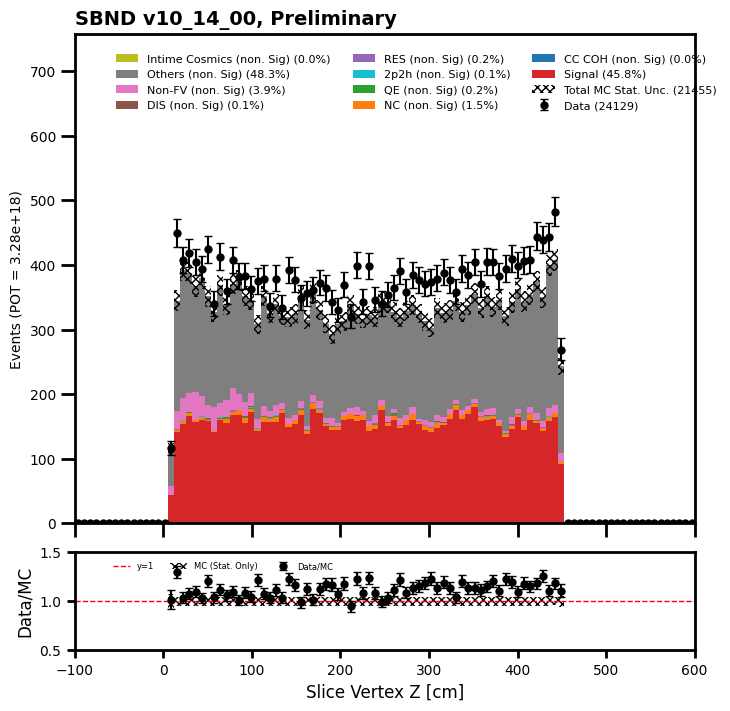

total_mc  [7.1682113e-01 7.1682113e-01 1.0752317e+01 5.2686487e+02 8.2720648e+02
 1.0924083e+03 1.2228604e+03 1.2235771e+03 1.2429298e+03 1.1705325e+03
 1.1404258e+03 1.0200030e+03 9.5119031e+02 8.9241248e+02 8.3220166e+02
 7.7342419e+02 7.6697290e+02 6.8095746e+02 6.1357837e+02 5.7558826e+02
 5.2039471e+02 4.6735168e+02 4.4943182e+02 4.1789264e+02 3.6628333e+02
 3.1754105e+02 3.0678918e+02 2.8313483e+02 2.6664853e+02 2.6951572e+02
 2.3582626e+02 2.0070316e+02 1.8063287e+02 2.0357037e+02 1.6988094e+02
 1.4622664e+02 1.4479300e+02 1.3260748e+02 1.2830667e+02 9.8201195e+01]
total data =  23470
[   1    2   10  538  873 1232 1401 1415 1361 1341 1229 1190 1064 1051
  936  931  812  740  623  657  602  554  466  484  460  395  361  337
  317  283  258  256  218  165  209  190  149  160  108   91]
[7.1682113e-01 7.1682113e-01 1.0752317e+01 5.2686487e+02 8.2720648e+02
 1.0924083e+03 1.2228604e+03 1.2235771e+03 1.2429298e+03 1.1705325e+03
 1.1404258e+03 1.0200030e+03 9.5119031e+02 8.9241248e+0

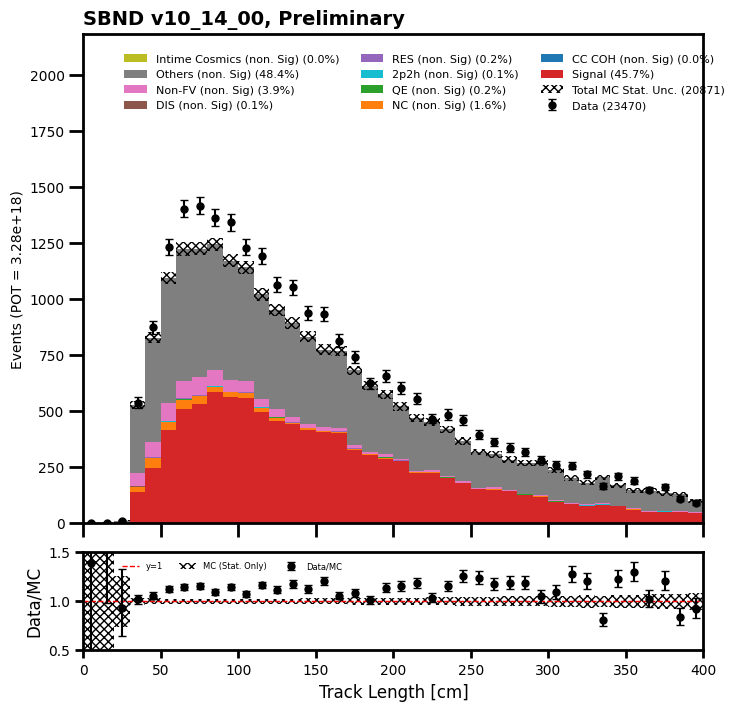

total_mc  [0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 7.1682113e-01 4.3009267e+00 2.1504633e+00 1.2185958e+01 2.0070990e+01
 2.6522377e+01 3.1540098e+01 6.1646523e+01 5.8062550e+01 6.5947952e+01
 5.3045033e+01 3.9425369e+01 3.2257076e+01 2.9389750e+01 1.2185997e+01
 1.7920578e+01 1.5770120e+01 1.7920624e+01 3.3690784e+01 4.1575954e+01
 9.3114447e+02 1.1182067e+03 1.3203445e+03 1.4694386e+03 1.5991793e+03
 1.7325023e+03 1.8163663e+03 1.8679738e+03 1.8192317e+03 1.6765886e+03
 1.5848384e+03 1.4665669e+03 1.2852173e+03 8.6302368e+02 3.1180670e+02
 1.5769531e+01 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00]
total data =  24129
[   0    0    0    0    0    0    0    0    0    0    3    6    4   11
   19   22   54   46   46   36   41   31   29   27   25   15   19   31
   32   45 1265 1471 1584 1787 1856 2014 2025 2042 1898 1806 1686 1550
 1339  959  287   18    0    0    0    0]
[0.0

/tmp/ipykernel_1484/3524794362.py:119: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = mc_stat_err / total_mc
/tmp/ipykernel_1484/3524794362.py:120: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = total_mc / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: invalid value encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:178: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = data_eylow / total_mc
/tmp/ipykernel_1484/3524794362.py:179: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc


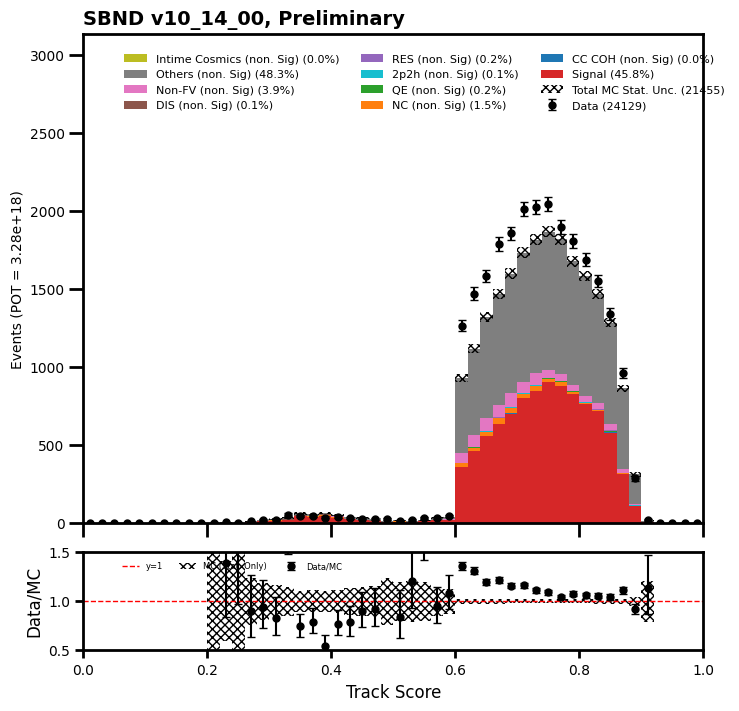

total_mc  [1.8924066e+02 1.4673083e+03 1.3511748e+03 1.0565614e+03 9.6839526e+02
 9.6911212e+02 1.3103081e+03 1.8235359e+03 2.2729673e+03 2.5675723e+03
 2.3181228e+03 1.6364480e+03 1.0121180e+03 6.2648096e+02 4.1430902e+02
 2.3654315e+02 2.0357050e+02 1.7346490e+02 1.2830676e+02 1.0895326e+02
 2.4371178e+01 2.6521576e+01 2.4371124e+01 2.3654377e+01 2.0787231e+01
 1.6486443e+01 2.0070435e+01 1.7203205e+01 1.7203150e+01 1.3619225e+01
 2.0070435e+01 2.7955231e+01 2.0787170e+01 2.3654388e+01 2.2220781e+01
 1.6486359e+01 1.2902405e+01 3.1539154e+01 2.8671989e+01 3.2255981e+01
 4.4441528e+01 3.0822296e+01 2.9388702e+01 1.3619171e+01 1.7203209e+01
 7.1679993e+00 3.5839844e+00 2.8671875e+00 2.8671875e+00 4.3008118e+00
 2.8671875e+00 7.1679688e-01 0.0000000e+00 2.1503906e+00 2.1504211e+00
 1.4335938e+00 2.1504211e+00 1.4335938e+00 2.1503906e+00 7.1679688e-01
 0.0000000e+00 7.1679688e-01 7.1679688e-01 1.4335938e+00 7.1679688e-01
 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e

/tmp/ipykernel_1484/3524794362.py:119: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = mc_stat_err / total_mc
/tmp/ipykernel_1484/3524794362.py:120: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = total_mc / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: divide by zero encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: invalid value encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:178: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = data_eylow / total_mc
/tmp/ipykernel_1484/3524794362.py:179: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc
/exp/sbnd/app/users/amoor/cafpyana/cafpyana/envs/venv_py39_cafpyana/lib/python3.9/site-packages/matplotlib/axes/_axes.py:3749: RuntimeWarning: overflow encountered in add
  low, high = dep + np.vstack(

total data =  24129
[ 114 1211 1475 1134  998 1119 1596 2450 3157 3073 2427 1536 1049  650
  469  344  245  195  175  129   24   23   16   22   28   17   24   18
   27   22   15   22   17   10   16   19   17   26   22   31   28   30
   18   22   15   12    5    4    2    5    2    3    1    1    1    2
    3    3    2    2    1    1    0    0    0    0    0    0    0    0
    1    0    0    1    1    0    0    0    0    0    0    0    0    0
    0    1    0    0    0    0    0    0    0    0    0    0    0    0
    0    0]
[1.8924066e+02 1.4673083e+03 1.3511748e+03 1.0565614e+03 9.6839526e+02
 9.6911212e+02 1.3103081e+03 1.8235359e+03 2.2729673e+03 2.5675723e+03
 2.3181228e+03 1.6364480e+03 1.0121180e+03 6.2648096e+02 4.1430902e+02
 2.3654315e+02 2.0357050e+02 1.7346490e+02 1.2830676e+02 1.0895326e+02
 2.4371178e+01 2.6521576e+01 2.4371124e+01 2.3654377e+01 2.0787231e+01
 1.6486443e+01 2.0070435e+01 1.7203205e+01 1.7203150e+01 1.3619225e+01
 2.0070435e+01 2.7955231e+01 2.0787170e+01 2.

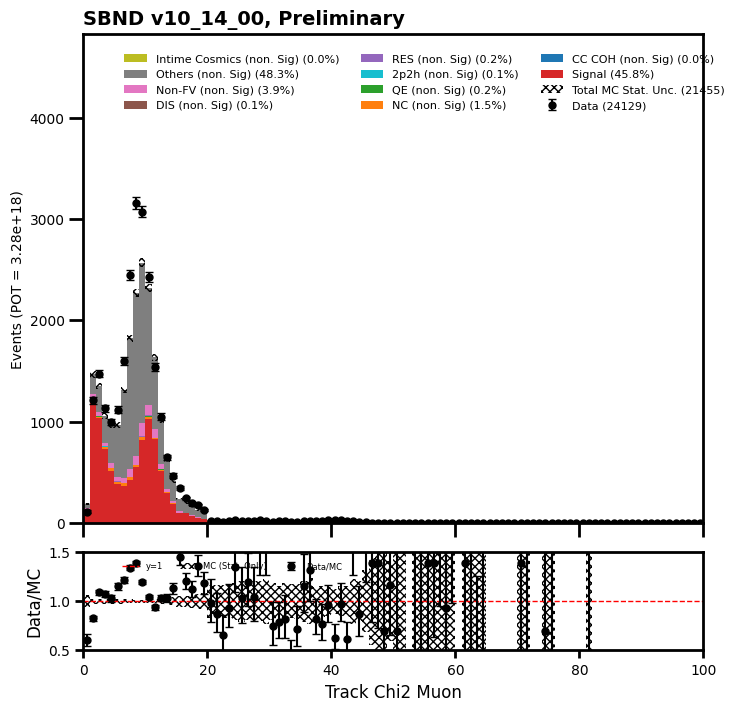

total_mc  [50.177483   91.03615    71.682434   21.504778    8.601908    4.300958
  4.30095     5.017779    4.3009644   2.1504822   3.5841293   2.8672905
  5.017784    0.7168274   4.3009644   2.8673096   3.584115    0.7168274
  3.584137    1.4336472   0.7168274   1.4336414   1.4336548   0.
  2.1504745   0.7168274   2.1504745   2.1504822   1.4336548   2.1504822
  1.4336472   0.          1.4336472   3.5841293   0.7168274   1.4336472
  2.8672957   0.7168274   1.4336548   4.3009567   0.7168274   1.4336395
  2.8672867   2.1504765   1.4336548   0.          0.          1.4336548
  3.584137    0.          0.7168274   0.7168274   1.4336491   1.4336548
  1.4336548   1.4336548   2.1504688   1.4336548   1.4336548   2.8673096
  1.4336395   1.4336548   2.1504688   1.4336548   2.150463    0.7168274
  0.7168274   1.4336548   3.5841293   2.1504688   0.          2.1504822
  0.          0.7168217   1.4336472   0.71681976  0.7168274   2.8673096
  2.1504745   1.4336548   3.5841236   0.71681976  2.1504745   

/tmp/ipykernel_1484/3524794362.py:119: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = mc_stat_err / total_mc
/tmp/ipykernel_1484/3524794362.py:120: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = total_mc / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: divide by zero encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: invalid value encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:178: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = data_eylow / total_mc
/tmp/ipykernel_1484/3524794362.py:179: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc
/exp/sbnd/app/users/amoor/cafpyana/cafpyana/envs/venv_py39_cafpyana/lib/python3.9/site-packages/matplotlib/axes/_axes.py:3749: RuntimeWarning: overflow encountered in add
  low, high = dep + np.vstack(

total data =  528
[51  9 65 45 21 13  9  5  5  3  6  2  1  0  5  2  3  0  0  1  4  2  0  2
  2  1  0  2  0  0  1  0  2  1  0  0  1  0  2  1  2  3  0  0  1  2  2  0
  1  2  3  0  2  0  1  1  0  1  1  0  4  0  2  1  1  1  0  1  2  2  0  1
  2  1  2  0  2  2  0  1  1  1  3  2  3  1  1  1  5  3  7 17  8 21 13 19
 30 19 34 25]
[50.177483   91.03615    71.682434   21.504778    8.601908    4.300958
  4.30095     5.017779    4.3009644   2.1504822   3.5841293   2.8672905
  5.017784    0.7168274   4.3009644   2.8673096   3.584115    0.7168274
  3.584137    1.4336472   0.7168274   1.4336414   1.4336548   0.
  2.1504745   0.7168274   2.1504745   2.1504822   1.4336548   2.1504822
  1.4336472   0.          1.4336472   3.5841293   0.7168274   1.4336472
  2.8672957   0.7168274   1.4336548   4.3009567   0.7168274   1.4336395
  2.8672867   2.1504765   1.4336548   0.          0.          1.4336548
  3.584137    0.          0.7168274   0.7168274   1.4336491   1.4336548
  1.4336548   1.4336548   2.1504688 

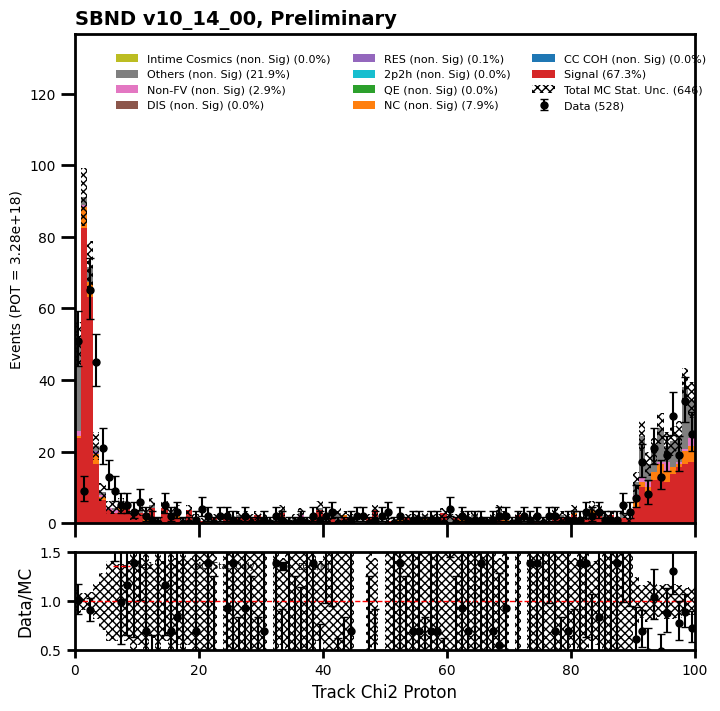

total_mc  [8.5399453e+03 2.5833501e+03 2.0142056e+03 1.3282266e+03 9.1821808e+02
 6.8812616e+02 4.8813950e+02 3.8563721e+02 3.0320569e+02 2.2005698e+02
 1.6988110e+02 1.3905894e+02 1.2974042e+02 9.3183784e+01 9.6767807e+01
 7.3830162e+01 5.7343781e+01 6.3078186e+01 4.3007843e+01 3.7273560e+01
 3.6556694e+01 3.0822327e+01 2.7238365e+01 2.3654297e+01 2.5804733e+01
 1.8636719e+01 2.6521515e+01 1.8636719e+01 1.6486374e+01 1.0035156e+01
 1.3619141e+01 1.7919922e+01 7.1679688e+00 9.3183594e+00 9.3183594e+00
 4.3008118e+00 9.3183594e+00 5.0175781e+00 7.1679688e+00 6.4511719e+00]
total data =  21843
[11298  1921  1678  1279   966   726   624   470   358   333   289   221
   197   201   119   131   119    88    74    82    62    71    68    38
    47    44    40    27    44    30    32    26    26    16    14    18
    18    17    13    18]
[8.5399453e+03 2.5833501e+03 2.0142056e+03 1.3282266e+03 9.1821808e+02
 6.8812616e+02 4.8813950e+02 3.8563721e+02 3.0320569e+02 2.2005698e+02
 1.6988110e+02

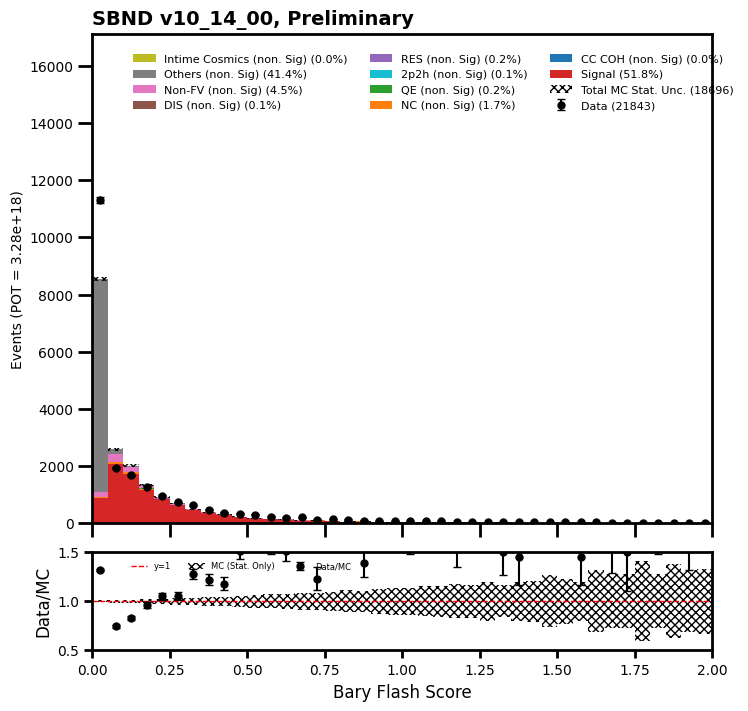

total_mc  [7.1682113e-01 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 7.1682107e-01 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 7.1682119e-01 7.1682113e-01 0.0000000e+00 3.0823315e+01 5.4837018e+02
 4.1575836e+01 4.8027275e+01 5.9496452e+01 6.8098373e+01 8.9603287e+01
 1.1684255e+02 1.3117575e+02 1.5984857e+02 1.6128177e+02 1.5339700e+02
 1.8350291e+02 1.8422015e+02 2.1217401e+02 2.2507489e+02 2.1432280e+02
 2.3654358e+02 2.3152597e+02 2.2220746e+02 2.2507477e+02 2.2722516e+02
 2.3941083e+02 2.4586209e+02 2.2292413e+02 2.6163138e+02 2.4586165e+02
 2.7238342e+02 2.5948093e+02 2.8313544e+02 2.7166653e+02 2.7596713e+02
 2.7453339e+02 2.8385172e+02 2.8385205e+02 2.6736554e+02 2.9388708e+02
 2.8671906e+02 2.7309973e+02 2.9532059e+02 2.9603738e+02 2.9388693e+02
 2.7740067e+02 2.6521503e+02 3.0750616e+02 2.6234796e+02 2.9388696e+02
 3.0965662e+02 2.7883441e+02 2.7596698e+02 3.0320526e+02 2.8528531e+02
 2.8958624e+02 2.9388690e+02 2.9675403e+02 3.0535568e+02 3.0607254e

/tmp/ipykernel_1484/3524794362.py:119: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = mc_stat_err / total_mc
/tmp/ipykernel_1484/3524794362.py:120: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = total_mc / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: divide by zero encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: invalid value encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:178: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = data_eylow / total_mc
/tmp/ipykernel_1484/3524794362.py:179: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc
/exp/sbnd/app/users/amoor/cafpyana/cafpyana/envs/venv_py39_cafpyana/lib/python3.9/site-packages/matplotlib/axes/_axes.py:3749: RuntimeWarning: overflow encountered in add
  low, high = dep + np.vstack(

total data =  24128
[   0    0    0    1    0    1    0    0    0    0    0    0    1  160
  527   46   43   73   82   93  128  117  185  156  181  196  209  226
  249  241  258  245  245  261  249  272  294  269  295  285  275  317
  330  287  273  288  280  297  304  389  370  373  308  326  305  351
  351  350  320  324  354  366  350  320  303  351  356  336  327  310
  306  326  328  351  366  331  309  342  289  237  296  273  277  260
  268 2578 1601    3    3    0    0    0    1    0    0    2    0    1
    1    0]
[7.1682113e-01 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 7.1682107e-01 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 7.1682119e-01 7.1682113e-01 0.0000000e+00 3.0823315e+01 5.4837018e+02
 4.1575836e+01 4.8027275e+01 5.9496452e+01 6.8098373e+01 8.9603287e+01
 1.1684255e+02 1.3117575e+02 1.5984857e+02 1.6128177e+02 1.5339700e+02
 1.8350291e+02 1.8422015e+02 2.1217401e+02 2.2507489e+02 2.1432280e+02
 2.3654358e+02 2.3152597e+02 2.2220746e+02 2.

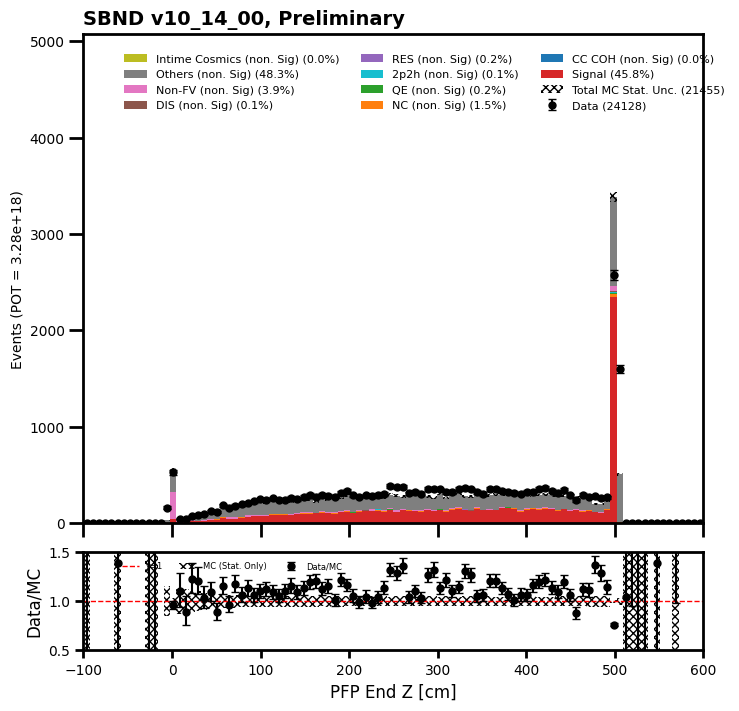

In [60]:
#Has muon candidate

draw_reco_valid_plots(mc_bnb_cosmic_dfs["evt"],  data_offbeam_light_dfs["evt"], data_bnb_light_dfs["evt"], "a_vtx_fv_and_not_clear_cosmic_nu_score")

In [61]:
purity = 9827.3056640625/21455.24174106121
efficiency = 9827.3056640625/15446.276679992676
print("purity = ", round(purity*100,2), "% and efficiency = ", round(efficiency*100,2), "%")

purity =  45.8 % and efficiency =  63.62 %


/tmp/ipykernel_1484/3524794362.py:62: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  each_mc_hist_data = [np.histogram(data, bins=bins, weights=w)[0] for data, w in zip(all_mc_data, all_weights)]
/exp/sbnd/app/users/amoor/cafpyana/cafpyana/envs/venv_py39_cafpyana/lib/python3.9/site-packages/matplotlib/axes/_axes.py:6986: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  bins = np.histogram_bin_edges(
/exp/sbnd/app/users/amoor/cafpyana/cafpyana/envs/venv_py39_cafpyana/lib/python3.9/site-packages/matplotlib/axes/_axes.py:7001: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  m, bins = np.histogram(x[i], bins, weights=w[i], **hist_kwargs)
/tmp/ipykernel_1484/3524794362.py:92: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  hist_vals, _ = np.histogram(data, bins=bins, weights=w)
/tmp/ipykernel_1484/3524794362.py:93: RuntimeWarning

total_mc  [   0.         9871.07320869]
total data =  10655
[    0 10655]
[   0.         9871.07320869]
data ratio  [       nan 1.07941657]
mode sums =  [8635.9892578125, 1.4336422681808472, 272.3930969238281, 32.2569580078125, 12.902777671813965, 30.823314666748047, 12.902777671813965, 628.6513671875, 243.7200164794922, 0.0]
total sums =  9871.07320868969


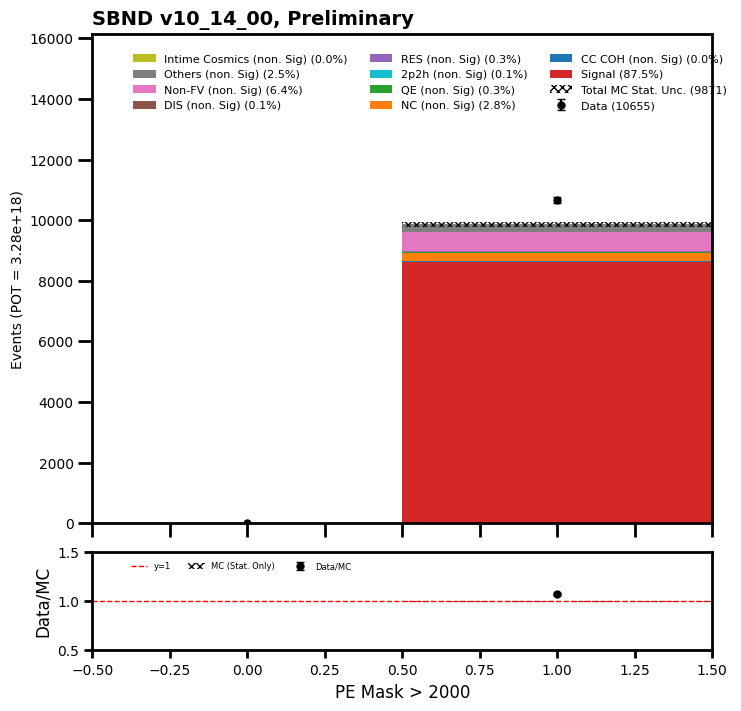

total_mc  [9871.072    0.   ]
total data =  10655
[10655     0]
[9871.072    0.   ]
data ratio  [1.07941667        nan]
mode sums =  [8635.9892578125, 1.4336422681808472, 272.3930969238281, 32.2569580078125, 12.902777671813965, 30.823314666748047, 12.902777671813965, 628.6513671875, 243.7200164794922, 0.0]
total sums =  9871.07320868969


/tmp/ipykernel_1484/3524794362.py:119: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = mc_stat_err / total_mc
/tmp/ipykernel_1484/3524794362.py:120: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = total_mc / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: invalid value encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:178: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = data_eylow / total_mc
/tmp/ipykernel_1484/3524794362.py:179: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc


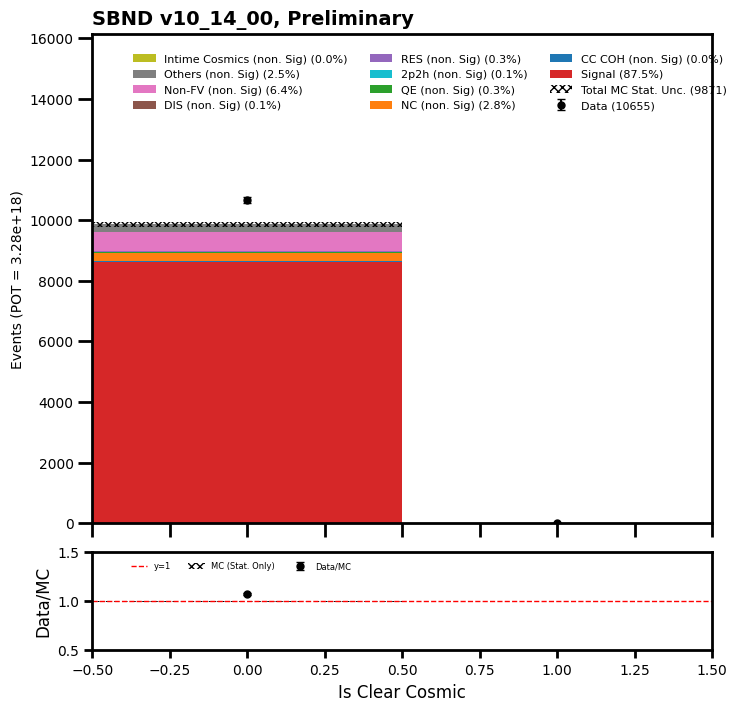

total_mc  [  0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
  98.2044   138.34695  149.0999   176.33931  174.90092  189.95207
 171.3152   174.1825   168.4479   192.10217  169.88138  194.25294
 184.9346   187.80164  212.88957  196.40314  211.45612  194.96973
 200.70396  201.42055  175.61598  207.15518  183.50076  178.483
 179.9166   192.10245  173.46553  166.29779  184.21747  188.51862
  56.62745    0.         0.        53.043304 191.38571  172.03201
 166.29785  187.80177  159.84659  159.8463   177.04999  176.33296
 156.26245  149.09448  167.73111  150.528    158.413    155.54575
 157.69601  169.16473  126.87382  159.12941  147.66077  143.35985
 126.87344  139.77557  127.5902   124.722855 118.98849  102.50232
 126.8735    98.918236  97.4847    48.742455   0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.

/tmp/ipykernel_1484/3524794362.py:119: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = mc_stat_err / total_mc
/tmp/ipykernel_1484/3524794362.py:120: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = total_mc / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: invalid value encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:178: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = data_eylow / total_mc
/tmp/ipykernel_1484/3524794362.py:179: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc


total data =  10655
[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  97 153 169 186 230 207 210 240 230 223 202 220 215 195 217 236 232 213
 216 222 185 207 191 207 190 189 196 210 203 188  52   0   0  59 157 150
 154 142 150 168 162 159 171 168 169 172 159 162 144 158 167 173 154 150
 157 146 142 142 130 140 124 118 115  62   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0]
[  0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
  98.2044   138.34695  149.0999   176.33931  174.90092  189.95207
 171.3152   174.1825   168.4479   192.10217  169.88138  194.25294
 184.9346   187.80164  212.88957  196.40314  211.45612  194.96973
 200.70396  201.42055  175.61598  207.15518  183.50076  178.483
 179.9166   192.10245  173.46553  166.29779  184.21747  188.51862
  56.62745    0.         0.        53.043304 191.38571  172.03

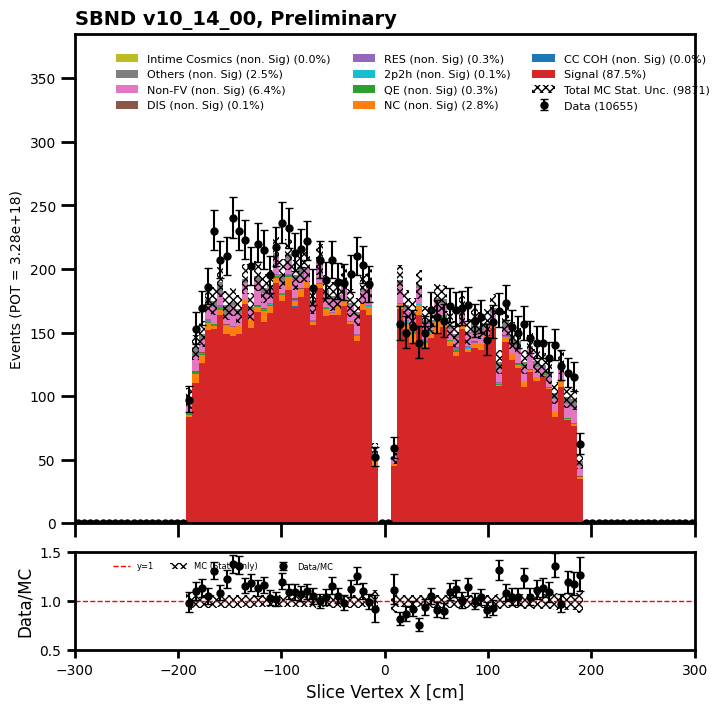

total_mc  [  0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
  70.24842  103.22225  117.55958  131.1792   130.46234  116.12361
 151.96182  145.51033  136.19194  172.74866  159.84637  155.54572
 154.82874  149.09445  155.54568  154.11214  169.16496  181.35048
 148.37753  177.76654  161.28     170.59846  176.33275  187.80145
 180.63367  182.06705  177.76627  178.4831   170.59857  185.65115
 190.66904  179.9169   162.71353  146.94373  174.89963  152.67842
 162.71384  159.12967  185.65137  171.31526  161.99684  179.19989
 195.68669  156.26242  182.06729  157.69598  166.2976   175.61606
 163.43057  169.88159  154.11209  136.90894  153.3949   167.0141
 145.51006  129.0237   129.02386  135.47491  132.6081   136.19174
 127.5901   111.10398  102.50231   63.795105   0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0

/tmp/ipykernel_1484/3524794362.py:119: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = mc_stat_err / total_mc
/tmp/ipykernel_1484/3524794362.py:120: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = total_mc / total_mc


total data =  10655
[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  72 127 126 132 141 156 169 156 141 160 153 164 175 151 143 162 170 161
 199 167 174 166 188 172 187 183 185 172 169 167 199 184 158 175 186 193
 188 181 160 177 188 196 197 186 197 182 203 168 185 170 180 175 170 185
 165 170 174 171 176 174 160 131  99  64   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0]
[  0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
  70.24842  103.22225  117.55958  131.1792   130.46234  116.12361
 151.96182  145.51033  136.19194  172.74866  159.84637  155.54572
 154.82874  149.09445  155.54568  154.11214  169.16496  181.35048
 148.37753  177.76654  161.28     170.59846  176.33275  187.80145
 180.63367  182.06705  177.76627  178.4831   170.59857  185.65115
 190.66904  179.9169   162.71353  146.94373  174.89963  152.

/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: invalid value encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:178: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = data_eylow / total_mc
/tmp/ipykernel_1484/3524794362.py:179: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc


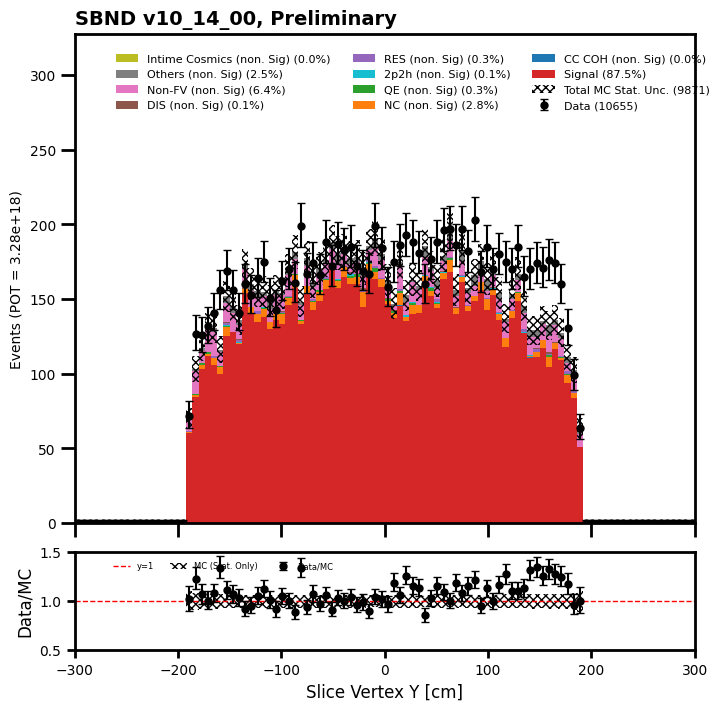

total_mc  [  0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.        43.726093 146.23149  145.51567
 154.83446  159.85172  158.41293  156.97937  154.82951  150.5283
 159.13007  181.35107  174.8996   164.14761  174.18262  148.37764
 164.86418  163.43036  170.59863  173.46542  150.52795  152.67827
 173.46576  144.79361  185.65125  175.6159   155.54547  152.6785
 148.37747  162.71347  167.01431  167.01443  162.71356  147.66083
 159.12978  178.48306  160.56328  167.0146   154.11209  159.84653
 163.43054  153.39497  144.79356  143.35985  159.12991  154.11188
 164.86401  176.33253  155.54526  159.84613  172.74835  159.84616
 155.54535  156.97879  142.64291  133.32466  149.0941   160.56293
 134.04132  144.07652  132.6077   130.45737  141.20929  141.9262
  70.2463     0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.       

/tmp/ipykernel_1484/3524794362.py:119: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = mc_stat_err / total_mc
/tmp/ipykernel_1484/3524794362.py:120: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = total_mc / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: invalid value encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:178: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = data_eylow / total_mc
/tmp/ipykernel_1484/3524794362.py:179: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc


total data =  10655
[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  52 173 172
 185 187 180 209 164 200 173 202 173 169 182 169 176 154 190 170 188 186
 163 171 159 174 179 158 156 168 166 186 143 173 157 141 149 156 166 161
 157 164 161 178 182 182 182 161 159 156 162 168 171 164 171 153 161 163
 156 164 152 159 185 169  95   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0]
[  0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.        43.726093 146.23149  145.51567
 154.83446  159.85172  158.41293  156.97937  154.82951  150.5283
 159.13007  181.35107  174.8996   164.14761  174.18262  148.37764
 164.86418  163.43036  170.59863  173.46542  150.52795  152.67827
 173.46576  144.79361  185.65125  175.6159   155.54547  152.6785
 148.37747  162.71347  167.01431  167.01443  162.71356  147.66083
 159.12978  178.48306  160.56328  167.0146   154.11209  1

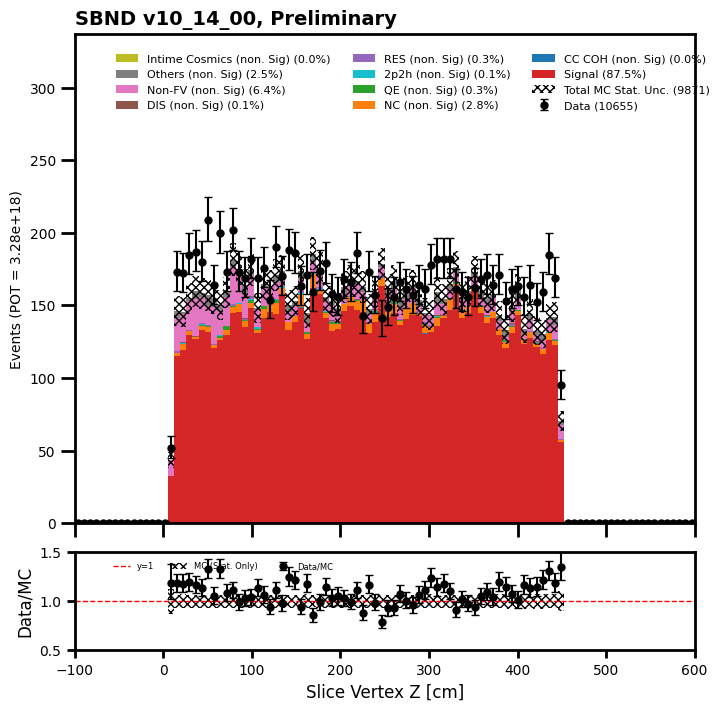

total_mc  [  0.71682113   0.71682113   3.5841055  167.73602    275.2607
 424.35538    503.9118     546.2031     570.5738     541.90094
 565.5556     493.87558    461.61923    423.6284     401.40753
 392.08905    381.3368     327.57755    294.60443    283.13574
 262.34845    219.34042    219.3401     200.70337    177.76593
 150.52768    147.6604     142.64273    129.74048    121.85572
 101.78535     89.599815    79.56461     92.46714     73.830185
  70.246414    52.326416    52.326225    51.60955     48.742332  ]
total data =  10342
[  1   1   6 141 287 448 601 650 618 643 568 564 488 470 430 427 377 341
 294 297 295 265 215 234 192 192 146 137 138 122 106 116  94  78  70  75
  61  69  46  39]
[  0.71682113   0.71682113   3.5841055  167.73602    275.2607
 424.35538    503.9118     546.2031     570.5738     541.90094
 565.5556     493.87558    461.61923    423.6284     401.40753
 392.08905    381.3368     327.57755    294.60443    283.13574
 262.34845    219.34042    219.3401     200.703

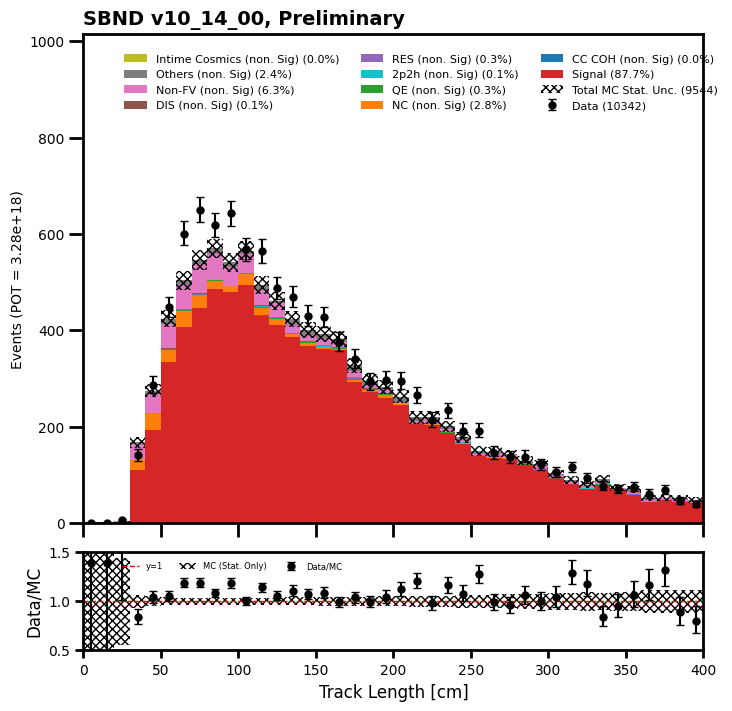

total_mc  [0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 7.1682113e-01 1.4336421e+00 2.1504633e+00 7.8850307e+00 1.3619602e+01
 1.7203705e+01 2.3655064e+01 4.7310116e+01 4.1575577e+01 5.3761967e+01
 4.0859066e+01 3.0106709e+01 2.0787956e+01 1.7920612e+01 5.7346039e+00
 1.0035553e+01 8.6019135e+00 1.2186058e+01 1.9354305e+01 2.1504768e+01
 3.6342645e+02 4.6377014e+02 5.6412262e+02 6.1573212e+02 7.0676599e+02
 7.8776385e+02 8.6231116e+02 8.7807935e+02 8.6589429e+02 8.1069995e+02
 7.4977185e+02 7.3543469e+02 6.0067688e+02 3.3976260e+02 1.2185576e+02
 7.8847656e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00]
total data =  10655
[  0   0   0   0   0   0   0   0   0   0   0   2   3   6  12  14  36  35
  33  23  28  21  23  13  14   9   7  18  16  23 501 638 701 752 803 859
 929 931 851 815 758 677 613 362 120   9   0   0   0   0]
[0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+0

/tmp/ipykernel_1484/3524794362.py:119: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = mc_stat_err / total_mc
/tmp/ipykernel_1484/3524794362.py:120: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = total_mc / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: invalid value encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:178: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = data_eylow / total_mc
/tmp/ipykernel_1484/3524794362.py:179: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc


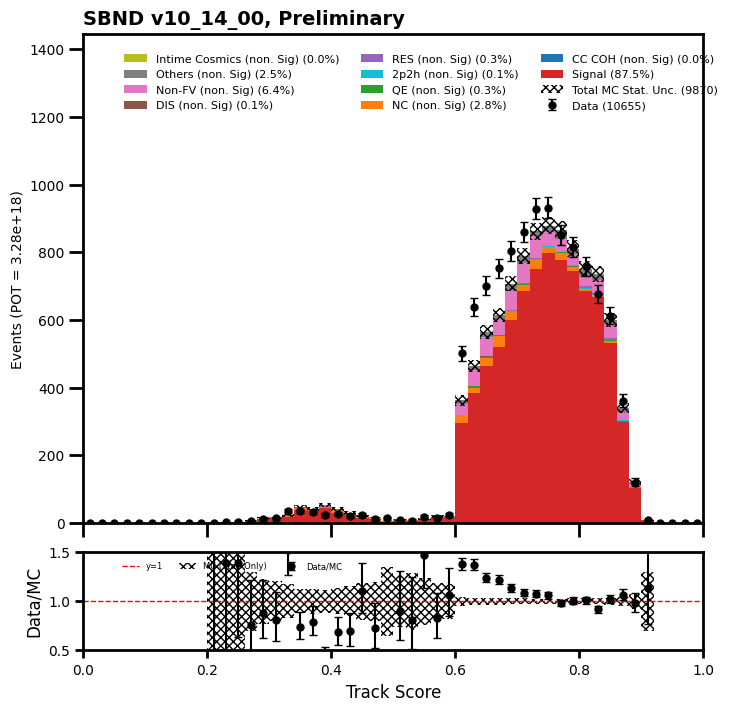

total_mc  [1.3476221e+02 1.1318403e+03 9.8846490e+02 7.2109985e+02 5.1179510e+02
 4.0069168e+02 3.9639175e+02 4.7380670e+02 5.8777771e+02 8.5514484e+02
 1.0307595e+03 8.2001904e+02 5.2469672e+02 2.9030353e+02 1.8780133e+02
 9.9634941e+01 9.7484627e+01 6.6662254e+01 5.5193626e+01 4.0857563e+01
 1.5052789e+01 1.5052826e+01 1.7203156e+01 1.7203297e+01 1.4336029e+01
 1.2902460e+01 1.3619263e+01 1.0035267e+01 1.4335962e+01 1.0752039e+01
 1.5052856e+01 2.5088043e+01 1.4336029e+01 1.8636841e+01 1.2902424e+01
 1.0751984e+01 7.8848572e+00 2.5804764e+01 2.1504023e+01 2.8671997e+01
 3.5839966e+01 2.7238312e+01 2.4371124e+01 1.2185577e+01 1.2902435e+01
 4.3008118e+00 2.1503906e+00 2.1503906e+00 1.4335938e+00 2.1504211e+00
 1.4335938e+00 0.0000000e+00 0.0000000e+00 7.1679688e-01 7.1682739e-01
 0.0000000e+00 1.4336243e+00 7.1679688e-01 0.0000000e+00 7.1679688e-01
 0.0000000e+00 7.1679688e-01 7.1679688e-01 7.1679688e-01 0.0000000e+00
 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e

/tmp/ipykernel_1484/3524794362.py:119: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = mc_stat_err / total_mc
/tmp/ipykernel_1484/3524794362.py:120: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = total_mc / total_mc


total data =  10655
[  65  988 1128  777  582  470  455  681  980 1163 1026  661  476  252
  178  119   94   68   58   33   14   11   10    9   19   14   14   11
   18   16    9   15    8    8   10   12   14   20   17   24   26   23
   16   17   10   11    5    2    1    4    0    1    1    1    0    1
    2    2    1    2    1    0    0    0    0    0    0    0    0    0
    0    0    0    0    1    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0]
[1.3476221e+02 1.1318403e+03 9.8846490e+02 7.2109985e+02 5.1179510e+02
 4.0069168e+02 3.9639175e+02 4.7380670e+02 5.8777771e+02 8.5514484e+02
 1.0307595e+03 8.2001904e+02 5.2469672e+02 2.9030353e+02 1.8780133e+02
 9.9634941e+01 9.7484627e+01 6.6662254e+01 5.5193626e+01 4.0857563e+01
 1.5052789e+01 1.5052826e+01 1.7203156e+01 1.7203297e+01 1.4336029e+01
 1.2902460e+01 1.3619263e+01 1.0035267e+01 1.4335962e+01 1.0752039e+01
 1.5052856e+01 2.5088043e+01 1.4336029e+01 1.

/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: divide by zero encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: invalid value encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:178: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = data_eylow / total_mc
/tmp/ipykernel_1484/3524794362.py:179: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc
/exp/sbnd/app/users/amoor/cafpyana/cafpyana/envs/venv_py39_cafpyana/lib/python3.9/site-packages/matplotlib/axes/_axes.py:3749: RuntimeWarning: overflow encountered in add
  low, high = dep + np.vstack([-(1 - lolims), 1 - uplims]) * err


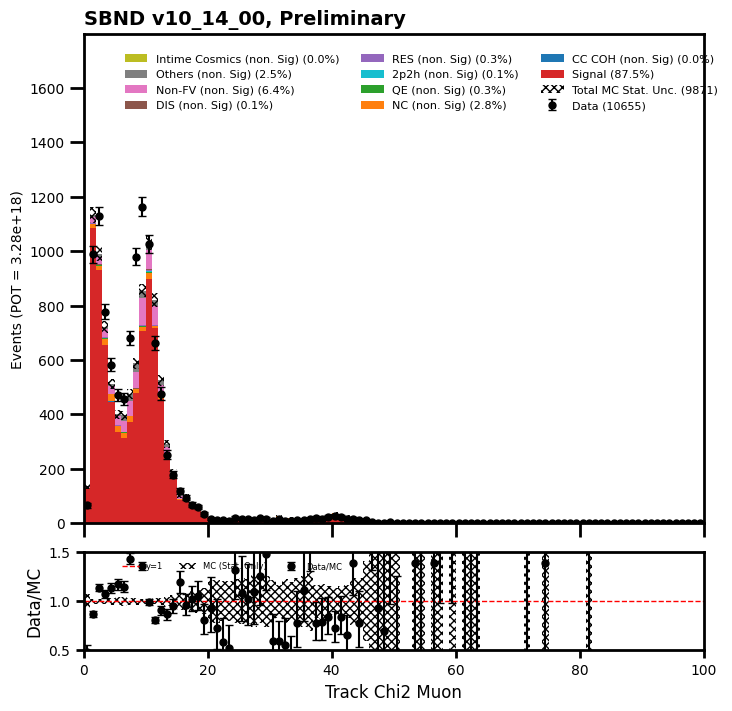

total_mc  [27.239202  84.58476   59.496346  18.63748    7.8850884  3.5841308
  2.1504822  4.3009577  4.3009644  1.4336548  2.1504822  2.8672903
  4.3009644  0.7168274  3.584137   2.8673096  2.1504755  0.7168274
  2.8673096  0.7168274  0.7168274  0.7168217  1.4336548  0.
  1.4336548  0.7168274  1.4336548  2.1504822  1.4336548  2.1504822
  0.7168274  0.         0.7168274  2.8673096  0.7168274  0.7168274
  2.150476   0.7168274  1.4336548  3.584137   0.7168274  1.4336548
  0.7168274  2.1504765  0.7168274  0.         0.         1.4336548
  3.584137   0.         0.7168274  0.7168274  1.4336491  1.4336548
  1.4336548  1.4336548  1.4336491  1.4336548  1.4336395  2.1504822
  0.         0.7168274  1.4336491  1.4336548  1.4336433  0.7168274
  0.7168274  1.4336548  2.8673096  1.4336491  0.         1.4336548
  0.         0.7168217  0.         0.         0.7168274  2.8673096
  1.4336548  1.4336548  3.584125   0.         1.4336548  2.8673038
  2.1504822  2.150476   2.1504822  0.7168217  2.1504757  1.

/tmp/ipykernel_1484/3524794362.py:119: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = mc_stat_err / total_mc
/tmp/ipykernel_1484/3524794362.py:120: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = total_mc / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: divide by zero encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: invalid value encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:178: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = data_eylow / total_mc
/tmp/ipykernel_1484/3524794362.py:179: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc
/exp/sbnd/app/users/amoor/cafpyana/cafpyana/envs/venv_py39_cafpyana/lib/python3.9/site-packages/matplotlib/axes/_axes.py:3749: RuntimeWarning: overflow encountered in add
  low, high = dep + np.vstack(

total data =  370
[22  8 60 40 19  8  9  4  5  3  5  2  1  0  4  2  3  0  0  1  4  2  0  1
  2  1  0  2  0  0  0  0  1  0  0  0  0  0  1  1  2  3  0  0  1  0  2  0
  0  1  2  0  2  0  1  1  0  1  1  0  4  0  2  0  1  1  0  1  1  2  0  0
  0  1  1  0  1  2  0  1  1  0  2  1  2  1  0  0  3  2  3 12  5 15  8 10
 19 10 20 10]
[27.239202  84.58476   59.496346  18.63748    7.8850884  3.5841308
  2.1504822  4.3009577  4.3009644  1.4336548  2.1504822  2.8672903
  4.3009644  0.7168274  3.584137   2.8673096  2.1504755  0.7168274
  2.8673096  0.7168274  0.7168274  0.7168217  1.4336548  0.
  1.4336548  0.7168274  1.4336548  2.1504822  1.4336548  2.1504822
  0.7168274  0.         0.7168274  2.8673096  0.7168274  0.7168274
  2.150476   0.7168274  1.4336548  3.584137   0.7168274  1.4336548
  0.7168274  2.1504765  0.7168274  0.         0.         1.4336548
  3.584137   0.         0.7168274  0.7168274  1.4336491  1.4336548
  1.4336548  1.4336548  1.4336491  1.4336548  1.4336395  2.1504822
  0.         

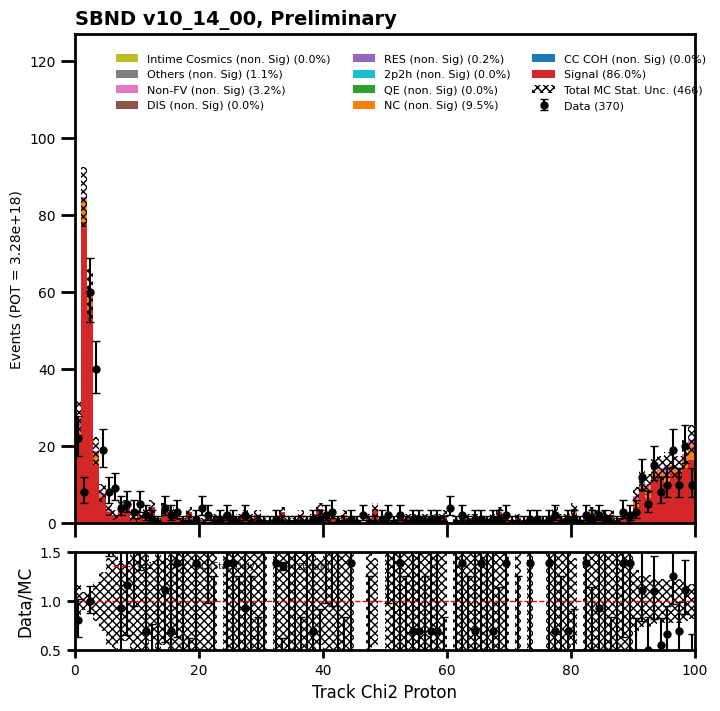

total_mc  [   0.        2146.124     2014.2103    1328.2307     918.22046
  688.12756    488.1398     385.63736    303.20593    220.057
  169.88126    139.05898    129.74045     93.183784    96.76781
   73.83018     57.34378     63.078247    43.007843    37.27356
   36.556725    30.822357    27.238367    23.654297    25.804737
   18.636719    26.521515    18.636719    16.486378    10.035156
   13.619141    17.919922     7.1679688    9.318359     9.318359
    4.300812     9.318359     5.017578     7.1679688    6.451172 ]
total data =  10259
[   0 1635 1678 1279  966  726  624  470  358  333  289  221  197  201
  119  131  119   88   74   82   62   71   68   38   47   44   40   27
   44   30   32   26   26   16   14   18   18   17   13   18]
[   0.        2146.124     2014.2103    1328.2307     918.22046
  688.12756    488.1398     385.63736    303.20593    220.057
  169.88126    139.05898    129.74045     93.183784    96.76781
   73.83018     57.34378     63.078247    43.007843    37.27

/tmp/ipykernel_1484/3524794362.py:119: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = mc_stat_err / total_mc
/tmp/ipykernel_1484/3524794362.py:120: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = total_mc / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: invalid value encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:178: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = data_eylow / total_mc
/tmp/ipykernel_1484/3524794362.py:179: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc


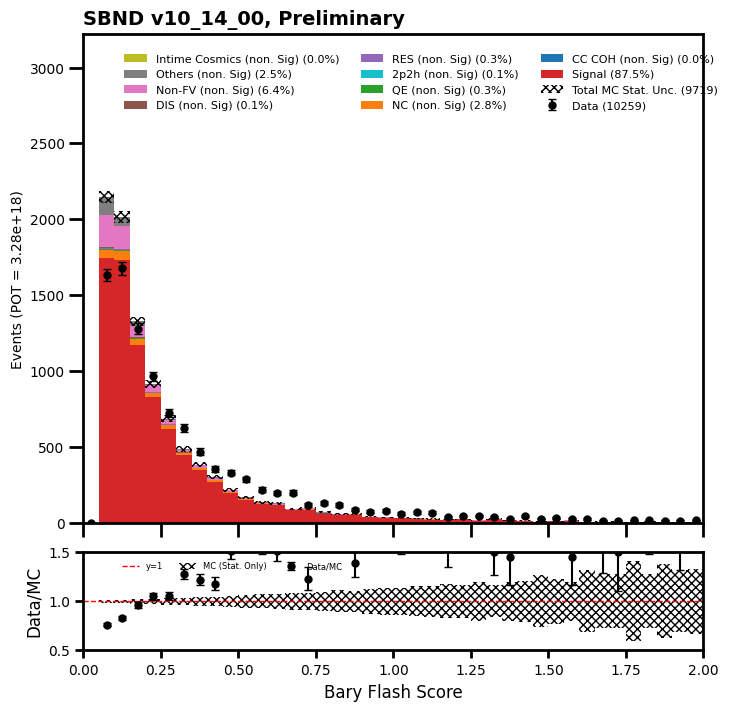

total_mc  [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 7.16821134e-01
 0.00000000e+00 2.15046334e+00 2.31533691e+02 1.21859760e+01
 1.43364344e+01 2.29382877e+01 1.64868870e+01 1.86373463e+01
 3.22569237e+01 3.29738998e+01 5.08947220e+01 5.01778564e+01
 4.30096207e+01 5.37620239e+01 6.30807495e+01 6.45144196e+01
 6.88153610e+01 7.45497971e+01 8.81667252e+01 7.88481293e+01
 8.02815933e+01 8.24321213e+01 9.39009323e+01 9.89184723e+01
 9.67681046e+01 8.95998764e+01 1.08953674e+02 9.89184189e+01
 1.08953758e+02 1.09670509e+02 1.24723373e+02 1.08953751e+02
 1.24006660e+02 1.24006294e+02 1.31891296e+02 1.31174423e+02
 1.21856148e+02 1.40492889e+02 1.20422577e+02 1.34041550e+02
 1.26156761e+02 1.27590607e+02 1.24006409e+02 1.36908783e+02
 1.11820610e+02 1.36908737e+02 1.27590508e+02 1.42643250e+02
 1.56262573e+02 1.42643387e+02 1.29023865e+02 1.50527969e+02
 1.34041473e+0

/tmp/ipykernel_1484/3524794362.py:119: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = mc_stat_err / total_mc
/tmp/ipykernel_1484/3524794362.py:120: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = total_mc / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: divide by zero encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: invalid value encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:178: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = data_eylow / total_mc
/tmp/ipykernel_1484/3524794362.py:179: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc
/exp/sbnd/app/users/amoor/cafpyana/cafpyana/envs/venv_py39_cafpyana/lib/python3.9/site-packages/matplotlib/axes/_axes.py:3749: RuntimeWarning: overflow encountered in add
  low, high = dep + np.vstack(

total data =  10655
[   0    0    0    0    0    0    0    0    0    0    0    0    0   70
  228   15   15   21   34   38   38   47   58   43   58   68   78   78
   95   88   92   90   96   99  102  137  118  117  119  114  120  121
  137  117  114  123  123  141  137  178  132  137  108  137  134  141
  134  139  142  144  164  157  159  135  120  144  157  153  142  153
  150  155  137  147  168  147  139  154  129   98  146  119  131  140
  124 1593  675    1    1    0    0    0    1    0    0    1    0    0
    0    0]
[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 7.16821134e-01
 0.00000000e+00 2.15046334e+00 2.31533691e+02 1.21859760e+01
 1.43364344e+01 2.29382877e+01 1.64868870e+01 1.86373463e+01
 3.22569237e+01 3.29738998e+01 5.08947220e+01 5.01778564e+01
 4.30096207e+01 5.37620239e+01 6.30807495e+01 6.45144196e+01
 6.88153610e+01 7.45497971e+01 8.81667252e+0

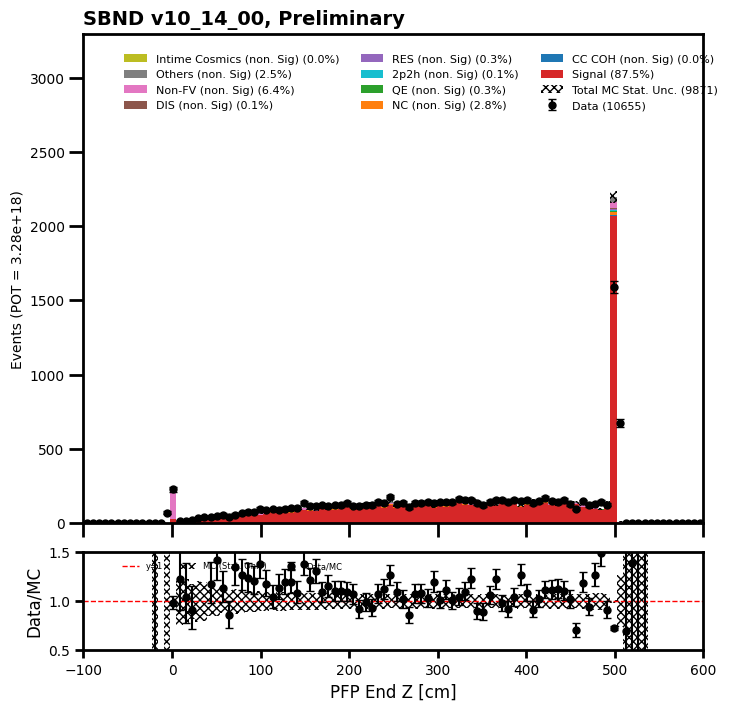

In [62]:
#bary score

mc_bnb_cosmic_dfs["evt"] = mc_bnb_cosmic_dfs["evt"][ (mc_bnb_cosmic_dfs["evt"].slc.barycenterFM.score > 0.06)]
data_offbeam_light_dfs["evt"] = data_offbeam_light_dfs["evt"][(data_offbeam_light_dfs["evt"].slc.barycenterFM.score > 0.06)]
data_bnb_light_dfs["evt"] = data_bnb_light_dfs["evt"][(data_bnb_light_dfs["evt"].slc.barycenterFM.score > 0.06)]

draw_reco_valid_plots(mc_bnb_cosmic_dfs["evt"], data_offbeam_light_dfs["evt"], data_bnb_light_dfs["evt"], "a_vtx_fv_and_not_clear_cosmic_nu_score_bscore")

In [63]:
purity = 8635.9892578125/9871.07320868969
efficiency = 8635.9892578125/15446.276679992676
print("purity = ", round(purity*100,2), "% and efficiency = ", round(efficiency*100,2), "%")

purity =  87.49 % and efficiency =  55.91 %


In [64]:
def make_nmuonz_filtered_df(df):
    nmuonz_cut = df[(df.pfp.trackScore > 0.6) & (df.pfp.trk.len > 32) & (df.pfp.trk.chi2pid.I2.chi2_muon < 20) & (df.pfp.trk.chi2pid.I2.chi2_proton > 90) & (df.pfp.trk.end.z > 6)].sort_values(df.pfp.index.names[:-1] + [('pfp','trk','end','z','','')], ascending=True).groupby(level=[0,1]).nth(-1)
    nmuonz_mask = (nmuonz_cut == True)

    mc_bnb_cosmic_evt_nmuonz_mask = get_evt_nmuon_mask(nmuonz_mask, df)
    df[('lead_track_nmuonz', '', '', '', '', '')] = mc_bnb_cosmic_evt_nmuonz_mask

    valid_slicesz = df.lead_track_nmuonz[df.lead_track_nmuonz == True].index

    filtered_dfz = df.loc[df.index.droplevel('rec.slc.reco.pfp..index').isin(valid_slicesz.droplevel('rec.slc.reco.pfp..index'))]

    return filtered_dfz

In [65]:
filtered_dfz = make_nmuonz_filtered_df(mc_bnb_cosmic_dfs["evt"])
filtered_dfzb = make_nmuonz_filtered_df(data_offbeam_light_dfs["evt"])
filtered_dfzc = make_nmuonz_filtered_df(data_bnb_light_dfs["evt"])

/tmp/ipykernel_1484/1187105749.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[('lead_track_nmuonz', '', '', '', '', '')] = mc_bnb_cosmic_evt_nmuonz_mask
/tmp/ipykernel_1484/1187105749.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[('lead_track_nmuonz', '', '', '', '', '')] = mc_bnb_cosmic_evt_nmuonz_mask
/tmp/ipykernel_1484/1187105749.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats

In [66]:
mc_bnb_cosmic_dfs["evt"] = filtered_dfz
data_offbeam_light_dfs["evt"] = filtered_dfzb
data_bnb_light_dfs["evt"] = filtered_dfzc

/tmp/ipykernel_1484/3524794362.py:62: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  each_mc_hist_data = [np.histogram(data, bins=bins, weights=w)[0] for data, w in zip(all_mc_data, all_weights)]
/exp/sbnd/app/users/amoor/cafpyana/cafpyana/envs/venv_py39_cafpyana/lib/python3.9/site-packages/matplotlib/axes/_axes.py:6986: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  bins = np.histogram_bin_edges(
/exp/sbnd/app/users/amoor/cafpyana/cafpyana/envs/venv_py39_cafpyana/lib/python3.9/site-packages/matplotlib/axes/_axes.py:7001: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  m, bins = np.histogram(x[i], bins, weights=w[i], **hist_kwargs)
/tmp/ipykernel_1484/3524794362.py:92: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  hist_vals, _ = np.histogram(data, bins=bins, weights=w)
/tmp/ipykernel_1484/3524794362.py:93: RuntimeWarning

total_mc  [   0.         9647.42937934]
total data =  10369
[    0 10369]
[   0.         9647.42937934]
data ratio  [       nan 1.07479408]
mode sums =  [8603.7333984375, 1.4336422681808472, 272.3930969238281, 32.2569580078125, 12.902777671813965, 30.823314666748047, 12.902777671813965, 440.1307067871094, 240.8527069091797, 0.0]
total sums =  9647.429379343987


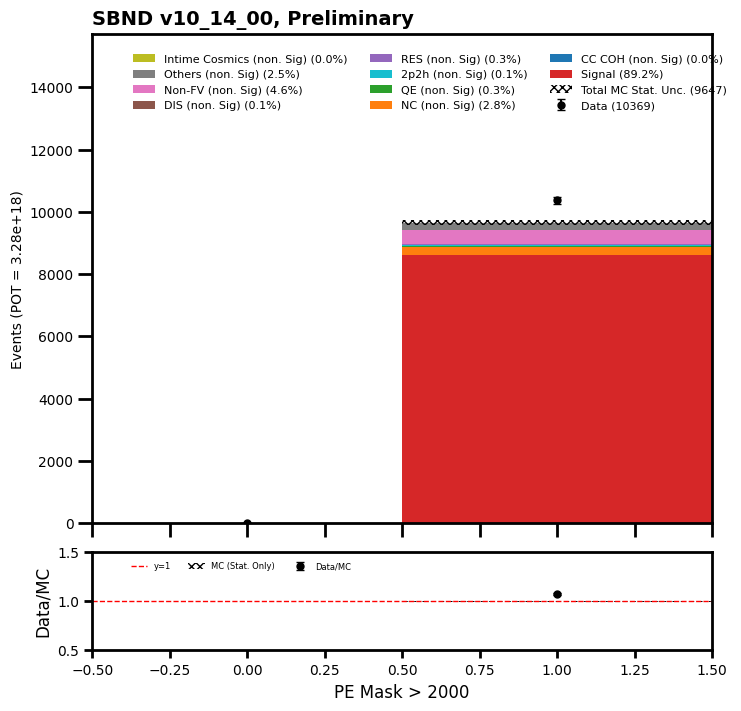

total_mc  [9647.429    0.   ]
total data =  10369
[10369     0]
[9647.429    0.   ]
data ratio  [1.07479416        nan]
mode sums =  [8603.7333984375, 1.4336422681808472, 272.3930969238281, 32.2569580078125, 12.902777671813965, 30.823314666748047, 12.902777671813965, 440.1307067871094, 240.8527069091797, 0.0]
total sums =  9647.429379343987


/tmp/ipykernel_1484/3524794362.py:119: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = mc_stat_err / total_mc
/tmp/ipykernel_1484/3524794362.py:120: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = total_mc / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: invalid value encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:178: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = data_eylow / total_mc
/tmp/ipykernel_1484/3524794362.py:179: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc


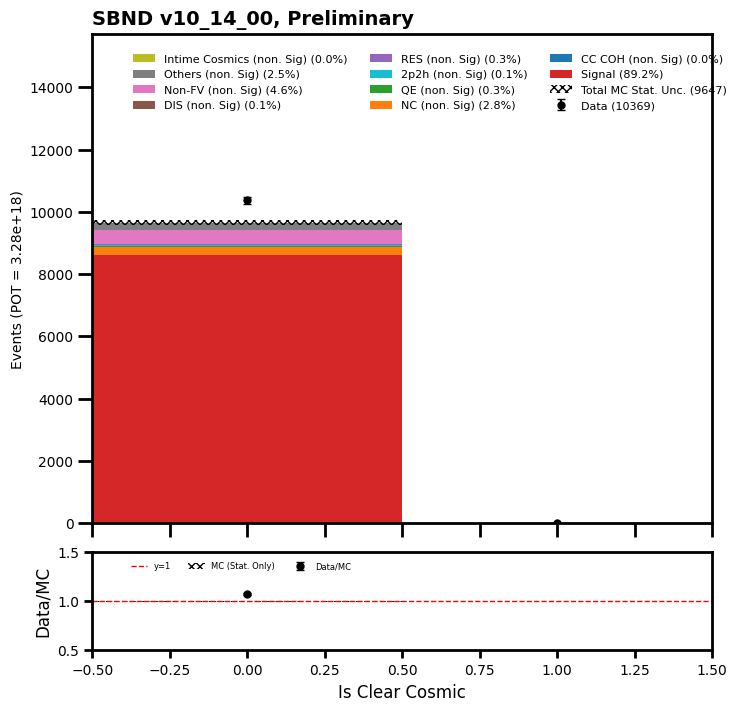

total_mc  [  0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
  93.90348  136.19647  146.94943  175.62251  172.03375  187.08481
 169.88159  168.44794  165.58063  188.51813  169.16458  189.95193
 179.91675  182.78378  207.87178  192.81903  208.58887  190.66876
 194.25258  199.27007  169.88136  203.57108  179.19981  173.46527
 177.76614  187.08472  166.29738  162.71365  182.78381  182.78403
  55.91062    0.         0.        52.32646  188.5184   169.16473
 159.12961  179.19986  154.112    156.97905  172.0322   171.31517
 151.24472  144.79352  164.147    145.51024  155.54572  150.52798
 153.39505  164.8638   123.28968  156.97911  145.5105   139.77617
 125.44025  136.19214  124.72323  123.28935  118.272026  99.6355
 124.72338   98.2019    91.033806  46.592308   0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0

/tmp/ipykernel_1484/3524794362.py:119: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = mc_stat_err / total_mc
/tmp/ipykernel_1484/3524794362.py:120: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = total_mc / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: invalid value encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:178: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = data_eylow / total_mc
/tmp/ipykernel_1484/3524794362.py:179: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc


total data =  10369
[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  94 150 166 184 228 201 206 237 225 218 197 214 208 189 216 226 226 209
 214 213 180 202 183 198 186 184 190 202 201 182  51   0   0  56 150 145
 148 138 144 163 156 150 166 162 165 167 151 161 140 154 165 168 148 149
 149 143 139 138 127 138 120 117 113  59   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0]
[  0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
  93.90348  136.19647  146.94943  175.62251  172.03375  187.08481
 169.88159  168.44794  165.58063  188.51813  169.16458  189.95193
 179.91675  182.78378  207.87178  192.81903  208.58887  190.66876
 194.25258  199.27007  169.88136  203.57108  179.19981  173.46527
 177.76614  187.08472  166.29738  162.71365  182.78381  182.78403
  55.91062    0.         0.        52.32646  188.5184   169.

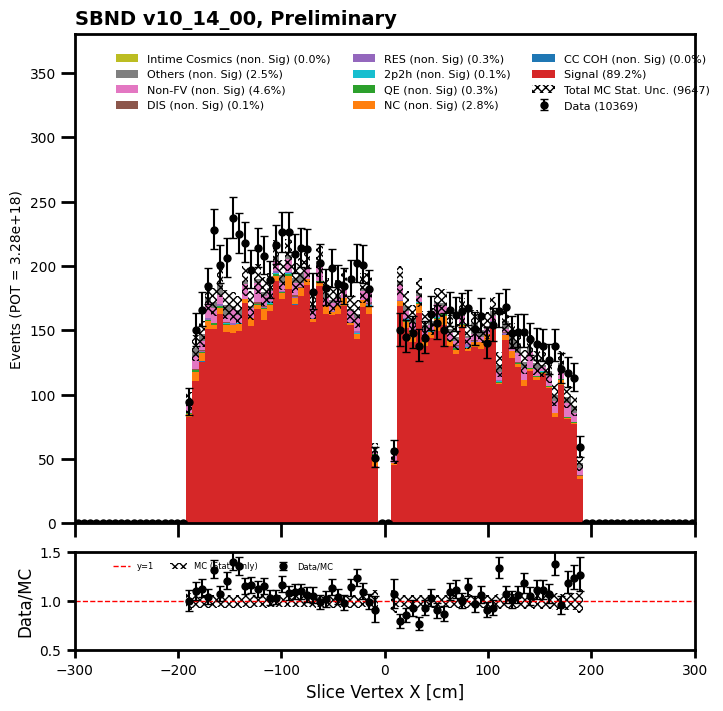

total_mc  [  0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
  68.09796  100.35496  114.69228  131.17921  128.31187  114.69003
 150.52818  140.49263  134.0415   169.88141  152.67822  152.67834
 154.11185  146.22708  149.0942   150.52803  164.14717  177.7664
 143.35974  173.46558  158.41272  164.86394  170.59819  182.78369
 177.76636  179.19977  173.46536  177.04947  167.7313   183.50067
 185.65125  177.76642  156.26212  144.79327  168.44818  146.94386
 155.5456   154.8287   181.35043  167.01433  159.84636  176.33258
 191.38576  153.39514  178.48318  154.11185  161.99667  169.8815
 159.12961  165.58069  150.52798  133.32486  151.96155  164.14716
 143.36003  124.72325  127.59052  131.17441  130.4581   133.32492
 124.006485 109.6706    99.63546   63.078674   0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.

/tmp/ipykernel_1484/3524794362.py:119: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = mc_stat_err / total_mc
/tmp/ipykernel_1484/3524794362.py:120: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = total_mc / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: invalid value encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:178: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = data_eylow / total_mc
/tmp/ipykernel_1484/3524794362.py:179: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc


total data =  10369
[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  66 124 122 127 137 153 164 152 141 155 148 159 172 146 137 158 166 159
 188 165 167 162 185 165 180 179 180 168 166 166 195 178 151 172 182 185
 183 178 157 170 184 191 191 178 191 178 200 159 183 166 176 171 167 177
 162 162 170 166 171 173 157 128  96  64   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0]
[  0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
  68.09796  100.35496  114.69228  131.17921  128.31187  114.69003
 150.52818  140.49263  134.0415   169.88141  152.67822  152.67834
 154.11185  146.22708  149.0942   150.52803  164.14717  177.7664
 143.35974  173.46558  158.41272  164.86394  170.59819  182.78369
 177.76636  179.19977  173.46536  177.04947  167.7313   183.50067
 185.65125  177.76642  156.26212  144.79327  168.44818  146.9

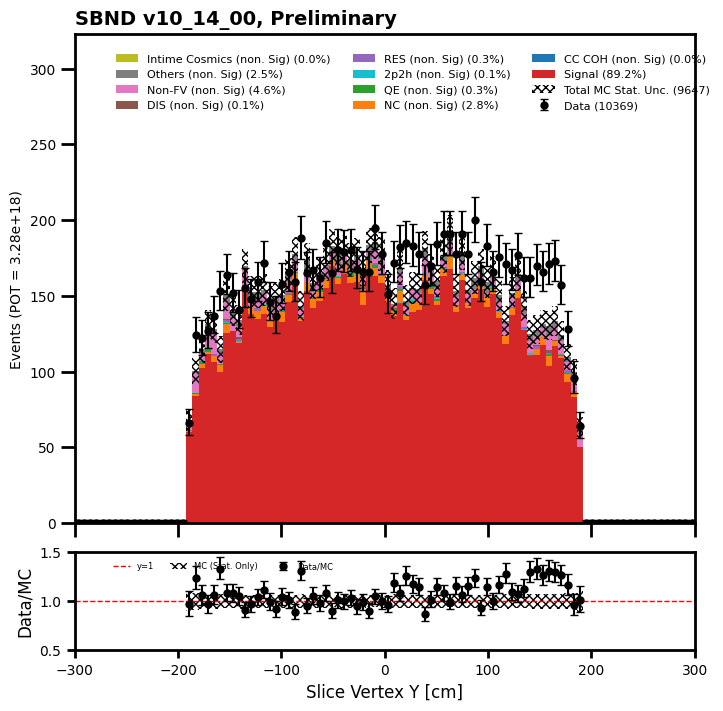

total_mc  [  0.        0.        0.        0.        0.        0.        0.
   0.        0.        0.        0.        0.        0.        0.
   0.       41.57563 139.06323 134.04652 142.64848 142.64842 141.92667
 143.3599  135.47511 142.64316 141.92618 167.73123 164.86392 153.39519
 167.73117 144.7935  162.7137  160.56305 165.58084 171.31494 149.0943
 150.52779 169.88162 142.64316 184.93442 172.7486  154.11182 149.81119
 148.37747 160.56299 165.58066 163.4303  162.71356 146.22717 156.26245
 178.48305 160.56328 165.58095 152.67844 159.84653 162.71371 153.39497
 144.07674 141.9262  158.41309 154.11188 164.14722 176.33275 154.8287
 159.12952 172.7486  159.12952 155.54568 156.26236 141.9263  133.32475
 148.37767 160.56323 134.04147 144.07686 132.60788 130.45761 139.77597
 141.92659  69.52987   0.        0.        0.        0.        0.
   0.        0.        0.        0.        0.        0.        0.
   0.        0.        0.        0.        0.        0.        0.
   0.        0.     ]


/tmp/ipykernel_1484/3524794362.py:119: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = mc_stat_err / total_mc
/tmp/ipykernel_1484/3524794362.py:120: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = total_mc / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: invalid value encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:178: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = data_eylow / total_mc
/tmp/ipykernel_1484/3524794362.py:179: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc


total data =  10369
[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  49 158 159
 163 160 159 184 141 183 162 186 164 158 174 161 170 152 186 166 185 184
 161 168 157 173 177 158 155 167 165 185 143 172 157 140 149 156 166 161
 157 164 161 177 181 182 180 161 159 156 161 166 170 163 171 151 161 162
 155 161 150 157 185 169  95   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0]
[  0.        0.        0.        0.        0.        0.        0.
   0.        0.        0.        0.        0.        0.        0.
   0.       41.57563 139.06323 134.04652 142.64848 142.64842 141.92667
 143.3599  135.47511 142.64316 141.92618 167.73123 164.86392 153.39519
 167.73117 144.7935  162.7137  160.56305 165.58084 171.31494 149.0943
 150.52779 169.88162 142.64316 184.93442 172.7486  154.11182 149.81119
 148.37747 160.56299 165.58066 163.4303  162.71356 146.22717 156.26245
 178.48305 160.56328 165.58095 152.67844 159.84653 162.71371 153.39497
 144.07674 141.9

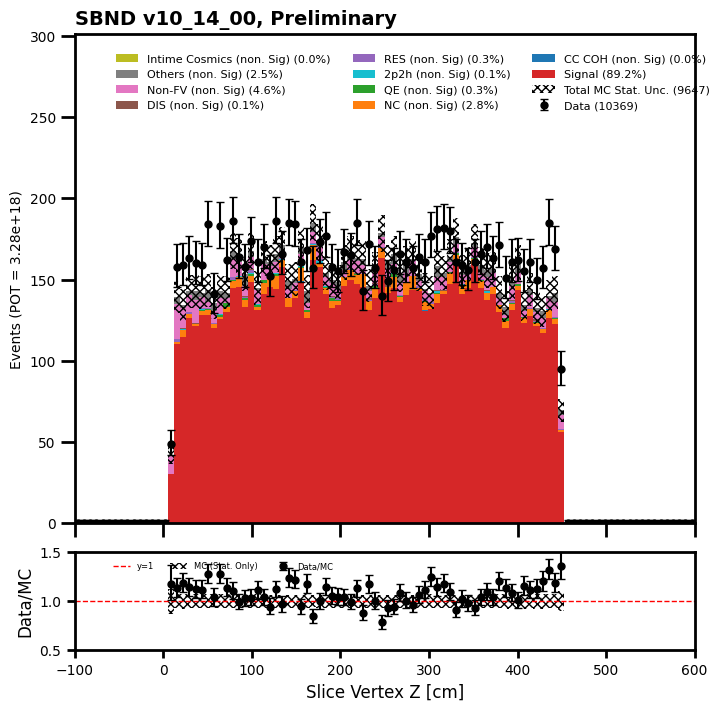

total_mc  [  0.71682113   0.71682113   3.5841055  153.39958    258.057
 399.2672     490.2918     519.6807     546.2018     523.98035
 554.08636    484.55685    453.73416    419.32742    396.3897
 388.505      378.4695     323.27655    292.45395    280.26843
 260.9148     217.18997    214.32274    197.11957    176.33252
 149.81097    146.22705    140.4925     129.74057    121.13914
 100.35194     88.88317     79.5648      91.03367     72.39659
  70.2466      51.60968     50.892693    51.609673    48.02569   ]
total data =  10067
[  1   1   5 125 260 420 571 608 602 620 557 551 479 461 427 419 371 335
 290 294 291 265 214 234 189 191 145 137 138 122 106 114  92  77  70  75
  61  68  43  38]
[  0.71682113   0.71682113   3.5841055  153.39958    258.057
 399.2672     490.2918     519.6807     546.2018     523.98035
 554.08636    484.55685    453.73416    419.32742    396.3897
 388.505      378.4695     323.27655    292.45395    280.26843
 260.9148     217.18997    214.32274    197.11957   

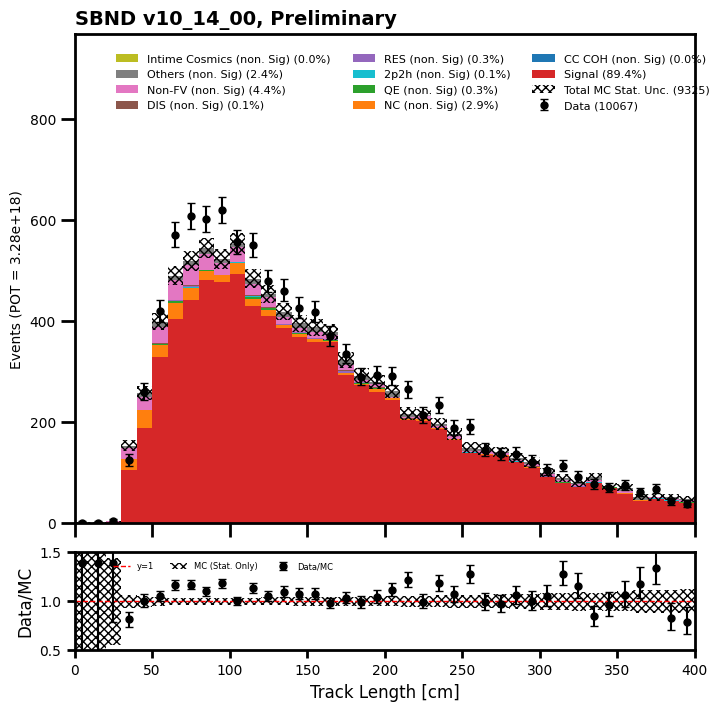

total_mc  [0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 7.1682113e-01 1.4336421e+00 2.1504633e+00 7.8850307e+00 1.2902781e+01
 1.7203707e+01 2.3655064e+01 4.6593296e+01 4.1575562e+01 5.3761967e+01
 4.0142239e+01 3.0106709e+01 2.0787956e+01 1.7203802e+01 5.7345886e+00
 1.0035553e+01 8.6019135e+00 1.2186058e+01 1.9354305e+01 2.0787949e+01
 3.5482477e+02 4.4728339e+02 5.4190106e+02 6.0067883e+02 6.8597815e+02
 7.6482544e+02 8.3363824e+02 8.6015881e+02 8.4940735e+02 7.9636353e+02
 7.3973669e+02 7.2540070e+02 5.9135980e+02 3.3331201e+02 1.2113936e+02
 7.8847656e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00]
total data =  10369
[  0   0   0   0   0   0   0   0   0   0   0   2   3   6  12  14  36  33
  31  23  28  20  23  12  14   9   7  17  16  22 484 609 671 720 779 829
 909 907 837 799 744 667 602 355 120   9   0   0   0   0]
[0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+0

/tmp/ipykernel_1484/3524794362.py:119: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = mc_stat_err / total_mc
/tmp/ipykernel_1484/3524794362.py:120: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = total_mc / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: invalid value encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:178: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = data_eylow / total_mc
/tmp/ipykernel_1484/3524794362.py:179: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc


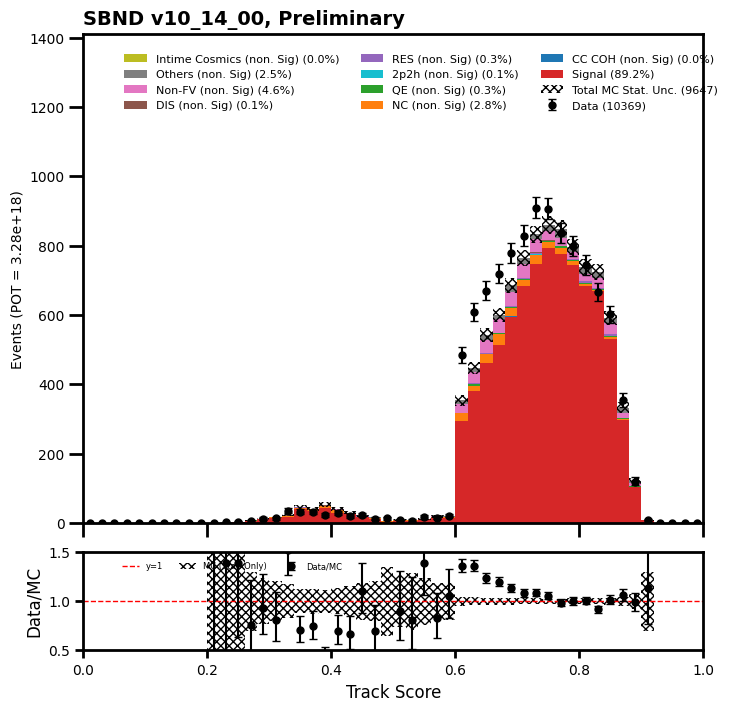

total_mc  [1.34045395e+02 1.12897314e+03 9.85597717e+02 7.14648621e+02
 5.03910156e+02 3.92806610e+02 3.84205780e+02 4.62337646e+02
 5.69140259e+02 8.06400574e+02 9.97068726e+02 7.88479614e+02
 5.13945740e+02 2.83136139e+02 1.84217590e+02 9.31839523e+01
 9.67679214e+01 6.66623764e+01 5.51936874e+01 3.94240303e+01
 1.50528193e+01 1.50528259e+01 1.72032471e+01 1.64864998e+01
 1.43360291e+01 1.29024601e+01 1.36192627e+01 1.00352669e+01
 1.43360233e+01 1.07520695e+01 1.50528564e+01 2.50880432e+01
 1.36192932e+01 1.79200439e+01 1.29024544e+01 1.00351868e+01
 7.88485718e+00 2.43711700e+01 2.15040226e+01 2.86719971e+01
 3.51231689e+01 2.65215149e+01 2.36543274e+01 1.14687805e+01
 1.21856384e+01 4.30081177e+00 2.15039062e+00 2.15039062e+00
 1.43362427e+00 2.15042114e+00 7.16796875e-01 0.00000000e+00
 0.00000000e+00 7.16796875e-01 7.16827393e-01 0.00000000e+00
 1.43362427e+00 7.16796875e-01 0.00000000e+00 7.16796875e-01
 0.00000000e+00 7.16796875e-01 7.16796875e-01 7.16796875e-01
 0.00000000e+0

/tmp/ipykernel_1484/3524794362.py:119: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = mc_stat_err / total_mc
/tmp/ipykernel_1484/3524794362.py:120: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = total_mc / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: divide by zero encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: invalid value encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:178: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = data_eylow / total_mc
/tmp/ipykernel_1484/3524794362.py:179: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc
/exp/sbnd/app/users/amoor/cafpyana/cafpyana/envs/venv_py39_cafpyana/lib/python3.9/site-packages/matplotlib/axes/_axes.py:3749: RuntimeWarning: overflow encountered in add
  low, high = dep + np.vstack(

total data =  10369
[  64  988 1121  771  573  450  446  657  933 1105  979  644  467  245
  173  115   93   67   58   33   13   11   10    9   19   14   14   11
   16   16    9   15    7    8   10   12   14   20   17   22   25   22
   12   17   10   10    5    2    1    4    0    1    1    1    0    1
    2    2    1    1    1    0    0    0    0    0    0    0    0    0
    0    0    0    0    1    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0]
[1.34045395e+02 1.12897314e+03 9.85597717e+02 7.14648621e+02
 5.03910156e+02 3.92806610e+02 3.84205780e+02 4.62337646e+02
 5.69140259e+02 8.06400574e+02 9.97068726e+02 7.88479614e+02
 5.13945740e+02 2.83136139e+02 1.84217590e+02 9.31839523e+01
 9.67679214e+01 6.66623764e+01 5.51936874e+01 3.94240303e+01
 1.50528193e+01 1.50528259e+01 1.72032471e+01 1.64864998e+01
 1.43360291e+01 1.29024601e+01 1.36192627e+01 1.00352669e+01
 1.43360233e+01 1.07520695e+01 1.50528564e+0

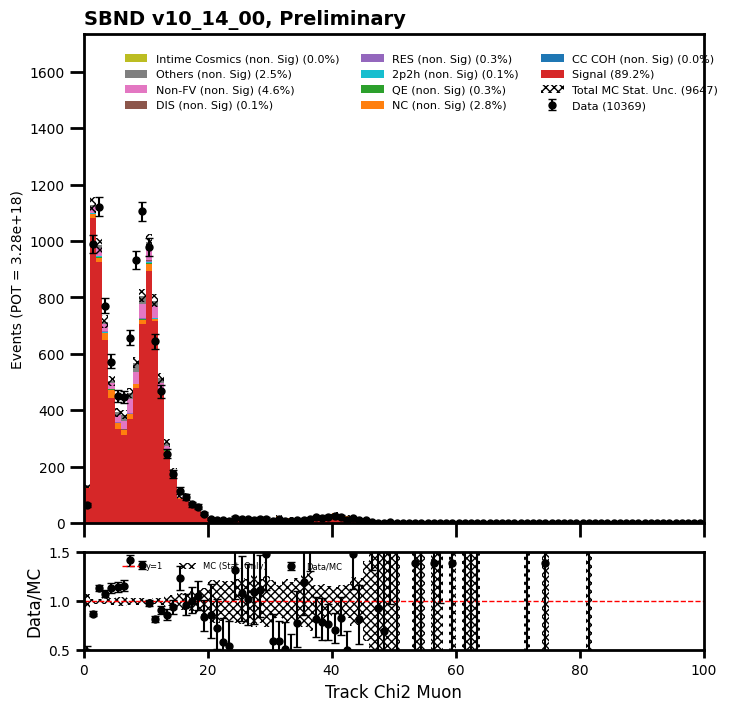

total_mc  [26.52238    82.4343     58.062668   17.920652    6.45144     2.8673096
  2.1504822   4.3009577   4.3009644   1.4336548   2.1504822   2.8672905
  4.3009644   0.7168274   3.584137    2.8673096   2.1504755   0.7168274
  2.8673096   0.7168274   0.7168274   0.7168217   1.4336548   0.
  1.4336548   0.7168274   1.4336548   1.4336548   1.4336548   2.1504822
  0.7168274   0.          0.7168274   2.8673096   0.7168274   0.7168274
  2.150476    0.7168274   1.4336548   3.584137    0.7168274   1.4336548
  0.7168274   2.1504765   0.7168274   0.          0.          1.4336548
  3.584137    0.          0.7168274   0.7168274   1.4336491   1.4336548
  1.4336548   1.4336548   1.4336491   1.4336548   1.4336548   2.1504822
  0.          0.7168274   1.4336491   1.4336548   1.4336433   0.71681213
  0.7168274   1.4336548   2.8673096   1.4336491   0.          1.4336548
  0.          0.7168217   0.          0.          0.7168274   2.8673096
  1.4336548   1.4336548   3.584125    0.          1.4336548 

/tmp/ipykernel_1484/3524794362.py:119: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = mc_stat_err / total_mc
/tmp/ipykernel_1484/3524794362.py:120: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = total_mc / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: divide by zero encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: invalid value encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:178: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = data_eylow / total_mc
/tmp/ipykernel_1484/3524794362.py:179: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc
/exp/sbnd/app/users/amoor/cafpyana/cafpyana/envs/venv_py39_cafpyana/lib/python3.9/site-packages/matplotlib/axes/_axes.py:3749: RuntimeWarning: overflow encountered in add
  low, high = dep + np.vstack(

total data =  356
[21  7 58 38 17  8  9  4  4  3  5  2  1  0  4  2  3  0  0  1  4  2  0  1
  2  1  0  2  0  0  0  0  1  0  0  0  0  0  1  1  2  3  0  0  1  0  1  0
  0  1  2  0  0  0  1  1  0  1  1  0  4  0  2  0  1  1  0  1  1  2  0  0
  0  1  1  0  1  2  0  1  1  0  2  1  1  1  0  0  3  1  3 12  5 15  8 10
 19 10 20 10]
[26.52238    82.4343     58.062668   17.920652    6.45144     2.8673096
  2.1504822   4.3009577   4.3009644   1.4336548   2.1504822   2.8672905
  4.3009644   0.7168274   3.584137    2.8673096   2.1504755   0.7168274
  2.8673096   0.7168274   0.7168274   0.7168217   1.4336548   0.
  1.4336548   0.7168274   1.4336548   1.4336548   1.4336548   2.1504822
  0.7168274   0.          0.7168274   2.8673096   0.7168274   0.7168274
  2.150476    0.7168274   1.4336548   3.584137    0.7168274   1.4336548
  0.7168274   2.1504765   0.7168274   0.          0.          1.4336548
  3.584137    0.          0.7168274   0.7168274   1.4336491   1.4336548
  1.4336548   1.4336548   1.4336491

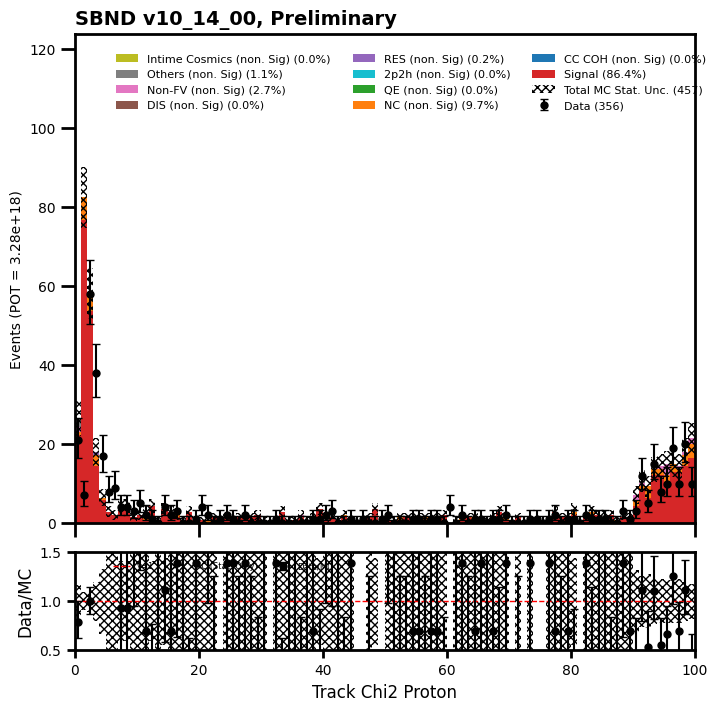

total_mc  [   0.        2042.902     1955.4307    1303.142      913.91956
  677.37537    485.99       382.05408    301.05603    216.47339
  168.44781    138.34224    126.873436    93.18394     96.0511
   73.8303      57.34381     61.644745    43.007935    37.27359
   36.556755    30.822357    27.238428    23.654327    25.804737
   18.63678     26.521545    18.63675     16.486408    10.035156
   12.902344    17.919983     7.1679993    8.601593     9.318359
    4.300812     9.318359     5.0176086    7.1679688    6.4512024]
total data =  9977
[   0 1548 1612 1233  944  718  613  462  350  327  285  220  197  197
  117  130  119   88   73   82   62   70   67   38   46   43   40   27
   43   29   32   26   26   16   14   17   18   17   13   18]
[   0.        2042.902     1955.4307    1303.142      913.91956
  677.37537    485.99       382.05408    301.05603    216.47339
  168.44781    138.34224    126.873436    93.18394     96.0511
   73.8303      57.34381     61.644745    43.007935    37.2

/tmp/ipykernel_1484/3524794362.py:119: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = mc_stat_err / total_mc
/tmp/ipykernel_1484/3524794362.py:120: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = total_mc / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: invalid value encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:178: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = data_eylow / total_mc
/tmp/ipykernel_1484/3524794362.py:179: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc


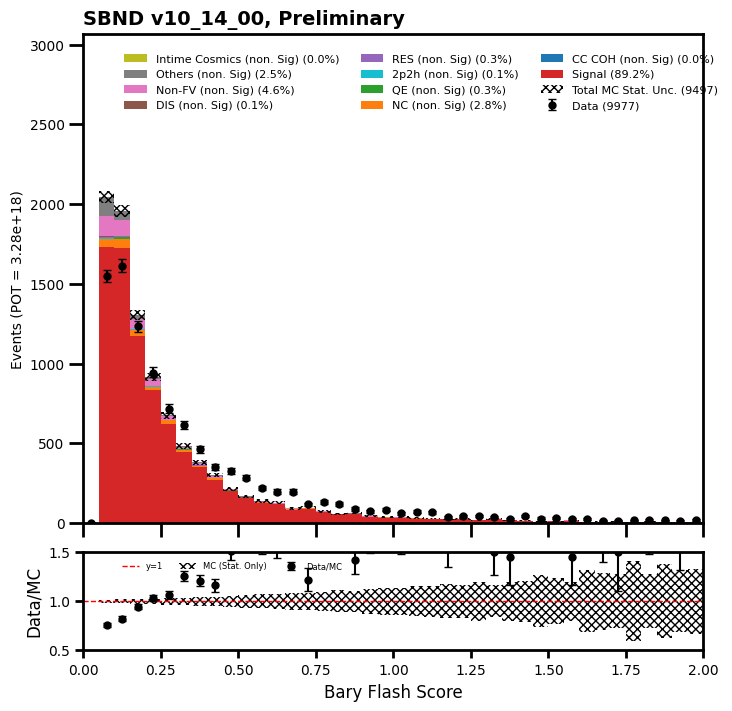

total_mc  [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 7.16821134e-01
 0.00000000e+00 1.43364227e+00 2.00709877e+01 1.21859589e+01
 1.43364258e+01 2.29382763e+01 1.64868660e+01 1.79205017e+01
 3.15400753e+01 3.29737167e+01 4.94608994e+01 5.01777649e+01
 4.22927246e+01 5.30451279e+01 6.23638611e+01 6.45143433e+01
 6.80984573e+01 7.31162796e+01 8.81676712e+01 7.81313019e+01
 7.95647278e+01 8.24320297e+01 9.39008942e+01 9.89183884e+01
 9.67681046e+01 8.95998764e+01 1.08953674e+02 9.89184189e+01
 1.08953758e+02 1.08236916e+02 1.24723373e+02 1.08953751e+02
 1.24006660e+02 1.24006294e+02 1.31891296e+02 1.31174423e+02
 1.21856148e+02 1.40492889e+02 1.20422577e+02 1.34041550e+02
 1.26156761e+02 1.27590607e+02 1.24006393e+02 1.36908783e+02
 1.11820610e+02 1.36908737e+02 1.27590508e+02 1.41926453e+02
 1.56262558e+02 1.42643372e+02 1.29023865e+02 1.50527969e+02
 1.34041473e+0

/tmp/ipykernel_1484/3524794362.py:119: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = mc_stat_err / total_mc
/tmp/ipykernel_1484/3524794362.py:120: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = total_mc / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: divide by zero encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:174: RuntimeWarning: invalid value encountered in divide
  data_ratio = norm_counts / total_mc
/tmp/ipykernel_1484/3524794362.py:178: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = data_eylow / total_mc
/tmp/ipykernel_1484/3524794362.py:179: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc
/exp/sbnd/app/users/amoor/cafpyana/cafpyana/envs/venv_py39_cafpyana/lib/python3.9/site-packages/matplotlib/axes/_axes.py:3749: RuntimeWarning: overflow encountered in add
  low, high = dep + np.vstack(

total data =  10369
[   0    0    0    0    0    0    0    0    0    0    0    0    0    7
   28   12   14   21   34   36   37   47   58   43   57   66   78   77
   95   85   92   90   95   96  102  136  118  117  119  114  119  121
  137  116  113  122  123  141  137  178  132  137  108  137  134  141
  134  139  142  144  164  157  159  135  120  144  157  153  142  153
  150  155  137  147  168  147  139  154  129   98  146  119  131  140
  124 1593  675    1    1    0    0    0    1    0    0    1    0    0
    0    0]
[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 7.16821134e-01
 0.00000000e+00 1.43364227e+00 2.00709877e+01 1.21859589e+01
 1.43364258e+01 2.29382763e+01 1.64868660e+01 1.79205017e+01
 3.15400753e+01 3.29737167e+01 4.94608994e+01 5.01777649e+01
 4.22927246e+01 5.30451279e+01 6.23638611e+01 6.45143433e+01
 6.80984573e+01 7.31162796e+01 8.81676712e+0

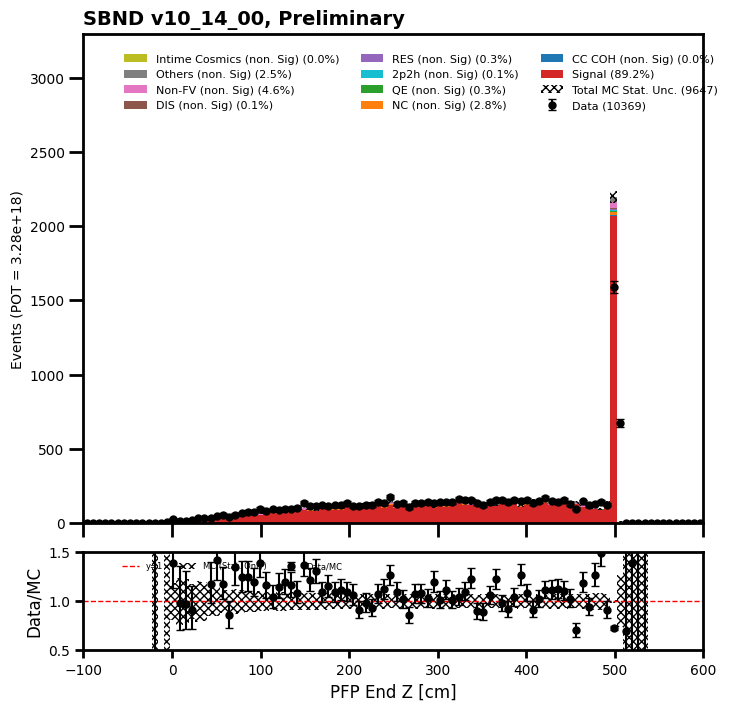

In [67]:
#muon candidates low z

draw_reco_valid_plots(mc_bnb_cosmic_dfs["evt"], data_offbeam_light_dfs["evt"], data_bnb_light_dfs["evt"], "a_vtx_fv_and_not_clear_cosmic_nu_score")

In [68]:
purity = 8603.7333984375/9647.429379343987
efficiency = 8603.7333984375/15446.276679992676
print("purity = ", round(purity*100,2), "% and efficiency = ", round(efficiency*100,2), "%")

purity =  89.11 % and efficiency =  55.71 %


In [1]:
#purity = number of true signal events selected / 
#          total number of events selected
#efficiency = number of true signal events selected / 
#             total number of true signal events